# FIFA World Cup 2026 Analytics

# Exploratory Data Analysis (EDA)

Author: Ayush Singh

This notebook explores the cleaned FIFA World Cup 2026 datasets.

Objectives:

- Understand player statistics
- Analyze team performance
- Analyze match statistics
- Identify trends
- Prepare data for Feature Engineering

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (12,6)

print("="*60)
print("Libraries Loaded Successfully")
print("="*60)

Libraries Loaded Successfully


In [2]:
# ==========================================================
# LOAD CLEAN DATA
# ==========================================================

players = pd.read_csv("../data/interim/players_clean.csv")

teams = pd.read_csv("../data/interim/teams_clean.csv")

matches = pd.read_csv("../data/interim/matches_clean.csv")

print("="*60)
print("Datasets Loaded Successfully")
print("="*60)

print()

print("Players :", players.shape)

print("Teams :", teams.shape)

print("Matches :", matches.shape)

Datasets Loaded Successfully

Players : (1248, 70)
Teams : (48, 132)
Matches : (104, 42)


In [3]:
# ==========================================================
# FIRST LOOK
# ==========================================================

print("="*60)
print("PLAYERS DATA")
print("="*60)

display(players.head())

print("="*60)
print("TEAMS DATA")
print("="*60)

display(teams.head())

print("="*60)
print("MATCHES DATA")
print("="*60)

display(matches.head())

PLAYERS DATA


,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,Unknown Club,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,0,0.0,4,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,Unknown Club,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,10.0,5.3,0.0,0,2,10.0,2,0.0,0.0,0.0,0.0,0.00,1.06,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.36,0.0,0.36,0.36,0.36,3.0,2.0,66.7,1.08,0.72,0.33,0.5,63.0,69.7,73.0,0,1,33.0,0,1.0,4.0,5.0,-1.0,-0.36,2.12,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,2.0,0.0,0.0,1.84,0.00,0.00,0.0,33.0,27.2,63.0,0,2,18.0,1,1.0,1.0,2.0,-1.0,-0.92,0.11,0.0,0.0,2.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,90.0,100.0,90.0,4,0,0.0,0,1.0,5.0,9.0,-4.0,-1.00,0.00,0.0,0.0,5.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


TEAMS DATA


,team,team_country,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,players_used_against,avg_age_against,possession_against,games_against,games_starts_against,minutes_against,minutes_90s_against,goals_against,assists_against,goals_assists_against,goals_pens_against,pens_made_against,pens_att_against,cards_yellow_against,cards_red_against,goals_per90_against,assists_per90_against,goals_assists_per90_against,goals_pens_per90_against,goals_assists_pens_per90_against,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,shots_against,shots_on_target_against,shots_on_target_pct_against,shots_per90_against,shots_on_target_per90_against,goals_per_shot_against,goals_per_shot_on_target_against,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,minutes_per_game_against,minutes_pct_against,minutes_per_start_against,games_complete_against,games_subs_against,minutes_per_sub_against,unused_subs_against,points_per_game_against,on_goals_for_against,on_goals_against_against,plus_minus_against,plus_minus_per90_against,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,cards_yellow_red_against,fouls_against,fouled_against,offsides_against,crosses_against,interceptions_against,tackles_won_against,own_goals_against,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct,gk_games_against,gk_games_starts_against,gk_minutes_against,gk_goals_against_against,gk_goals_against_per90_against,gk_shots_on_target_against_against,gk_saves_against,gk_save_pct_against,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
0,Algeria,Algeria,22,27.3,61.0,4,44,360,4.0,5,3,8,5,0,0,3,0,1.25,0.75,2.00,1.25,2.00,22,29.1,39.0,4,44,360,4.0,9,7,16,9,0,0,2,0,2.25,1.75,4.00,2.25,4.00,44,15,34.1,11.00,3.75,0.11,0.33,39,18,46.2,9.75,4.50,0.23,0.50,90,100,81,25,19,21,37,1.00,5,9,-4,-1.00,90,100,81,24,20,20,39,1.75,9,5,4,1.00,0,29,40,4,40,30,44,0,0,41,27,7,37,41,50,0,4,4,360,9,2.25,17,8,47.1,1,1,2,0,0.0,0,0,0,0,0.0,4,4,360,5,1.25,15,10,66.7,2,1,1,2,50.0,0,0,0,0,0.0
1,Argentina,Argentina,24,29.6,57.6,8,88,810,9.0,18,12,30,17,1,3,15,1,2.00,1.33,3.33,1.89,3.22,24,28.3,42.4,8,88,810,9.0,8,8,16,8,0,0,14,1,0.89,0.89,1.78,0.89,1.78,114,44,38.6,12.67,4.89,0.15,0.39,75,28,37.3,8.33,3.11,0.11,0.29,101,100,87,45,42,30,78,2.63,19,8,11,1.22,101,100,87,45,42,25,74,0.38,8,19,-11,-1.22,1,113,100,22,104,82,93,0,1,107,109,12,121,82,67,1,8,8,810,8,0.89,28,20,71.4,7,0,1,2,25.0,0,0,0,0,0.0,8,8,810,19,2.11,43,24,55.8,1,0,7,1,12.5,3,1,1,1,50.0
2,Australia,Australia,23,25.3,41.0,4,44,390,4.3,2,1,3,2,0,0,5,0,0.46,0.23,0.69,0.46,0.69,23,27.8,59.0,4,44,390,4.3,2,1,3,2,0,0,7,0,0.46,0.23,0.69,0.46,0.69,42,12,28.6,9.69,2.77,0.05,0.17,61,15,24.6,14.08,3.46,0.03,0.13,98,100,85,25,19,28,37,1.25,3,3,0,0.00,98,100,85,24,20,19,35,1.25,3,3,0,0.00,0,46,38,1,70,29,34,1,0,39,45,7,71,41,38,1,4,4,390,3,0.69,17,14,82.4,1,1,2,2,50.0,0,0,0,0,0.0,4,4,390,3,0.69,13,10,76.9,2,1,1,2,50.0,0,0,0,0,0.0
3,Austria,Austria,20,28.8,45.0,4,44,360,4.0,5,4,9,4,1,1,5,0,1.25,1.00,2.25,1.00,2.00,20,27.8,55.0,4,44,360,4.0,9,7,16,9,0,1,2,0,2.25,1.75,4.00,2.25,4.00,32,8,25.0,8.00,2.00,0.13,0.50,58,24,41.4,14.50,6.00,0.16,0.38,90,100,77,24,20,28,40,1.00,6,9,-3,-0.75,90,100,77,25,19,14,40,1.75,9,6,3,0.75,0,47,28,11,59,41,29,0,0,31,42,6,46,29,37,1,4,4,360,9,2.25,22,13,59.1,1,1,2,0,0.0

MATCHES DATA


,round,gameweek,dayofweek,date,start_time,home_team,away_team,score,home_score,away_score,attendance,venue,referee,home_formation,away_formation,home_manager,away_manager,home_captain,away_captain,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,away_saves,home_cards_yellow,away_cards_yellow,home_cards_red,away_cards_red,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides,notes
0,Group stage,1.0,Thu,2026-06-11,13:00,Mexico,South Africa,2–0,2.0,0.0,80824,"Estadio Banorte, Coyoacán",Wilton Sampaio,4-1-4-1,5-3-2,Javier Aguirre,Hugo Broos,César Montes,Ronwen Williams,61,40,4,2,16,3,2,2,1,2,1,2,12,11,3,1,12,8,8,7,1.0,1.0,Unknown
1,Group stage,1.0,Thu,2026-06-11,20:00,Korea Republic,Czechia,2–1,2.0,1.0,44985,"Estadio Akron, Zapopan",Amin Omar,3-4-3,3-4-3,Hong Myung-bo,Miroslav Koubek,Son Heung-min,Ladislav Krejčí,62,38,6,4,15,7,3,4,1,0,0,0,9,16,4,5,12,15,11,7,2.0,2.0,Unknown
2,Group stage,1.0,Fri,2026-06-12,15:00,Canada,Bosnia–Herz,1–1,1.0,1.0,43002,"BMO Field, Toronto",Facundo Tello,4-2-2-2,4-2-2-2,Jesse Marsch,Sergej Barbarez,Stephen Eustáquio,Sead Kolašinac,61,39,4,3,13,8,2,1,2,3,0,0,10,20,9,4,24,10,4,10,1.0,0.0,Unknown
3,Group stage,1.0,Fri,2026-06-12,18:00,United States,Paraguay,4–1,4.0,1.0,70492,"SoFi Stadium, Inglewood",Danny Makkelie,4-2-3-1,4-2-2-2,Mauricio Pochettino,Gustavo Alfaro,Tim Ream,Gustavo Gómez,65,35,6,1,16,9,0,3,1,5,0,0,13,17,3,1,17,5,11,9,2.0,1.0,Unknown
4,Group stage,1.0,Sat,2026-06-13,12:00,Qatar,Switzerland,1–1,1.0,1.0,67966,"Levi's Stadium, Santa Clara",Said Martínez,4-1-4-1,4-2-3-1,Julen Lopetegui,Murat Yakin,Boualem Khoukhi,Granit Xhaka,32,68,4,7,7,26,5,3,2,1,0,0,12,11,3,10,8,35,10,7,0.0,1.0,Unknown


In [4]:
# ==========================================================
# DATASET DIMENSIONS
# ==========================================================

summary = pd.DataFrame({

    "Dataset":[

        "Players",

        "Teams",

        "Matches"

    ],

    "Rows":[

        players.shape[0],

        teams.shape[0],

        matches.shape[0]

    ],

    "Columns":[

        players.shape[1],

        teams.shape[1],

        matches.shape[1]

    ]

})

summary

,Dataset,Rows,Columns
0,Players,1248,70
1,Teams,48,132
2,Matches,104,42


In [5]:
# ==========================================================
# MEMORY USAGE
# ==========================================================

memory = pd.DataFrame({

    "Dataset":[

        "Players",

        "Teams",

        "Matches"

    ],

    "Memory (MB)":[

        round(players.memory_usage(deep=True).sum()/1024**2,2),

        round(teams.memory_usage(deep=True).sum()/1024**2,2),

        round(matches.memory_usage(deep=True).sum()/1024**2,2)

    ]

})

memory

,Dataset,Memory (MB)
0,Players,1.02
1,Teams,0.05
2,Matches,0.13


In [6]:
# ==========================================================
# DATA TYPES
# ==========================================================

print("="*60)
print("PLAYERS")
print("="*60)

display(players.dtypes.value_counts())

print("="*60)
print("TEAMS")
print("="*60)

display(teams.dtypes.value_counts())

print("="*60)
print("MATCHES")
print("="*60)

display(matches.dtypes.value_counts())

PLAYERS


float64    58
int64       7
str         5
Name: count, dtype: int64

TEAMS


int64      92
float64    38
str         2
Name: count, dtype: int64

MATCHES


int64      21
str        16
float64     5
Name: count, dtype: int64

In [7]:
# ==========================================================
# MISSING VALUES
# ==========================================================

def missing_table(df):

    missing = df.isnull().sum()

    missing = missing[missing>0]

    missing = pd.DataFrame({

        "Missing Values":missing,

        "Percentage":round((missing/len(df))*100,2)

    })

    return missing.sort_values(
        "Missing Values",
        ascending=False
    )


print("="*60)
print("PLAYERS")
print("="*60)

display(missing_table(players))

print("="*60)
print("TEAMS")
print("="*60)

display(missing_table(teams))

print("="*60)
print("MATCHES")
print("="*60)

display(missing_table(matches))

PLAYERS


,Missing Values,Percentage


TEAMS


,Missing Values,Percentage


MATCHES


,Missing Values,Percentage


In [8]:
# ==========================================================
# DUPLICATES
# ==========================================================

duplicates = pd.DataFrame({

    "Dataset":[

        "Players",

        "Teams",

        "Matches"

    ],

    "Duplicate Rows":[

        players.duplicated().sum(),

        teams.duplicated().sum(),

        matches.duplicated().sum()

    ]

})

duplicates

,Dataset,Duplicate Rows
0,Players,0
1,Teams,0
2,Matches,0


In [9]:
# ==========================================================
# NUMERICAL SUMMARY
# ==========================================================

print("="*60)
print("PLAYERS")
print("="*60)

display(players.describe())

print("="*60)
print("TEAMS")
print("="*60)

display(teams.describe())

print("="*60)
print("MATCHES")
print("="*60)

display(matches.describe())

PLAYERS


,age,birth_year,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000
mean,27.456731,1998.040865,2.634615,1.833333,169.399038,1.881410,0.236378,0.179487,0.415865,0.223558,0.012821,0.017628,0.216346,0.012019,0.116450,0.074864,0.191370,0.111755,0.186667,2.065705,0.709936,16.405849,1.095913,0.342965,0.047099,0.093093,48.164263,42.213702,49.809295,1.024038,0.801282,10.410256,1.629808,0.983598,2.710737,2.696314,0.014423,-0.459792,-0.115016,0.001603,1.932692,1.849359,0.294872,2.668269,1.393429,1.622596,0.010417,0.172276,0.166667,15.432692,0.246795,0.089736,0.708333,0.460737,2.890224,0.064103,0.038462,0.064103,0.045673,0.983654,0.017628,0.012821,0.004006,0.000801,0.227003
std,4.271243,4.257633,1.924265,1.896549,163.254622,1.812495,0.768917,0.544562,1.083212,0.724542,0.119458,0.148805,0.476881,0.109015,0.904507,0.289345,0.955541,0.900793,0.951993,3.588341,1.679872,28.219154,2.368346,1.127757,0.144216,0.255196,34.163921,36.457605,40.117896,1.544652,1.120888,14.732415,1.791670,0.935000,3.603724,2.751380,3.266282,6.428216,7.191919,0.040016,2.430814,2.714669,0.819513,5.315444,2.102396,2.388364,0.109180,0.852357,0.845448,78.683282,1.216034,0.483188,3.478406,2.374023,13.620987,0.474592,0.262848,0.331302,0.356402,7.165357,0.168992,0.132204,0.074816,0.028307,4.345225
min,17.000000,1982.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-11.000000,-90.000000,-90.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24.000000,1995.000000,1.000000,0.000000,20.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,5.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-0.920000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00

TEAMS


,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,players_used_against,avg_age_against,possession_against,games_against,games_starts_against,minutes_against,minutes_90s_against,goals_against,assists_against,goals_assists_against,goals_pens_against,pens_made_against,pens_att_against,cards_yellow_against,cards_red_against,goals_per90_against,assists_per90_against,goals_assists_per90_against,goals_pens_per90_against,goals_assists_pens_per90_against,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,shots_against,shots_on_target_against,shots_on_target_pct_against,shots_per90_against,shots_on_target_per90_against,goals_per_shot_against,goals_per_shot_on_target_against,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,minutes_per_game_against,minutes_pct_against,minutes_per_start_against,games_complete_against,games_subs_against,minutes_per_sub_against,unused_subs_against,points_per_game_against,on_goals_for_against,on_goals_against_against,plus_minus_against,plus_minus_per90_against,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,cards_yellow_red_against,fouls_against,fouled_against,offsides_against,crosses_against,interceptions_against,tackles_won_against,own_goals_against,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct,gk_games_against,gk_games_starts_against,gk_minutes_against,gk_goals_against_against,gk_goals_against_per90_against,gk_shots_on_target_against_against,gk_saves_against,gk_save_pct_against,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.0,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.0,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,21.645833,27.939583,48.629167,4.333333,47.666667,401.25000,4.450000,6.145833,4.666667,10.812500,5.81250,0.333333,0.458333,5.625000,0.312500,1.227083,0.929375,2.155833,1.169583,2.098333,21.645833,27.889583,51.389583,4.333333,47.666667,401.25000,4.450000,6.145833,4.666667,10.81250,5.812500,0.333333,0.458333,5.770833,0.312500,1.531875,1.149583,2.682292,1.450833,2.600625,53.708333,18.458333,32.710417,11.53375,3.815625,0.102083,0.310000,53

MATCHES


,gameweek,home_score,away_score,attendance,home_possession,away_possession,home_sot,away_sot,home_total_shots,away_total_shots,home_saves,away_saves,home_cards_yellow,away_cards_yellow,home_cards_red,away_cards_red,home_fouls,away_fouls,home_corners,away_corners,home_crosses,away_crosses,home_interceptions,away_interceptions,home_offsides,away_offsides
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,1.384615,1.692308,1.211538,65490.057692,52.423077,47.701923,4.846154,3.673077,14.019231,10.769231,2.403846,3.125000,1.153846,1.509615,0.038462,0.105769,11.625000,11.567308,5.182692,3.961538,17.817308,14.201923,8.086538,8.634615,1.826923,1.711538
std,1.151678,1.526955,1.251586,10052.949890,13.101317,13.093302,3.108926,2.502202,6.422020,5.846301,1.913261,2.510899,1.021794,1.343775,0.193239,0.366518,4.027063,4.403803,3.409764,2.661933,10.338696,7.325153,3.859450,3.128503,1.541921,1.605047
min,0.000000,0.000000,0.000000,42942.000000,24.000000,21.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,4.000000,1.000000,1.000000,3.000000,0.000000,0.000000
25%,0.000000,0.750000,0.000000,63998.000000,43.000000,38.000000,2.000000,2.000000,8.750000,7.000000,1.000000,1.750000,0.000000,1.000000,0.000000,0.000000,9.000000,8.000000,3.000000,2.000000,11.750000,9.000000,5.000000,6.000000,1.000000,0.000000
50%,1.000000,1.000000,1.000000,68276.000000,52.500000,47.500000,4.000000,3.000000,13.000000,10.000000,2.000000,3.000000,1.000000,1.000000,0.000000,0.000000,11.000000,12.000000,4.000000,4.000000,15.000000,13.000000,7.500000,8.500000,2.000000,1.000000
75%,2.000000,3.000000,2.000000,70046.500000,62.000000,57.000000,7.000000,5.000000,19.000000,14.000000,3.000000,4.000000,2.000000,2.000000,0.000000,0.000000,13.250000,14.000000,7.000000,5.000000,22.000000,18.000000,10.000000,11.000000,3.000000,3.000000
max,3.000000,7.000000,6.000000,80824.000000,79.000000,76.000000,15.000000,11.000000,32.000000,35.000000,9.000000,15.000000,4.000000,7.000000,1.000000,2.000000,24.000000,25.000000,19.000000,14.000000,56.000000,47.000000,21.000000,16.000000,8.000000,6.000000


In [10]:
# ==========================================================
# CATEGORICAL SUMMARY
# ==========================================================

print("="*60)
print("PLAYERS")
print("="*60)

display(players.describe(include="object"))

print("="*60)
print("TEAMS")
print("="*60)

display(teams.describe(include="object"))

print("="*60)
print("MATCHES")
print("="*60)

display(matches.describe(include="object"))

PLAYERS


,player,team,team_country,position,club
count,1248,1248,1248,1248,1248
unique,1247,48,48,9,316
top,Emiliano Martínez,Algeria,Algeria,MF,Unknown Club
freq,2,26,26,378,341


TEAMS


,team,team_country
count,48,48
unique,48,48
top,Algeria,Algeria
freq,1,1


MATCHES


,round,dayofweek,date,start_time,home_team,away_team,score,venue,referee,home_formation,away_formation,home_manager,away_manager,home_captain,away_captain,notes
count,104,104,104,104,104,104,104,104,104,104,104,104,104,104,104,104
unique,7,7,34,14,48,48,31,17,43,10,10,48,49,52,61,6
top,Group stage,Sat,2026-06-24,12:00,France,Morocco,2–1,"AT&T Stadium, Arlington",Slavko Vinčič,4-2-3-1,4-2-3-1,Didier Deschamps,Mohamed Ouahbi,Kylian Mbappé,Achraf Hakimi,Unknown
freq,72,19,6,23,6,5,9,9,4,34,34,6,5,6,5,95


In [11]:
# ==========================================================
# DATASET HEALTH REPORT
# ==========================================================

health = pd.DataFrame({

    "Dataset":[

        "Players",

        "Teams",

        "Matches"

    ],

    "Rows":[

        len(players),

        len(teams),

        len(matches)

    ],

    "Columns":[

        players.shape[1],

        teams.shape[1],

        matches.shape[1]

    ],

    "Duplicates":[

        players.duplicated().sum(),

        teams.duplicated().sum(),

        matches.duplicated().sum()

    ],

    "Missing Cells":[

        players.isnull().sum().sum(),

        teams.isnull().sum().sum(),

        matches.isnull().sum().sum()

    ]

})

health

,Dataset,Rows,Columns,Duplicates,Missing Cells
0,Players,1248,70,0,0
1,Teams,48,132,0,0
2,Matches,104,42,0,0


In [12]:
# ==========================================================
# SAVE REPORTS
# ==========================================================

summary.to_csv(
    "../reports/eda_dataset_summary.csv",
    index=False
)

memory.to_csv(
    "../reports/memory_usage.csv",
    index=False
)

duplicates.to_csv(
    "../reports/duplicate_report.csv",
    index=False
)

health.to_csv(
    "../reports/dataset_health.csv",
    index=False
)

print("="*60)
print("EDA REPORTS SAVED SUCCESSFULLY")
print("="*60)

EDA REPORTS SAVED SUCCESSFULLY


# Player Exploratory Data Analysis

This section analyzes:

- Player Positions
- Age Distribution
- Clubs
- National Teams
- Goals
- Assists
- Minutes
- Goal Contributions
- Discipline
- Shooting
- Defensive Statistics
- Goalkeeper Statistics

In [13]:
# ==========================================================
# TOTAL PLAYERS
# ==========================================================

print("="*60)
print("PLAYER OVERVIEW")
print("="*60)

print("Total Players :", len(players))

print("Unique Teams :", players["team"].nunique())

print("Unique Clubs :", players["club"].nunique())

print("Unique Positions :", players["position"].nunique())

PLAYER OVERVIEW
Total Players : 1248
Unique Teams : 48
Unique Clubs : 316
Unique Positions : 9


position
MF       378
DF       364
FW       169
GK       145
FW,MF     90
DF,MF     49
MF,FW     36
MF,DF     12
DF,FW      5
Name: count, dtype: int64

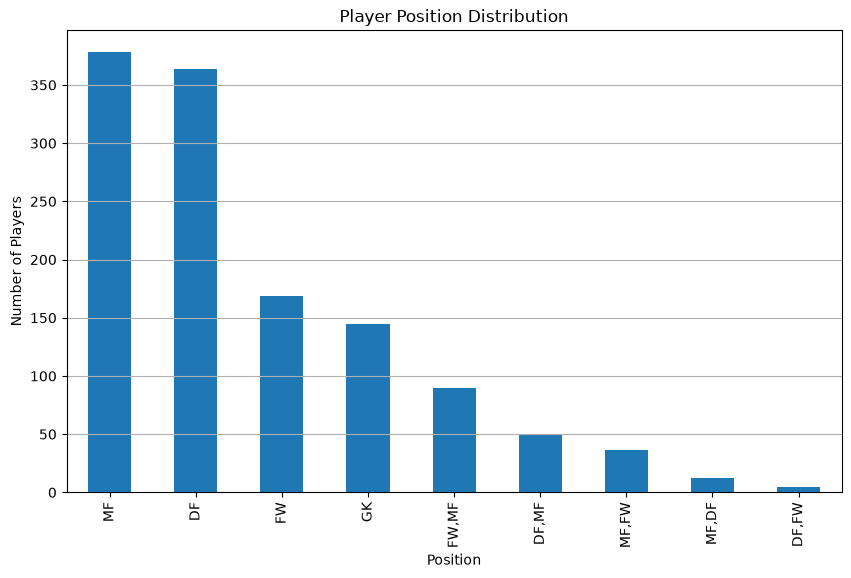

In [14]:
position_counts = (
    players["position"]
    .value_counts()
    .sort_values(ascending=False)
)

display(position_counts)

plt.figure(figsize=(10,6))

position_counts.plot(kind="bar")

plt.title("Player Position Distribution")

plt.xlabel("Position")

plt.ylabel("Number of Players")

plt.grid(axis="y")

plt.show()

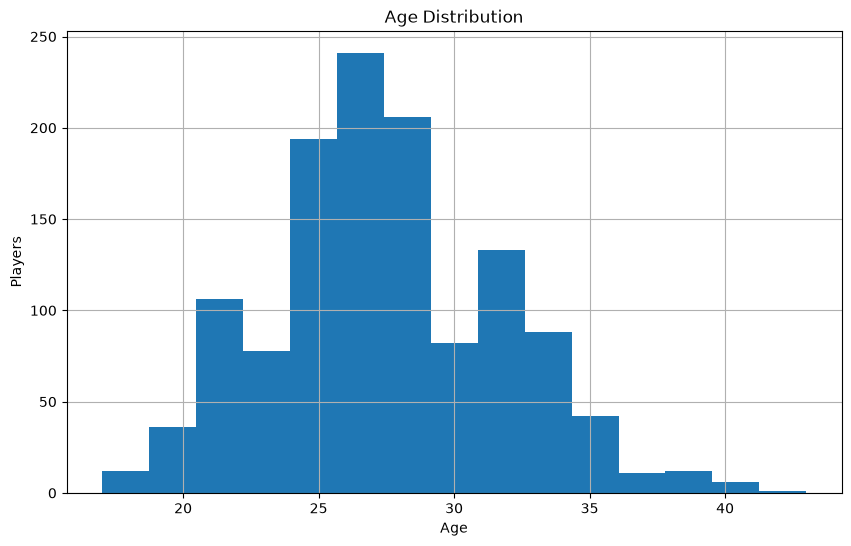

In [15]:
plt.figure(figsize=(10,6))

plt.hist(
    players["age"],
    bins=15
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Players")

plt.grid()

plt.show()

In [16]:
players.sort_values(
    "age"
).head(20)[
[
    "player",
    "team",
    "position",
    "age"
]
]

,player,team,position,age
710,Gilberto Mora,Mexico,MF,17
1140,Rayan Elloumi,Tunisia,FW,18
734,Ayyoub Bouaddi,Morocco,MF,18
421,Hamza Abdelkarim,Egypt,FW,18
996,Ibrahim Mbaye,Senegal,MF,18
992,Bara Sapoko Ndiaye,Senegal,MF,18
148,Mladen Jurkas,Bosnia–Herz,GK,18
146,Kerim Alajbegović,Bosnia–Herz,MF,18
344,Hugo Sochůrek,Czechia,MF,18
1230,Bekhruz Karimov,Uzbekistan,DF,18


In [17]:
players.sort_values(
    "age",
    ascending=False
).head(20)[
[
    "player",
    "team",
    "position",
    "age"
]
]

,player,team,position,age
968,Craig Gordon,Scotland,GK,43
886,Cristiano Ronaldo,Portugal,FW,41
712,Guillermo Ochoa,Mexico,GK,40
298,Luka Modrić,Croatia,MF,40
204,Vozinha,Cabo Verde,GK,40
138,Edin Džeko,Bosnia–Herz,FW,40
511,Manuel Neuer,Germany,GK,40
1203,Fernando Muslera,Uruguay,GK,39
417,El Mahdy Soliman,Egypt,GK,39
648,Yūto Nagatomo,Japan,"DF,MF",39


club
Unknown Club       341
Manchester City     18
Bayern Munich       17
Arsenal             14
PSG                 14
Barcelona           13
Crystal Palace      12
Galatasaray         12
Al-Hilal            12
Dortmund            11
Liverpool           10
Atlético Madrid     10
Real Madrid         10
PSV                 10
Aston Villa          9
Manchester Utd       9
Milan                9
Lille                8
Tottenham            8
Chelsea              8
Name: count, dtype: int64

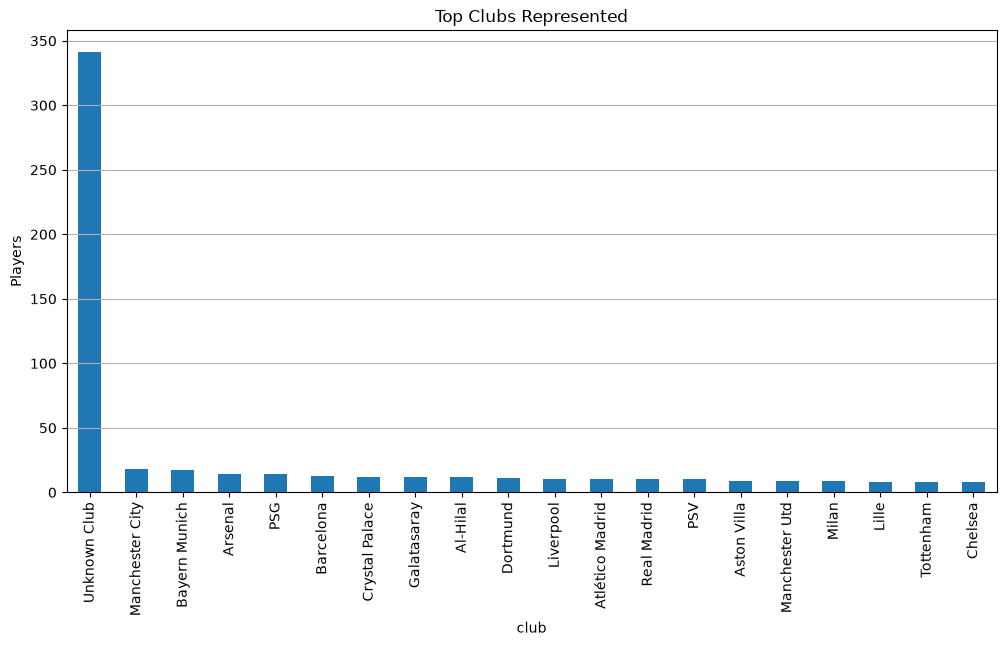

In [18]:
clubs = (
    players["club"]
    .value_counts()
    .head(20)
)

display(clubs)

plt.figure(figsize=(12,6))

clubs.plot(kind="bar")

plt.title("Top Clubs Represented")

plt.ylabel("Players")

plt.grid(axis="y")

plt.show()

team
Algeria           26
Argentina         26
Australia         26
Austria           26
Belgium           26
Bosnia–Herz       26
Brazil            26
Cabo Verde        26
Canada            26
Colombia          26
Congo DR          26
Croatia           26
Curaçao           26
Czechia           26
Côte d'Ivoire     26
Ecuador           26
Egypt             26
England           26
France            26
Germany           26
Ghana             26
Haiti             26
IR Iran           26
Iraq              26
Japan             26
Jordan            26
Korea Republic    26
Mexico            26
Morocco           26
Netherlands       26
New Zealand       26
Norway            26
Panama            26
Paraguay          26
Portugal          26
Qatar             26
Saudi Arabia      26
Scotland          26
Senegal           26
South Africa      26
Spain             26
Sweden            26
Switzerland       26
Tunisia           26
Türkiye           26
United States     26
Uruguay           26
Uzbekist

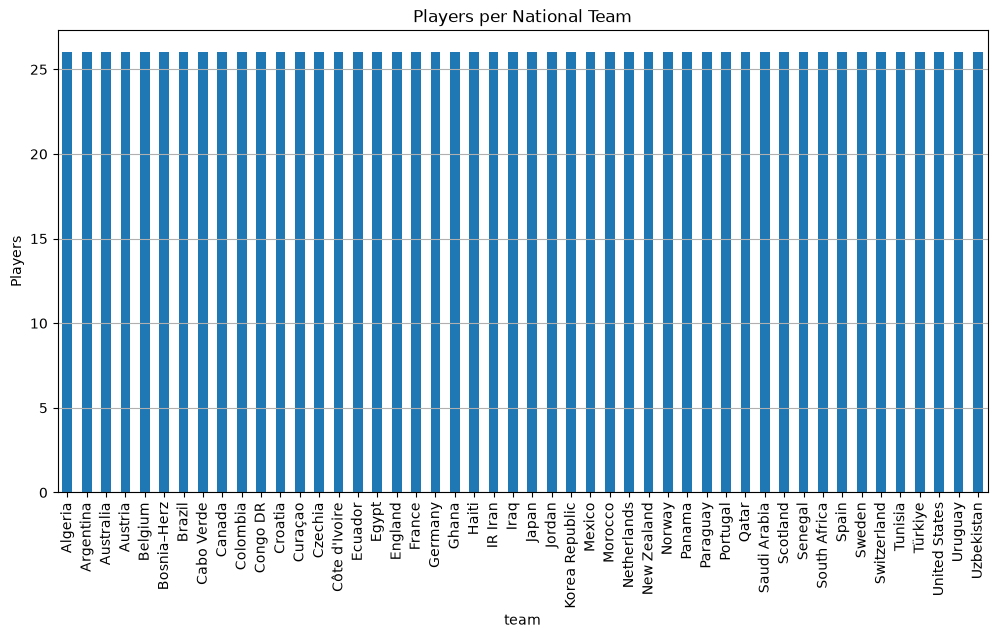

In [19]:
teams_count = (
    players["team"]
    .value_counts()
)

display(teams_count)

plt.figure(figsize=(12,6))

teams_count.plot(kind="bar")

plt.title("Players per National Team")

plt.ylabel("Players")

plt.grid(axis="y")

plt.show()

,player,team,goals
477,Kylian Mbappé,France,10.0
41,Lionel Messi,Argentina,8.0
811,Erling Haaland,Norway,7.0
458,Jude Bellingham,England,7.0
488,Ousmane Dembélé,France,6.0
451,Harry Kane,England,6.0
1055,Mikel Oyarzabal,Spain,5.0
717,Julián Quiñones,Mexico,4.0
179,Vinicius Júnior,Brazil,4.0
1000,Ismaila Sarr,Senegal,4.0


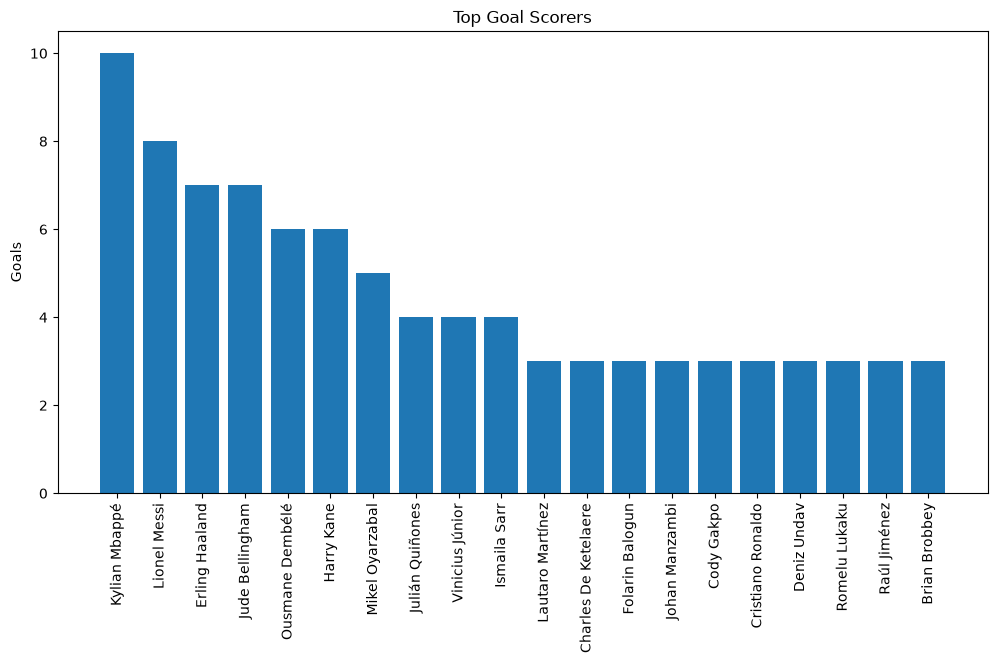

In [20]:
top_goals = (
    players[
        [
            "player",
            "team",
            "goals"
        ]
    ]
    .sort_values(
        "goals",
        ascending=False
    )
    .head(20)
)

display(top_goals)

plt.figure(figsize=(12,6))

plt.bar(
    top_goals["player"],
    top_goals["goals"]
)

plt.xticks(rotation=90)

plt.title("Top Goal Scorers")

plt.ylabel("Goals")

plt.show()

,player,team,assists
485,Michael Olise,France,7.0
477,Kylian Mbappé,France,4.0
41,Lionel Messi,Argentina,4.0
158,Bruno Guimarães,Brazil,4.0
737,Brahim Díaz,Morocco,4.0
822,Martin Ødegaard,Norway,4.0
502,Florian Wirtz,Germany,3.0
443,Bukayo Saka,England,3.0
442,Anthony Gordon,England,3.0
725,Roberto Alvarado,Mexico,3.0


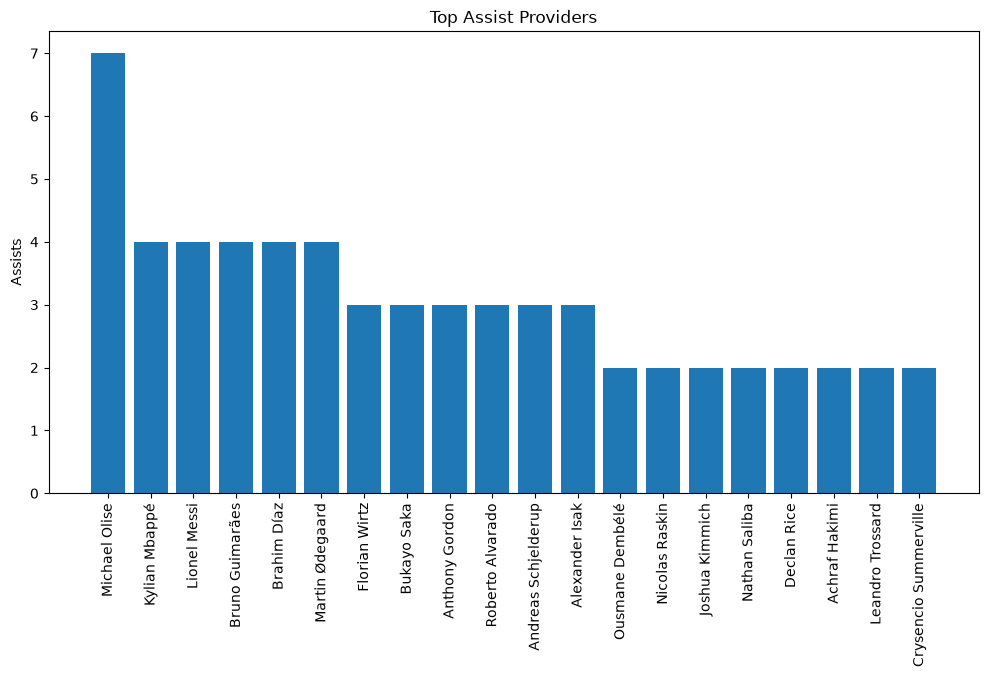

In [21]:
top_assists = (
    players[
        [
            "player",
            "team",
            "assists"
        ]
    ]
    .sort_values(
        "assists",
        ascending=False
    )
    .head(20)
)

display(top_assists)

plt.figure(figsize=(12,6))

plt.bar(
    top_assists["player"],
    top_assists["assists"]
)

plt.xticks(rotation=90)

plt.title("Top Assist Providers")

plt.ylabel("Assists")

plt.show()

In [22]:
players["goal_contribution"] = (
    players["goals"] +
    players["assists"]
)

goal_contribution = (

    players[
        [
            "player",
            "team",
            "goal_contribution"
        ]
    ]

    .sort_values(
        "goal_contribution",
        ascending=False
    )

    .head(20)

)

display(goal_contribution)

,player,team,goal_contribution
477,Kylian Mbappé,France,14.0
41,Lionel Messi,Argentina,12.0
488,Ousmane Dembélé,France,8.0
458,Jude Bellingham,England,8.0
485,Michael Olise,France,7.0
451,Harry Kane,England,7.0
811,Erling Haaland,Norway,7.0
1055,Mikel Oyarzabal,Spain,6.0
443,Bukayo Saka,England,6.0
500,Deniz Undav,Germany,5.0


In [23]:
minutes = (
    players[
        [
            "player",
            "minutes"
        ]
    ]
    .sort_values(
        "minutes",
        ascending=False
    )
    .head(20)
)

display(minutes)

,player,minutes
28,Emiliano Martínez,810.0
1057,Pau Cubarsí,750.0
1061,Unai Simón,750.0
1050,Marc Cucurella,750.0
26,Alexis Mac Allister,750.0
41,Lionel Messi,740.0
1040,Aymeric Laporte,727.0
1060,Rodri,724.0
486,Mike Maignan,720.0
477,Kylian Mbappé,695.0


In [24]:
goals90 = (
    players[
        [
            "player",
            "goals_per90"
        ]
    ]
    .sort_values(
        "goals_per90",
        ascending=False
    )
    .head(20)
)

display(goals90)

,player,goals_per90
1153,Kaan Ayhan,30.00
1086,Mattias Svanberg,5.63
140,Ermin Mahmić,2.65
893,Gonçalo Ramos,2.50
175,Neymar,2.31
270,Fiston Mayele,2.14
16,Nadhir Benbouali,2.00
425,Mahmoud Saber,1.96
500,Deniz Undav,1.79
921,Hassan Al-Haydos,1.58


In [25]:
assist90 = (
    players[
        [
            "player",
            "assists_per90"
        ]
    ]
    .sort_values(
        "assists_per90",
        ascending=False
    )
    .head(20)
)

display(assist90)

,player,assists_per90
32,Flaco López,4.50
136,Dennis Hadžikadunić,3.33
207,Yannick,2.81
1039,Tshepang Moremi,2.65
1148,Can Uzun,2.37
638,Kōki Ogawa,2.14
513,Nadiem Amiri,2.14
276,Meschak Elia,1.96
236,Cucho,1.80
769,Memphis,1.67


In [26]:
shots = (
    players[
        [
            "player",
            "shots"
        ]
    ]
    .sort_values(
        "shots",
        ascending=False
    )
    .head(20)
)

display(shots)

,player,shots
477,Kylian Mbappé,41.0
41,Lionel Messi,35.0
1049,Lamine Yamal,27.0
1055,Mikel Oyarzabal,23.0
451,Harry Kane,23.0
115,Kevin De Bruyne,20.0
488,Ousmane Dembélé,20.0
485,Michael Olise,20.0
811,Erling Haaland,20.0
458,Jude Bellingham,19.0


In [27]:
accuracy = (
    players[
        [
            "player",
            "shots_on_target_pct"
        ]
    ]
    .sort_values(
        "shots_on_target_pct",
        ascending=False
    )
    .head(20)
)

display(accuracy)

,player,shots_on_target_pct
1120,Anis Ben Slimane,100.0
16,Nadhir Benbouali,100.0
1068,Anthony Elanga,100.0
1070,Besfort Zeneli,100.0
1153,Kaan Ayhan,100.0
1166,Zeki Çelik,100.0
1137,Omar Rekik,100.0
34,Giovani Lo Celso,100.0
1106,Manuel Akanji,100.0
921,Hassan Al-Haydos,100.0


In [28]:
crosses = (
    players[
        [
            "player",
            "crosses"
        ]
    ]
    .sort_values(
        "crosses",
        ascending=False
    )
    .head(20)
)

display(crosses)

,player,crosses
41,Lionel Messi,54.0
231,Stephen Eustáquio,45.0
446,Declan Rice,44.0
1064,Álex Baena,41.0
725,Roberto Alvarado,36.0
728,Achraf Hakimi,35.0
1049,Lamine Yamal,34.0
488,Ousmane Dembélé,34.0
89,Marcel Sabitzer,31.0
506,Joshua Kimmich,31.0


In [29]:
tackles = (
    players[
        [
            "player",
            "tackles_won"
        ]
    ]
    .sort_values(
        "tackles_won",
        ascending=False
    )
    .head(20)
)

display(tackles)

,player,tackles_won
1060,Rodri,20.0
449,Elliot Anderson,18.0
469,Aurélien Tchouaméni,14.0
859,Andrés Cubas,13.0
21,Rayan Aït-Nouri,13.0
26,Alexis Mac Allister,12.0
543,Marvin Senaya,12.0
472,Dayot Upamecano,12.0
1059,Pedro Porro,11.0
410,Pedro Vite,11.0


In [30]:
interceptions = (
    players[
        [
            "player",
            "interceptions"
        ]
    ]
    .sort_values(
        "interceptions",
        ascending=False
    )
    .head(20)
)

display(interceptions)

,player,interceptions
472,Dayot Upamecano,15.0
1040,Aymeric Laporte,14.0
468,Adrien Rabiot,11.0
859,Andrés Cubas,11.0
674,Yazan Al-Arab,11.0
1021,Khuliso Mudau,11.0
328,Livano Comenencia,11.0
27,Cristian Romero,11.0
1058,Pedri,10.0
102,Stefan Posch,10.0


In [31]:
discipline = (
    players[
        [
            "player",
            "cards_yellow",
            "cards_red"
        ]
    ]
    .sort_values(
        "cards_yellow",
        ascending=False
    )
    .head(20)
)

display(discipline)

,player,cards_yellow,cards_red
742,Issa Diop,3.0,0.0
42,Lisandro Martínez,2.0,0.0
432,Mohanad Lasheen,2.0,0.0
279,Noah Sadiki,2.0,0.0
606,Amir Al Ammari,2.0,0.0
200,Sidny Lopes Cabral,2.0,0.0
27,Cristian Romero,2.0,0.0
322,Juninho Bacuna,2.0,0.0
390,Alan Franco,2.0,0.0
419,Haissem Hassan,2.0,0.0


In [32]:
gk = players[
    players["position"]=="GK"
]

goalkeepers = (
    gk[
        [
            "player",
            "team",
            "gk_saves",
            "gk_clean_sheets",
            "gk_save_pct"
        ]
    ]
    .sort_values(
        "gk_saves",
        ascending=False
    )
)

display(goalkeepers.head(20))

,player,team,gk_saves,gk_clean_sheets,gk_save_pct
881,Orlando Gill,Paraguay,23.0,2.0,79.3
316,Eloy Room,Curaçao,20.0,1.0,69.0
1103,Gregor Kobel,Switzerland,20.0,2.0,76.9
28,Emiliano Martínez,Argentina,20.0,2.0,71.4
887,Diogo Costa,Portugal,19.0,2.0,86.4
204,Vozinha,Cabo Verde,18.0,2.0,78.3
754,Bart Verbruggen,Netherlands,16.0,0.0,76.2
951,Mohammed Al-Owais,Saudi Arabia,16.0,1.0,76.2
574,Alireza Beiranvand,IR Iran,15.0,1.0,83.3
457,Jordan Pickford,England,15.0,2.0,65.2


In [33]:
top_goals.to_csv(
    "../reports/top_goal_scorers.csv",
    index=False
)

top_assists.to_csv(
    "../reports/top_assists.csv",
    index=False
)

goal_contribution.to_csv(
    "../reports/top_goal_contribution.csv",
    index=False
)

goalkeepers.head(20).to_csv(
    "../reports/top_goalkeepers.csv",
    index=False
)

print("="*60)
print("PLAYER EDA COMPLETED")
print("="*60)

PLAYER EDA COMPLETED


# Team Exploratory Data Analysis

This section covers:

- Team Overview
- Goals
- Goal Difference
- Assists
- Possession
- Shooting
- Discipline
- Crosses
- Interceptions
- Tackles
- Goalkeeping
- Team Rankings

In [34]:
# ==========================================================
# TEAM OVERVIEW
# ==========================================================

print("="*60)
print("TEAM OVERVIEW")
print("="*60)

print("Total Teams :", len(teams))

print("Average Goals :",
      round(teams["goals"].mean(),2))

print("Average Assists :",
      round(teams["assists"].mean(),2))

print("Average Possession :",
      round(teams["possession"].mean(),2))

TEAM OVERVIEW
Total Teams : 48
Average Goals : 6.15
Average Assists : 4.67
Average Possession : 48.63


,team,goals
18,France,20
17,England,20
1,Argentina,18
4,Belgium,13
40,Spain,13
31,Norway,12
19,Germany,11
6,Brazil,10
28,Morocco,10
27,Mexico,10


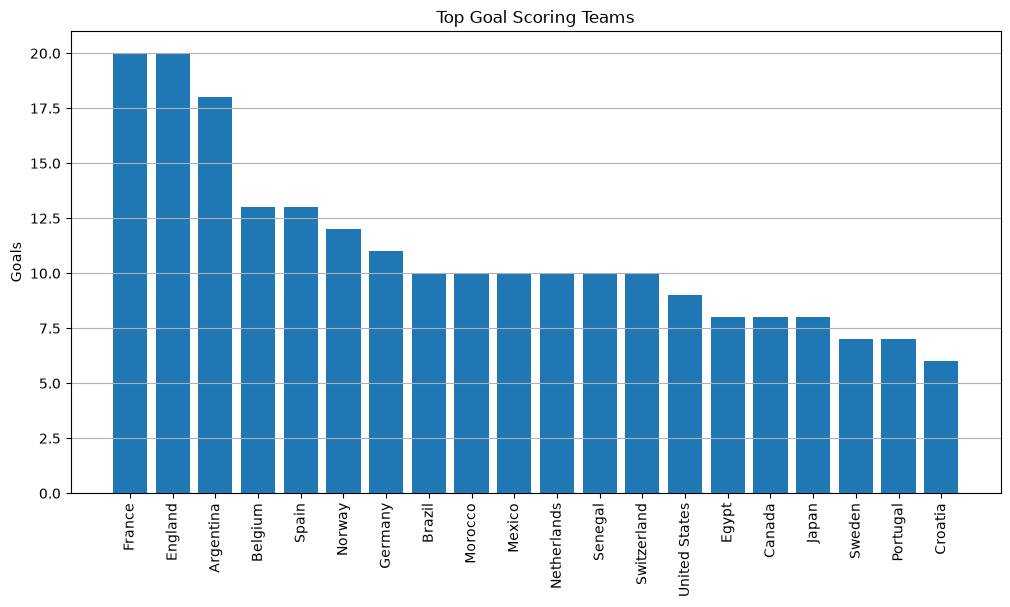

In [35]:
top_goals = (
    teams[
        ["team","goals"]
    ]
    .sort_values(
        "goals",
        ascending=False
    )
)

display(top_goals.head(20))

plt.figure(figsize=(12,6))

plt.bar(
    top_goals.head(20)["team"],
    top_goals.head(20)["goals"]
)

plt.xticks(rotation=90)

plt.title("Top Goal Scoring Teams")

plt.ylabel("Goals")

plt.grid(axis="y")

plt.show()

In [36]:
goals_against = (
    teams[
        ["team","goals_against"]
    ]
    .sort_values(
        "goals_against"
    )
)

display(goals_against.head(20))

,team,goals_against
9,Colombia,1
40,Spain,1
2,Australia,2
20,Ghana,3
27,Mexico,3
26,Korea Republic,3
34,Portugal,3
22,IR Iran,3
15,Ecuador,4
14,Côte d'Ivoire,4


,team,goal_difference
40,Spain,12
1,Argentina,10
18,France,10
17,England,8
27,Mexico,7
4,Belgium,6
6,Brazil,6
19,Germany,6
28,Morocco,5
29,Netherlands,5


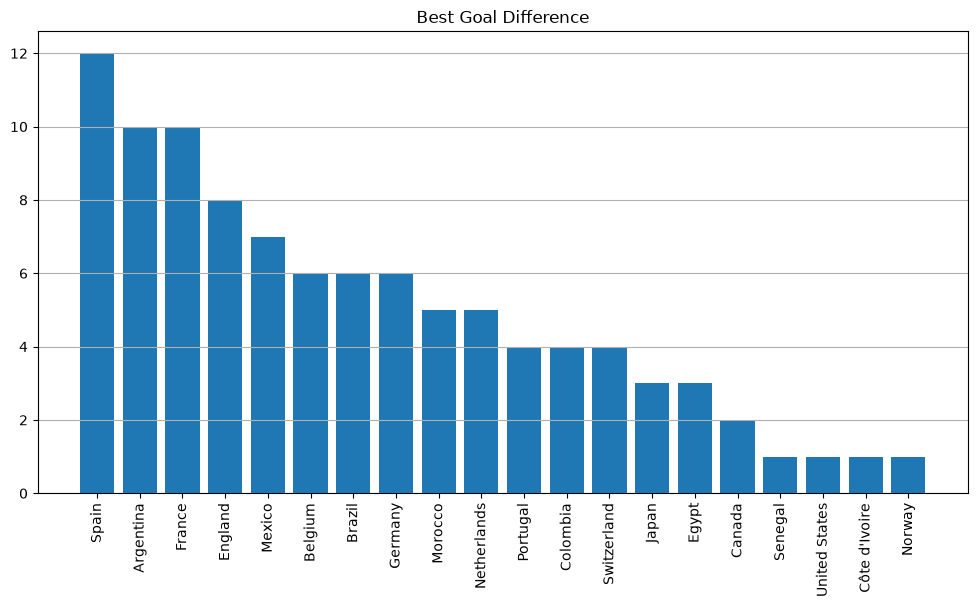

In [37]:
teams["goal_difference"] = (

    teams["goals"]

    -

    teams["goals_against"]

)

goal_difference = (

    teams[
        [
            "team",
            "goal_difference"
        ]
    ]

    .sort_values(
        "goal_difference",
        ascending=False
    )

)

display(goal_difference.head(20))

plt.figure(figsize=(12,6))

plt.bar(

    goal_difference.head(20)["team"],

    goal_difference.head(20)["goal_difference"]

)

plt.xticks(rotation=90)

plt.title("Best Goal Difference")

plt.grid(axis="y")

plt.show()

In [38]:
assists = (

    teams[
        [
            "team",
            "assists"
        ]
    ]

    .sort_values(
        "assists",
        ascending=False
    )

)

display(assists.head(20))

,team,assists
18,France,18
17,England,14
1,Argentina,12
4,Belgium,10
31,Norway,10
19,Germany,10
40,Spain,10
29,Netherlands,10
28,Morocco,9
38,Senegal,9


,team,possession
44,Türkiye,66.3
19,Germany,65.0
40,Spain,64.1
26,Korea Republic,63.0
0,Algeria,61.0
28,Morocco,59.0
34,Portugal,58.4
9,Colombia,57.8
1,Argentina,57.6
45,United States,56.8


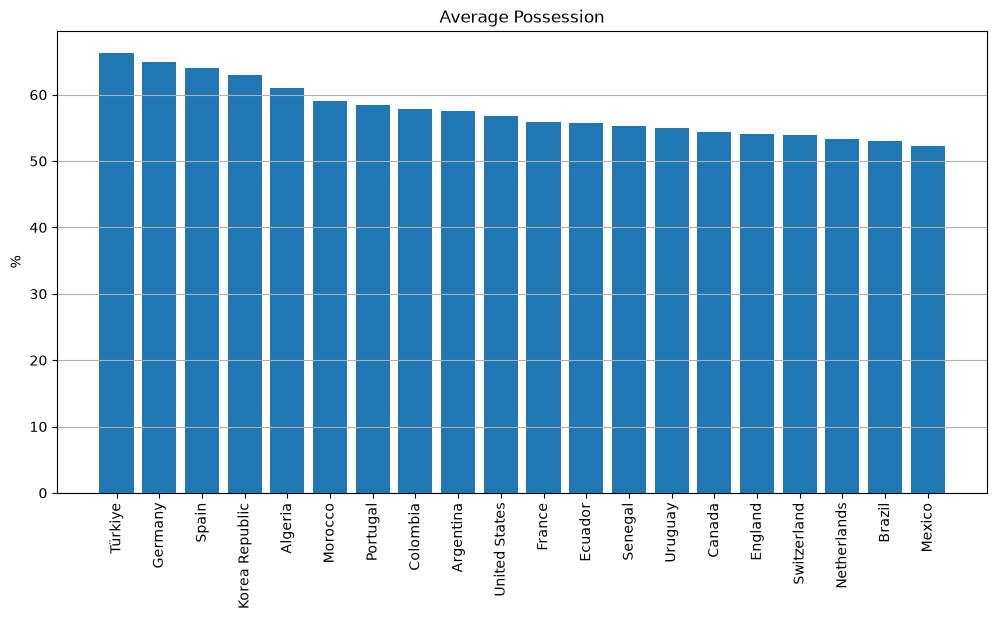

In [39]:
possession = (

    teams[
        [
            "team",
            "possession"
        ]
    ]

    .sort_values(
        "possession",
        ascending=False
    )

)

display(possession.head(20))

plt.figure(figsize=(12,6))

plt.bar(

    possession.head(20)["team"],

    possession.head(20)["possession"]

)

plt.xticks(rotation=90)

plt.title("Average Possession")

plt.ylabel("%")

plt.grid(axis="y")

plt.show()

In [40]:
shots = (

    teams[
        [
            "team",
            "shots"
        ]
    ]

    .sort_values(
        "shots",
        ascending=False
    )

)

display(shots.head(20))

,team,shots
40,Spain,140
18,France,139
17,England,118
1,Argentina,114
4,Belgium,112
9,Colombia,94
8,Canada,80
6,Brazil,74
19,Germany,74
42,Switzerland,74


In [41]:
accuracy = (

    teams[
        [
            "team",
            "shots_on_target_pct"
        ]
    ]

    .sort_values(
        "shots_on_target_pct",
        ascending=False
    )

)

display(accuracy.head(20))

,team,shots_on_target_pct
30,New Zealand,48.4
41,Sweden,47.9
29,Netherlands,47.8
11,Croatia,45.9
17,England,44.9
31,Norway,43.9
18,France,42.4
36,Saudi Arabia,41.2
42,Switzerland,40.5
6,Brazil,40.5


In [42]:
crosses = (

    teams[
        [
            "team",
            "crosses"
        ]
    ]

    .sort_values(
        "crosses",
        ascending=False
    )

)

display(crosses.head(20))

,team,crosses
40,Spain,165
17,England,163
8,Canada,146
4,Belgium,114
42,Switzerland,111
18,France,109
19,Germany,105
1,Argentina,104
6,Brazil,93
34,Portugal,92


In [43]:
tackles = (

    teams[
        [
            "team",
            "tackles_won"
        ]
    ]

    .sort_values(
        "tackles_won",
        ascending=False
    )

)

display(tackles.head(20))

,team,tackles_won
1,Argentina,93
40,Spain,88
33,Paraguay,88
17,England,77
18,France,77
31,Norway,67
28,Morocco,61
16,Egypt,54
19,Germany,53
42,Switzerland,52


In [44]:
interceptions = (

    teams[
        [
            "team",
            "interceptions"
        ]
    ]

    .sort_values(
        "interceptions",
        ascending=False
    )

)

display(interceptions.head(20))

,team,interceptions
1,Argentina,82
18,France,65
40,Spain,64
45,United States,60
33,Paraguay,53
7,Cabo Verde,52
42,Switzerland,52
17,England,51
4,Belgium,50
6,Brazil,48


In [45]:
discipline = (

    teams[
        [
            "team",
            "cards_yellow",
            "cards_red"
        ]
    ]

    .sort_values(
        "cards_yellow",
        ascending=False
    )

)

display(discipline.head(20))

,team,cards_yellow,cards_red
1,Argentina,15,1
16,Egypt,12,0
8,Canada,11,0
33,Paraguay,9,1
15,Ecuador,8,1
42,Switzerland,8,1
9,Colombia,8,0
6,Brazil,8,0
17,England,8,1
21,Haiti,7,0


In [46]:
fouls = (

    teams[
        [
            "team",
            "fouls"
        ]
    ]

    .sort_values(
        "fouls",
        ascending=False
    )

)

display(fouls.head(20))

,team,fouls
1,Argentina,113
40,Spain,101
42,Switzerland,87
18,France,84
17,England,81
4,Belgium,78
28,Morocco,74
8,Canada,72
9,Colombia,70
33,Paraguay,66


In [47]:
offsides = (

    teams[
        [
            "team",
            "offsides"
        ]
    ]

    .sort_values(
        "offsides",
        ascending=False
    )

)

display(offsides.head(20))

,team,offsides
1,Argentina,22
40,Spain,21
9,Colombia,19
17,England,15
18,France,14
46,Uruguay,14
42,Switzerland,13
6,Brazil,11
45,United States,11
3,Austria,11


In [48]:
goalkeeping = (

    teams[
        [
            "team",
            "gk_clean_sheets",
            "gk_save_pct"
        ]
    ]

    .sort_values(
        "gk_clean_sheets",
        ascending=False
    )

)

display(goalkeeping.head(20))

,team,gk_clean_sheets,gk_save_pct
40,Spain,7,90.9
9,Colombia,4,85.7
18,France,4,54.5
27,Mexico,4,72.7
8,Canada,2,50.0
1,Argentina,2,71.4
6,Brazil,2,77.8
2,Australia,2,82.4
17,England,2,62.5
33,Paraguay,2,79.3


In [51]:
teams.columns.tolist()

['team',
 'team_country',
 'players_used',
 'avg_age',
 'possession',
 'games',
 'games_starts',
 'minutes',
 'minutes_90s',
 'goals',
 'assists',
 'goals_assists',
 'goals_pens',
 'pens_made',
 'pens_att',
 'cards_yellow',
 'cards_red',
 'goals_per90',
 'assists_per90',
 'goals_assists_per90',
 'goals_pens_per90',
 'goals_assists_pens_per90',
 'players_used_against',
 'avg_age_against',
 'possession_against',
 'games_against',
 'games_starts_against',
 'minutes_against',
 'minutes_90s_against',
 'goals_against',
 'assists_against',
 'goals_assists_against',
 'goals_pens_against',
 'pens_made_against',
 'pens_att_against',
 'cards_yellow_against',
 'cards_red_against',
 'goals_per90_against',
 'assists_per90_against',
 'goals_assists_per90_against',
 'goals_pens_per90_against',
 'goals_assists_pens_per90_against',
 'shots',
 'shots_on_target',
 'shots_on_target_pct',
 'shots_per90',
 'shots_on_target_per90',
 'goals_per_shot',
 'goals_per_shot_on_target',
 'shots_against',
 'shots_on_t

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Load cleaned datasets
players = pd.read_csv("../data/interim/players_clean.csv")
teams = pd.read_csv("../data/interim/teams_clean.csv")
matches = pd.read_csv("../data/interim/matches_clean.csv")

print("Players:", players.shape)
print("Teams:", teams.shape)
print("Matches:", matches.shape)

Players: (1248, 70)
Teams: (48, 132)
Matches: (104, 42)


In [3]:
print("Teams dataset loaded successfully!")
print()

print("Columns:", len(teams.columns))
print()

display(teams.head())

Teams dataset loaded successfully!

Columns: 132



,team,team_country,players_used,avg_age,possession,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,players_used_against,avg_age_against,possession_against,games_against,games_starts_against,minutes_against,minutes_90s_against,goals_against,assists_against,goals_assists_against,goals_pens_against,pens_made_against,pens_att_against,cards_yellow_against,cards_red_against,goals_per90_against,assists_per90_against,goals_assists_per90_against,goals_pens_per90_against,goals_assists_pens_per90_against,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,shots_against,shots_on_target_against,shots_on_target_pct_against,shots_per90_against,shots_on_target_per90_against,goals_per_shot_against,goals_per_shot_on_target_against,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,minutes_per_game_against,minutes_pct_against,minutes_per_start_against,games_complete_against,games_subs_against,minutes_per_sub_against,unused_subs_against,points_per_game_against,on_goals_for_against,on_goals_against_against,plus_minus_against,plus_minus_per90_against,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,cards_yellow_red_against,fouls_against,fouled_against,offsides_against,crosses_against,interceptions_against,tackles_won_against,own_goals_against,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct,gk_games_against,gk_games_starts_against,gk_minutes_against,gk_goals_against_against,gk_goals_against_per90_against,gk_shots_on_target_against_against,gk_saves_against,gk_save_pct_against,gk_wins_against,gk_ties_against,gk_losses_against,gk_clean_sheets_against,gk_clean_sheets_pct_against,gk_pens_att_against,gk_pens_allowed_against,gk_pens_saved_against,gk_pens_missed_against,gk_pens_save_pct_against
0,Algeria,Algeria,22,27.3,61.0,4,44,360,4.0,5,3,8,5,0,0,3,0,1.25,0.75,2.00,1.25,2.00,22,29.1,39.0,4,44,360,4.0,9,7,16,9,0,0,2,0,2.25,1.75,4.00,2.25,4.00,44,15,34.1,11.00,3.75,0.11,0.33,39,18,46.2,9.75,4.50,0.23,0.50,90,100,81,25,19,21,37,1.00,5,9,-4,-1.00,90,100,81,24,20,20,39,1.75,9,5,4,1.00,0,29,40,4,40,30,44,0,0,41,27,7,37,41,50,0,4,4,360,9,2.25,17,8,47.1,1,1,2,0,0.0,0,0,0,0,0.0,4,4,360,5,1.25,15,10,66.7,2,1,1,2,50.0,0,0,0,0,0.0
1,Argentina,Argentina,24,29.6,57.6,8,88,810,9.0,18,12,30,17,1,3,15,1,2.00,1.33,3.33,1.89,3.22,24,28.3,42.4,8,88,810,9.0,8,8,16,8,0,0,14,1,0.89,0.89,1.78,0.89,1.78,114,44,38.6,12.67,4.89,0.15,0.39,75,28,37.3,8.33,3.11,0.11,0.29,101,100,87,45,42,30,78,2.63,19,8,11,1.22,101,100,87,45,42,25,74,0.38,8,19,-11,-1.22,1,113,100,22,104,82,93,0,1,107,109,12,121,82,67,1,8,8,810,8,0.89,28,20,71.4,7,0,1,2,25.0,0,0,0,0,0.0,8,8,810,19,2.11,43,24,55.8,1,0,7,1,12.5,3,1,1,1,50.0
2,Australia,Australia,23,25.3,41.0,4,44,390,4.3,2,1,3,2,0,0,5,0,0.46,0.23,0.69,0.46,0.69,23,27.8,59.0,4,44,390,4.3,2,1,3,2,0,0,7,0,0.46,0.23,0.69,0.46,0.69,42,12,28.6,9.69,2.77,0.05,0.17,61,15,24.6,14.08,3.46,0.03,0.13,98,100,85,25,19,28,37,1.25,3,3,0,0.00,98,100,85,24,20,19,35,1.25,3,3,0,0.00,0,46,38,1,70,29,34,1,0,39,45,7,71,41,38,1,4,4,390,3,0.69,17,14,82.4,1,1,2,2,50.0,0,0,0,0,0.0,4,4,390,3,0.69,13,10,76.9,2,1,1,2,50.0,0,0,0,0,0.0
3,Austria,Austria,20,28.8,45.0,4,44,360,4.0,5,4,9,4,1,1,5,0,1.25,1.00,2.25,1.00,2.00,20,27.8,55.0,4,44,360,4.0,9,7,16,9,0,1,2,0,2.25,1.75,4.00,2.25,4.00,32,8,25.0,8.00,2.00,0.13,0.50,58,24,41.4,14.50,6.00,0.16,0.38,90,100,77,24,20,28,40,1.00,6,9,-3,-0.75,90,100,77,25,19,14,40,1.75,9,6,3,0.75,0,47,28,11,59,41,29,0,0,31,42,6,46,29,37,1,4,4,360,9,2.25,22,13,59.1,1,1,2,0,0.0

In [5]:
# ==========================================================
# CELL 52 — TEAM PERFORMANCE TABLE
# ==========================================================

# Create goal difference if it doesn't already exist
if "goal_difference" not in teams.columns:
    teams["goal_difference"] = (
        teams["goals"] - teams["goals_against"]
    )

team_summary = teams[
    [
        "team",
        "games",
        "goals",
        "goals_against",
        "goal_difference",
        "points_per_game",
        "possession"
    ]
].sort_values(
    by=["goal_difference", "goals"],
    ascending=False
).reset_index(drop=True)

display(team_summary)

C:\Users\AYUSH SINGH\AppData\Local\Temp\ipykernel_7416\2590711225.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  teams["goal_difference"] = (


,team,games,goals,goals_against,goal_difference,points_per_game,possession
0,Spain,8,13,1,12,2.75,64.1
1,France,8,20,10,10,2.25,55.9
2,Argentina,8,18,8,10,2.63,57.6
3,England,8,20,12,8,2.38,54.1
4,Mexico,5,10,3,7,2.40,52.2
5,Belgium,6,13,7,6,1.83,51.2
6,Germany,4,11,5,6,1.75,65.0
7,Brazil,5,10,4,6,2.00,53.0
8,Morocco,6,10,5,5,1.83,59.0
9,Netherlands,4,10,5,5,2.00,53.3


In [6]:
# ==========================================================
# CELL 53 — TOP 10 TEAMS BY GOALS
# ==========================================================

top_goal_teams = (
    teams[
        [
            "team",
            "games",
            "goals",
            "goals_per90"
        ]
    ]
    .sort_values("goals", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(top_goal_teams)

,team,games,goals,goals_per90
0,France,8,20,2.50
1,England,8,20,2.40
2,Argentina,8,18,2.00
3,Belgium,6,13,2.05
4,Spain,8,13,1.56
5,Norway,6,12,1.89
6,Germany,4,11,2.54
7,Brazil,5,10,2.00
8,Morocco,6,10,1.58
9,Mexico,5,10,2.00


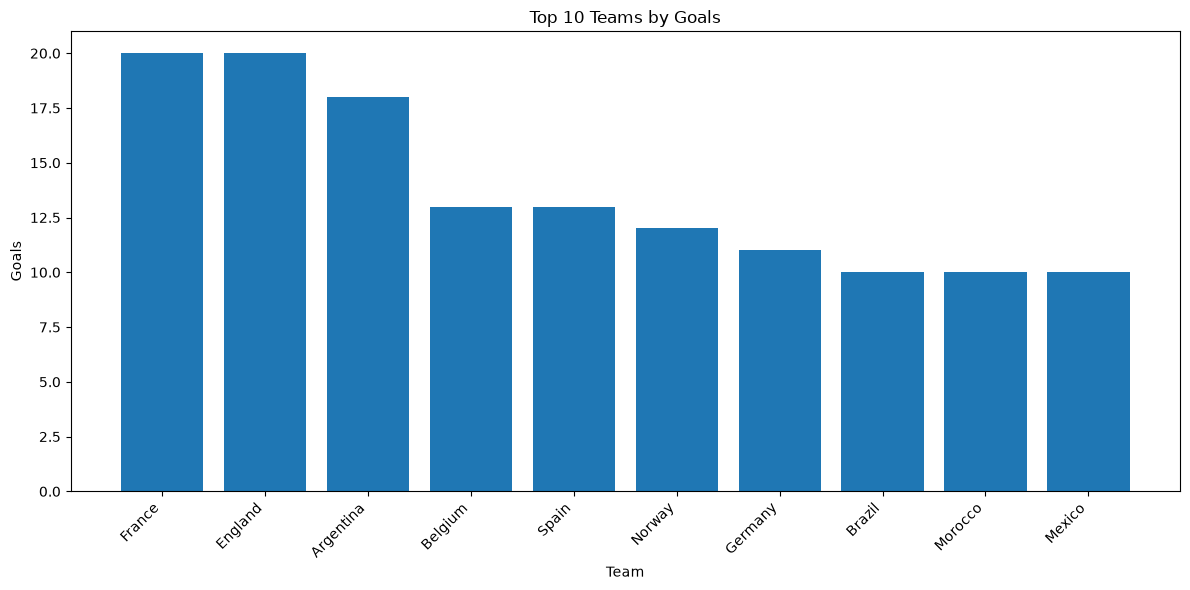

In [7]:
# ==========================================================
# CELL 54 — TOP 10 TEAMS BY GOALS
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_goal_teams["team"],
    top_goal_teams["goals"]
)

plt.title("Top 10 Teams by Goals")
plt.xlabel("Team")
plt.ylabel("Goals")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [8]:
# ==========================================================
# CELL 55 — BEST DEFENSIVE TEAMS
# ==========================================================

best_defenses = (
    teams[
        [
            "team",
            "games",
            "goals_against",
            "goal_difference",
            "gk_saves",
            "gk_save_pct",
            "gk_clean_sheets"
        ]
    ]
    .sort_values("goals_against", ascending=True)
    .head(10)
    .reset_index(drop=True)
)

display(best_defenses)

,team,games,goals_against,goal_difference,gk_saves,gk_save_pct,gk_clean_sheets
0,Colombia,5,1,4,6,85.7,4
1,Spain,8,1,12,9,90.9,7
2,Australia,4,2,0,14,82.4,2
3,Ghana,4,3,-1,16,84.2,2
4,Mexico,5,3,7,8,72.7,4
5,Korea Republic,3,3,-1,9,75.0,0
6,Portugal,5,3,4,19,86.4,2
7,IR Iran,3,3,0,15,83.3,1
8,Ecuador,4,4,-2,9,69.2,1
9,Côte d'Ivoire,4,4,1,9,69.2,2


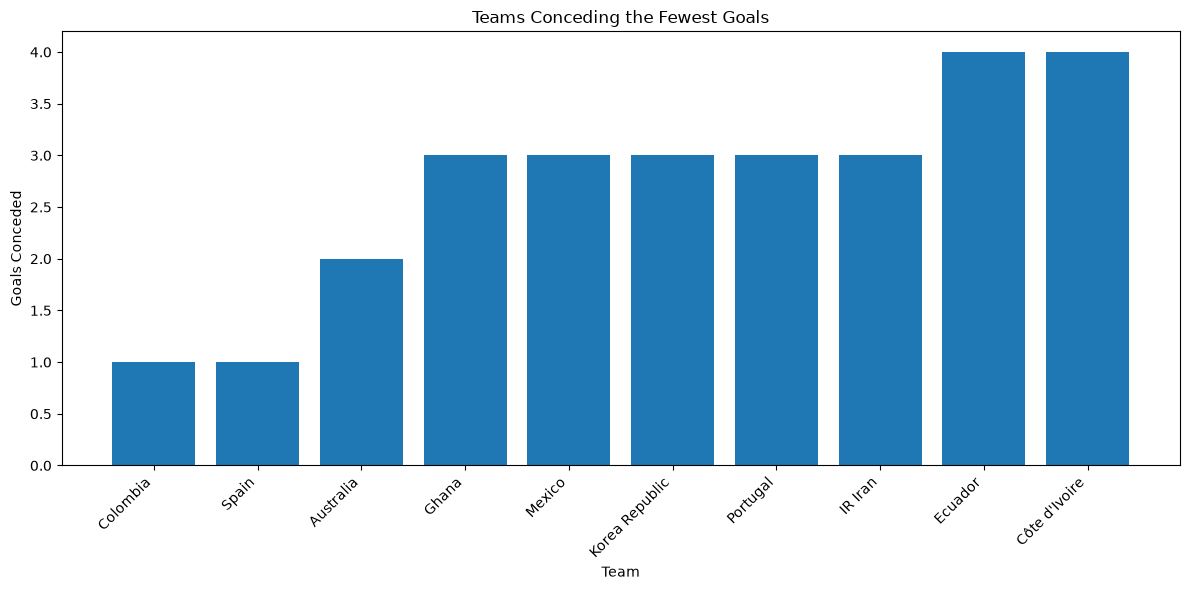

In [9]:
# ==========================================================
# CELL 56 — TEAMS CONCEDING FEWEST GOALS
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    best_defenses["team"],
    best_defenses["goals_against"]
)

plt.title("Teams Conceding the Fewest Goals")
plt.xlabel("Team")
plt.ylabel("Goals Conceded")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

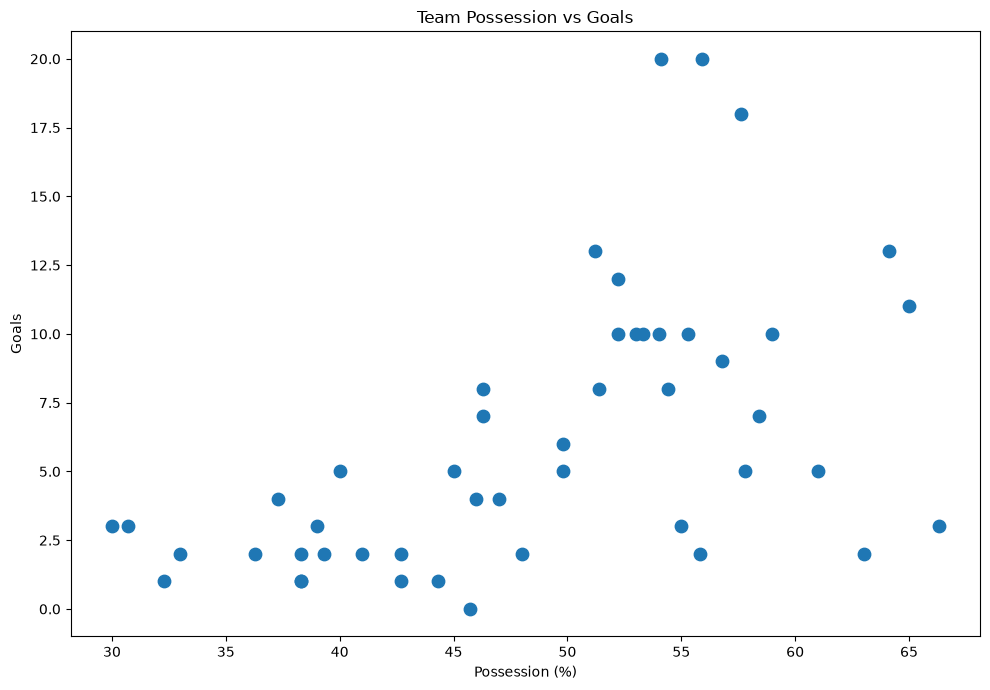

In [10]:
# ==========================================================
# CELL 57 — POSSESSION VS GOALS
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    teams["possession"],
    teams["goals"],
    s=80
)

plt.xlabel("Possession (%)")
plt.ylabel("Goals")
plt.title("Team Possession vs Goals")

plt.tight_layout()
plt.show()

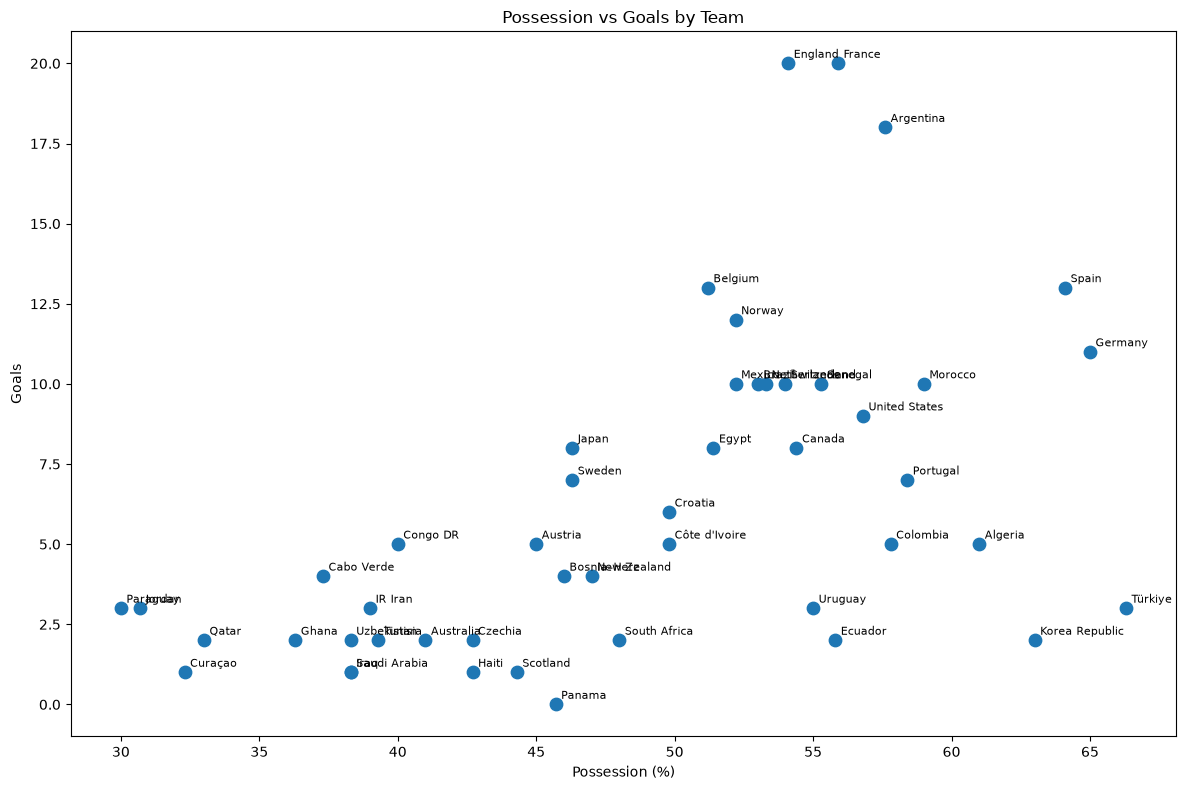

In [11]:
# ==========================================================
# CELL 58 — POSSESSION VS GOALS WITH TEAM LABELS
# ==========================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    teams["possession"],
    teams["goals"],
    s=80
)

for _, row in teams.iterrows():
    plt.annotate(
        row["team"],
        (
            row["possession"],
            row["goals"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Possession (%)")
plt.ylabel("Goals")
plt.title("Possession vs Goals by Team")

plt.tight_layout()
plt.show()

In [12]:
# ==========================================================
# CELL 59 — POSSESSION VS GOALS CORRELATION
# ==========================================================

possession_goals_corr = teams[
    ["possession", "goals"]
].corr()

display(possession_goals_corr)

,possession,goals
possession,1.00000,0.53983
goals,0.53983,1.00000


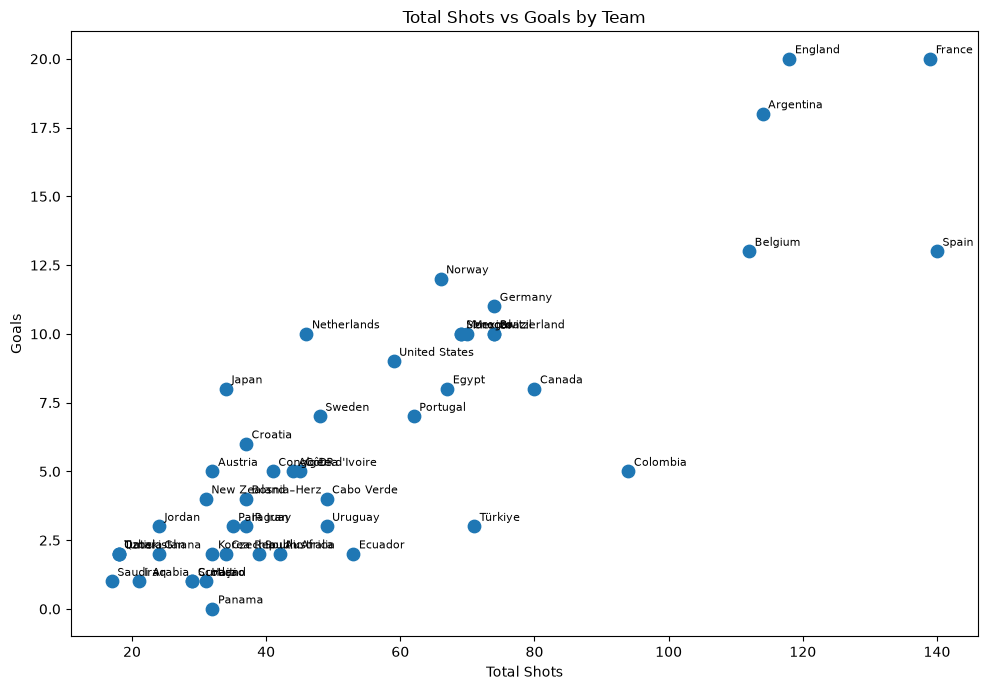

In [13]:
# ==========================================================
# CELL 60 — SHOTS VS GOALS
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    teams["shots"],
    teams["goals"],
    s=80
)

for _, row in teams.iterrows():
    plt.annotate(
        row["team"],
        (
            row["shots"],
            row["goals"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Total Shots")
plt.ylabel("Goals")
plt.title("Total Shots vs Goals by Team")

plt.tight_layout()
plt.show()

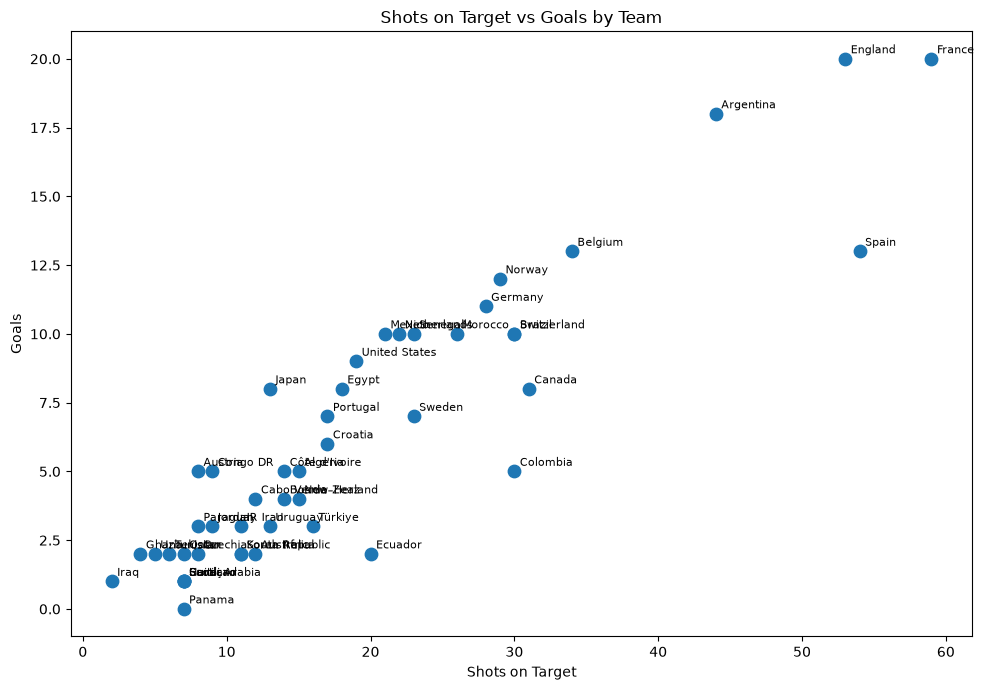

In [14]:
# ==========================================================
# CELL 61 — SHOTS ON TARGET VS GOALS
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    teams["shots_on_target"],
    teams["goals"],
    s=80
)

for _, row in teams.iterrows():
    plt.annotate(
        row["team"],
        (
            row["shots_on_target"],
            row["goals"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Shots on Target")
plt.ylabel("Goals")
plt.title("Shots on Target vs Goals by Team")

plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# CELL 62 — ATTACKING CORRELATIONS
# ==========================================================

attacking_corr = teams[
    [
        "possession",
        "shots",
        "shots_on_target",
        "goals",
        "assists",
        "goal_difference",
        "points_per_game"
    ]
].corr()

display(attacking_corr)

,possession,shots,shots_on_target,goals,assists,goal_difference,points_per_game
possession,1.000000,0.654559,0.622221,0.539830,0.524709,0.616659,0.639509
shots,0.654559,1.000000,0.955044,0.861190,0.816228,0.860486,0.812665
shots_on_target,0.622221,0.955044,1.000000,0.912963,0.875051,0.839472,0.815261
goals,0.539830,0.861190,0.912963,1.000000,0.958509,0.841596,0.813868
assists,0.524709,0.816228,0.875051,0.958509,1.000000,0.801841,0.757021
goal_difference,0.616659,0.860486,0.839472,0.841596,0.801841,1.000000,0.920580
points_per_game,0.639509,0.812665,0.815261,0.813868,0.757021,0.920580,1.000000


In [16]:
# ==========================================================
# CELL 63 — TEAM ATTACKING EFFICIENCY
# ==========================================================

team_efficiency = teams[
    [
        "team",
        "games",
        "goals",
        "goals_per90",
        "shots",
        "shots_on_target",
        "shots_on_target_pct",
        "goals_per_shot",
        "goals_per_shot_on_target"
    ]
].copy()

team_efficiency = team_efficiency.sort_values(
    by="goals_per_shot",
    ascending=False
)

display(team_efficiency)

,team,games,goals,goals_per90,shots,shots_on_target,shots_on_target_pct,goals_per_shot,goals_per_shot_on_target
24,Japan,4,8,2.00,34,13,38.2,0.24,0.62
29,Netherlands,4,10,2.31,46,22,47.8,0.22,0.45
31,Norway,6,12,1.89,66,29,43.9,0.18,0.41
11,Croatia,4,6,1.50,37,17,45.9,0.16,0.35
45,United States,5,9,1.80,59,19,32.2,0.15,0.47
1,Argentina,8,18,2.00,114,44,38.6,0.15,0.39
41,Sweden,4,7,1.75,48,23,47.9,0.15,0.30
18,France,8,20,2.50,139,59,42.4,0.14,0.32
17,England,8,20,2.40,118,53,44.9,0.14,0.32
28,Morocco,6,10,1.58,69,26,37.7,0.14,0.38


In [17]:
# ==========================================================
# CELL 64 — GOALS PER SHOT
# ==========================================================

efficient_attack = (
    teams[
        [
            "team",
            "shots",
            "goals",
            "goals_per_shot"
        ]
    ]
    .dropna(subset=["goals_per_shot"])
    .sort_values("goals_per_shot", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

display(efficient_attack)

,team,shots,goals,goals_per_shot
0,Japan,34,8,0.24
1,Netherlands,46,10,0.22
2,Norway,66,12,0.18
3,Croatia,37,6,0.16
4,United States,59,9,0.15
5,Argentina,114,18,0.15
6,Sweden,48,7,0.15
7,France,139,20,0.14
8,England,118,20,0.14
9,Morocco,69,10,0.14


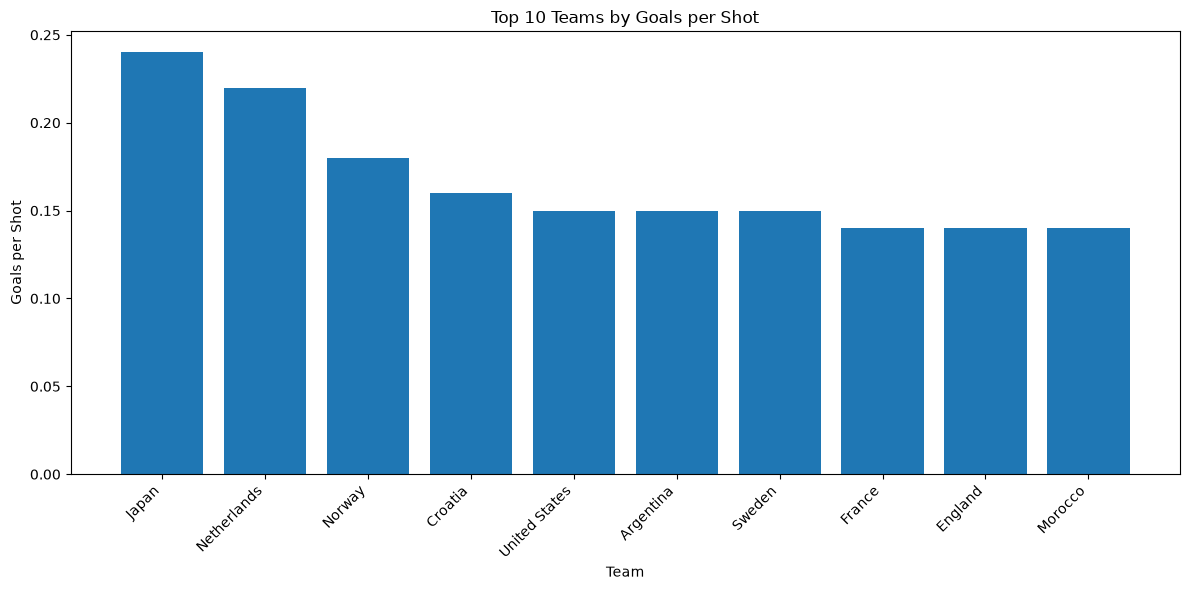

In [18]:
# ==========================================================
# CELL 65 — SHOT CONVERSION EFFICIENCY
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    efficient_attack["team"],
    efficient_attack["goals_per_shot"]
)

plt.title("Top 10 Teams by Goals per Shot")
plt.xlabel("Team")
plt.ylabel("Goals per Shot")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [19]:
# ==========================================================
# CELL 66 — SHOT ACCURACY
# ==========================================================

shot_accuracy = (
    teams[
        [
            "team",
            "shots",
            "shots_on_target",
            "shots_on_target_pct"
        ]
    ]
    .dropna(subset=["shots_on_target_pct"])
    .sort_values(
        "shots_on_target_pct",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(shot_accuracy)

,team,shots,shots_on_target,shots_on_target_pct
0,New Zealand,31,15,48.4
1,Sweden,48,23,47.9
2,Netherlands,46,22,47.8
3,Croatia,37,17,45.9
4,England,118,53,44.9
5,Norway,66,29,43.9
6,France,139,59,42.4
7,Saudi Arabia,17,7,41.2
8,Switzerland,74,30,40.5
9,Brazil,74,30,40.5


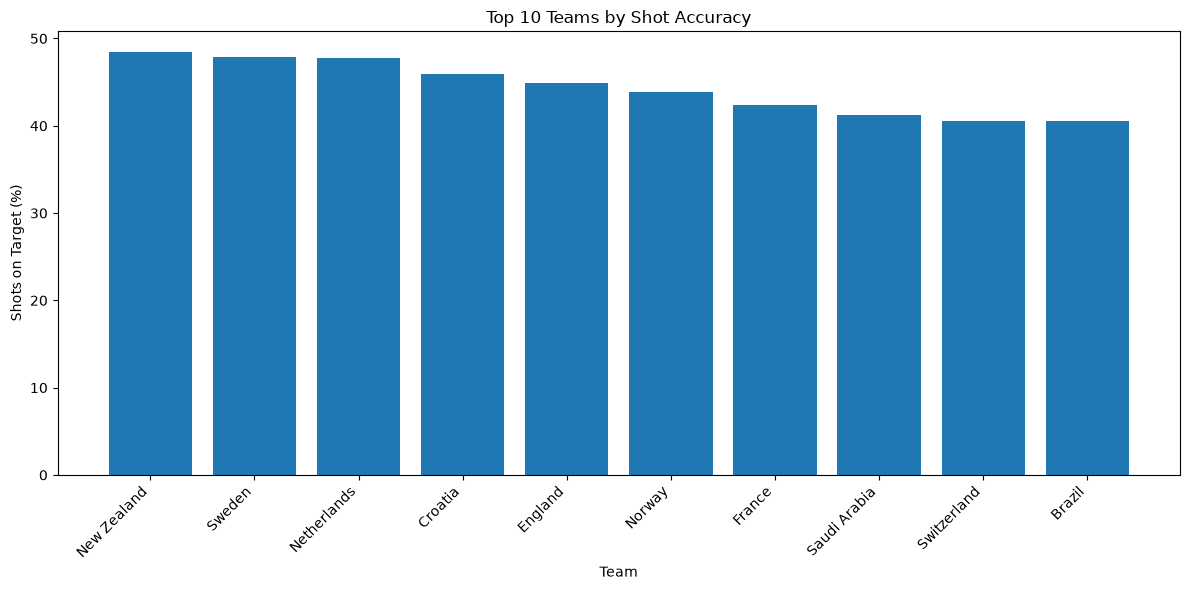

In [20]:
# ==========================================================
# CELL 67 — SHOT ACCURACY VISUALIZATION
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    shot_accuracy["team"],
    shot_accuracy["shots_on_target_pct"]
)

plt.title("Top 10 Teams by Shot Accuracy")
plt.xlabel("Team")
plt.ylabel("Shots on Target (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [21]:
# ==========================================================
# CELL 68 — GOALS PER 90
# ==========================================================

goals_per90 = (
    teams[
        [
            "team",
            "games",
            "goals",
            "goals_per90"
        ]
    ]
    .dropna(subset=["goals_per90"])
    .sort_values(
        "goals_per90",
        ascending=False
    )
    .reset_index(drop=True)
)

display(goals_per90)

,team,games,goals,goals_per90
0,Germany,4,11,2.54
1,France,8,20,2.50
2,England,8,20,2.40
3,Netherlands,4,10,2.31
4,Senegal,4,10,2.31
5,Belgium,6,13,2.05
6,Brazil,5,10,2.00
7,Argentina,8,18,2.00
8,Japan,4,8,2.00
9,Mexico,5,10,2.00


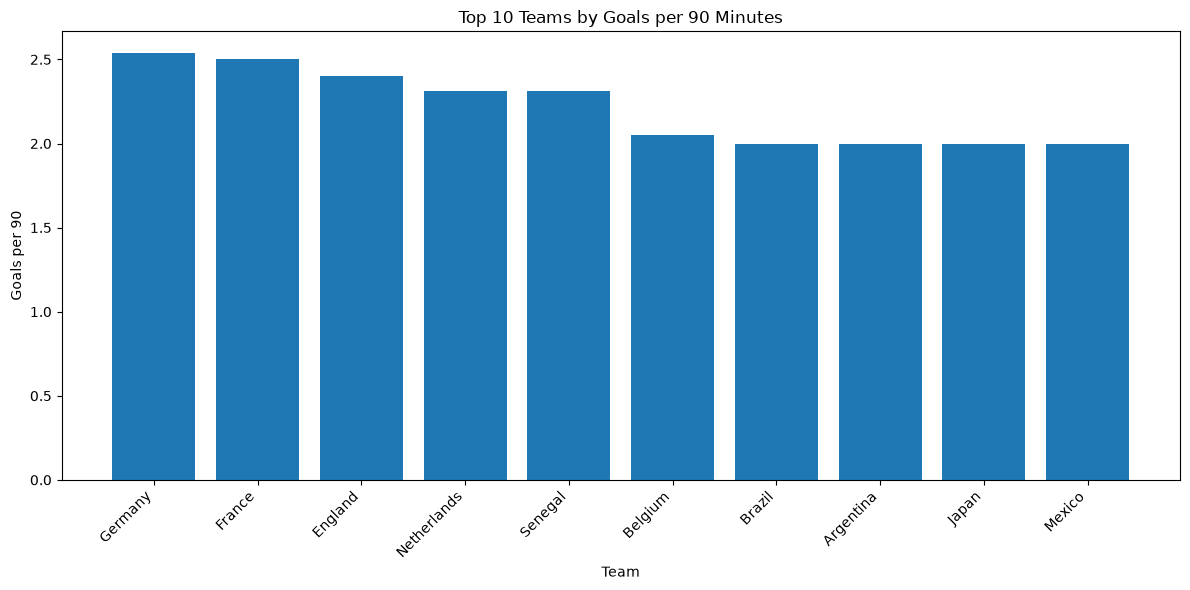

In [22]:
# ==========================================================
# CELL 69 — GOALS PER 90 VISUALIZATION
# ==========================================================

top_goals_per90 = goals_per90.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_goals_per90["team"],
    top_goals_per90["goals_per90"]
)

plt.title("Top 10 Teams by Goals per 90 Minutes")
plt.xlabel("Team")
plt.ylabel("Goals per 90")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [24]:
# ==========================================================
# CELL 70 — POSSESSION EFFICIENCY
# ==========================================================

team_efficiency["goals_per_possession"] = (
    team_efficiency["goals"] /
    team_efficiency["possession"]
    if "possession" in team_efficiency.columns
    else np.nan
)

In [25]:
# ==========================================================
# CELL 70 — POSSESSION EFFICIENCY
# ==========================================================

possession_efficiency = teams[
    [
        "team",
        "possession",
        "goals",
        "goals_per90"
    ]
].copy()

possession_efficiency["goals_per_possession"] = (
    possession_efficiency["goals"] /
    possession_efficiency["possession"]
)

possession_efficiency = possession_efficiency.sort_values(
    "goals_per_possession",
    ascending=False
)

display(possession_efficiency.head(10))

,team,possession,goals,goals_per90,goals_per_possession
17,England,54.1,20,2.40,0.369686
18,France,55.9,20,2.50,0.357782
1,Argentina,57.6,18,2.00,0.312500
4,Belgium,51.2,13,2.05,0.253906
31,Norway,52.2,12,1.89,0.229885
40,Spain,64.1,13,1.56,0.202808
27,Mexico,52.2,10,2.00,0.191571
6,Brazil,53.0,10,2.00,0.188679
29,Netherlands,53.3,10,2.31,0.187617
42,Switzerland,54.0,10,1.50,0.185185


In [26]:
# ==========================================================
# CELL 71 — DEFENSIVE OVERVIEW
# ==========================================================

defensive_stats = teams[
    [
        "team",
        "games",
        "goals_against",
        "goal_difference",
        "interceptions",
        "tackles_won",
        "fouls",
        "offsides",
        "cards_yellow",
        "cards_red"
    ]
].copy()

defensive_stats = defensive_stats.sort_values(
    "goals_against",
    ascending=True
)

display(defensive_stats)

,team,games,goals_against,goal_difference,interceptions,tackles_won,fouls,offsides,cards_yellow,cards_red
9,Colombia,5,1,4,38,33,70,19,8,0
40,Spain,8,1,12,64,88,101,21,6,0
2,Australia,4,2,0,29,34,46,1,5,0
20,Ghana,4,3,-1,31,40,56,8,6,0
27,Mexico,5,3,7,36,32,58,5,4,1
26,Korea Republic,3,3,-1,20,23,25,8,4,0
34,Portugal,5,3,4,30,39,44,10,7,0
22,IR Iran,3,3,0,32,36,35,9,6,0
15,Ecuador,4,4,-2,38,49,49,2,8,1
14,Côte d'Ivoire,4,4,1,40,48,29,4,4,0


In [27]:
# ==========================================================
# CELL 72 — FEWEST GOALS CONCEDED
# ==========================================================

best_defensive_teams = (
    teams[
        [
            "team",
            "games",
            "goals_against",
            "goal_difference"
        ]
    ]
    .sort_values(
        "goals_against",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

display(best_defensive_teams)

,team,games,goals_against,goal_difference
0,Colombia,5,1,4
1,Spain,8,1,12
2,Australia,4,2,0
3,Ghana,4,3,-1
4,Mexico,5,3,7
5,Korea Republic,3,3,-1
6,Portugal,5,3,4
7,IR Iran,3,3,0
8,Ecuador,4,4,-2
9,Côte d'Ivoire,4,4,1


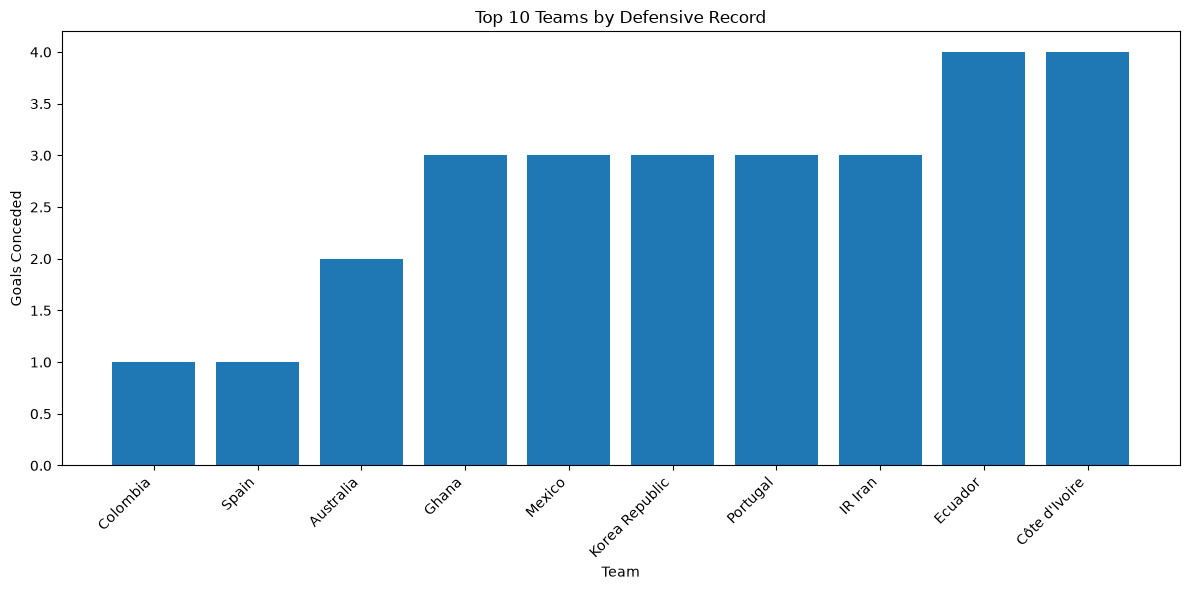

In [28]:
# ==========================================================
# CELL 73 — GOALS CONCEDED VISUALIZATION
# ==========================================================

plt.figure(figsize=(12, 6))

plt.bar(
    best_defensive_teams["team"],
    best_defensive_teams["goals_against"]
)

plt.title("Top 10 Teams by Defensive Record")
plt.xlabel("Team")
plt.ylabel("Goals Conceded")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

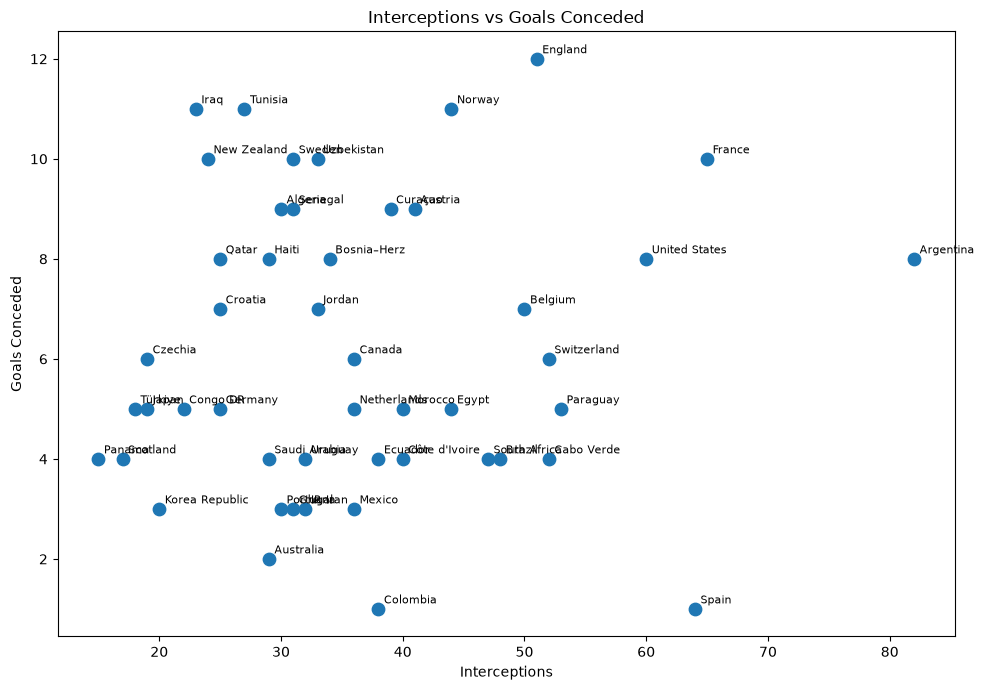

In [29]:
# ==========================================================
# CELL 74 — INTERCEPTIONS VS GOALS CONCEDED
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    teams["interceptions"],
    teams["goals_against"],
    s=80
)

for _, row in teams.iterrows():
    plt.annotate(
        row["team"],
        (
            row["interceptions"],
            row["goals_against"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Interceptions")
plt.ylabel("Goals Conceded")
plt.title("Interceptions vs Goals Conceded")

plt.tight_layout()
plt.show()

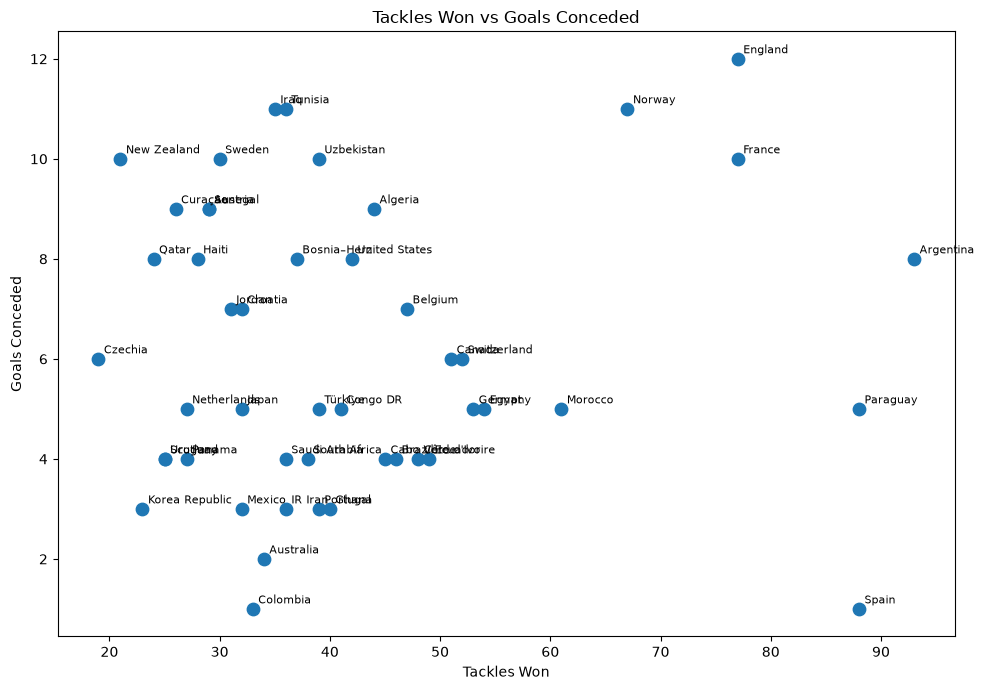

In [30]:
# ==========================================================
# CELL 75 — TACKLES WON VS GOALS CONCEDED
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    teams["tackles_won"],
    teams["goals_against"],
    s=80
)

for _, row in teams.iterrows():
    plt.annotate(
        row["team"],
        (
            row["tackles_won"],
            row["goals_against"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Tackles Won")
plt.ylabel("Goals Conceded")
plt.title("Tackles Won vs Goals Conceded")

plt.tight_layout()
plt.show()

In [31]:
# ==========================================================
# CELL 76 — DEFENSIVE CORRELATIONS
# ==========================================================

defensive_corr = teams[
    [
        "goals_against",
        "interceptions",
        "tackles_won",
        "fouls",
        "offsides",
        "cards_yellow",
        "cards_red",
        "goal_difference",
        "points_per_game"
    ]
].corr()

display(defensive_corr)

,goals_against,interceptions,tackles_won,fouls,offsides,cards_yellow,cards_red,goal_difference,points_per_game
goals_against,1.000000,0.084074,0.058631,-0.023544,-0.084724,-0.129753,0.104840,-0.335841,-0.240960
interceptions,0.084074,1.000000,0.769489,0.705866,0.610053,0.606420,0.306373,0.598656,0.625095
tackles_won,0.058631,0.769489,1.000000,0.749217,0.458592,0.538997,0.145879,0.620846,0.620319
fouls,-0.023544,0.705866,0.749217,1.000000,0.616223,0.649886,0.189786,0.722968,0.722019
offsides,-0.084724,0.610053,0.458592,0.616223,1.000000,0.391564,0.055470,0.612667,0.592094
cards_yellow,-0.129753,0.606420,0.538997,0.649886,0.391564,1.000000,0.213047,0.397143,0.384186
cards_red,0.104840,0.306373,0.145879,0.189786,0.055470,0.213047,1.000000,0.007441,0.078854
goal_difference,-0.335841,0.598656,0.620846,0.722968,0.612667,0.397143,0.007441,1.000000,0.920580
points_per_game,-0.240960,0.625095,0.620319,0.722019,0.592094,0.384186,0.078854,0.920580,1.000000


In [32]:
# ==========================================================
# CELL 77 — DEFENSIVE PERFORMANCE SCORE
# ==========================================================

defensive_score = teams[
    [
        "team",
        "goals_against",
        "goal_difference",
        "interceptions",
        "tackles_won",
        "gk_clean_sheets"
    ]
].copy()

# Normalize selected metrics
defensive_score["conceding_score"] = (
    1 - (
        defensive_score["goals_against"] -
        defensive_score["goals_against"].min()
    ) / (
        defensive_score["goals_against"].max() -
        defensive_score["goals_against"].min()
    )
)

defensive_score["goal_difference_score"] = (
    defensive_score["goal_difference"] -
    defensive_score["goal_difference"].min()
) / (
    defensive_score["goal_difference"].max() -
    defensive_score["goal_difference"].min()
)

defensive_score["clean_sheet_score"] = (
    defensive_score["gk_clean_sheets"] -
    defensive_score["gk_clean_sheets"].min()
) / (
    defensive_score["gk_clean_sheets"].max() -
    defensive_score["gk_clean_sheets"].min()
)

# Combined score
defensive_score["defensive_score"] = (
    defensive_score["conceding_score"] * 0.50 +
    defensive_score["goal_difference_score"] * 0.30 +
    defensive_score["clean_sheet_score"] * 0.20
)

defensive_score = defensive_score.sort_values(
    "defensive_score",
    ascending=False
).reset_index(drop=True)

display(
    defensive_score[
        [
            "team",
            "goals_against",
            "goal_difference",
            "gk_clean_sheets",
            "defensive_score"
        ]
    ].head(10)
)

,team,goals_against,goal_difference,gk_clean_sheets,defensive_score
0,Spain,1,12,7,1.000000
1,Colombia,1,4,4,0.805195
2,Mexico,3,7,4,0.755195
3,Portugal,3,4,2,0.657143
4,Australia,2,0,2,0.648052
5,Brazil,4,6,2,0.638961
6,Ghana,3,-1,2,0.588961
7,Morocco,5,5,2,0.579870
8,IR Iran,3,0,1,0.574026
9,Côte d'Ivoire,4,1,2,0.570779


In [33]:
# ==========================================================
# CELL 78 — GOALKEEPER OVERVIEW
# ==========================================================

goalkeeper_stats = teams[
    [
        "team",
        "gk_games",
        "gk_games_starts",
        "gk_minutes",
        "gk_goals_against",
        "gk_saves",
        "gk_save_pct",
        "gk_clean_sheets",
        "gk_clean_sheets_pct"
    ]
].copy()

goalkeeper_stats = goalkeeper_stats.sort_values(
    "gk_save_pct",
    ascending=False
)

display(goalkeeper_stats)

,team,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_saves,gk_save_pct,gk_clean_sheets,gk_clean_sheets_pct
40,Spain,8,8,750,1,9,90.9,7,87.5
34,Portugal,5,5,450,3,19,86.4,2,40.0
9,Colombia,5,5,480,1,6,85.7,4,80.0
20,Ghana,4,4,360,3,16,84.2,2,50.0
22,IR Iran,3,3,270,3,15,83.3,1,33.3
2,Australia,4,4,390,3,14,82.4,2,50.0
33,Paraguay,5,5,480,6,23,79.3,2,40.0
7,Cabo Verde,4,4,390,5,18,78.3,2,50.0
6,Brazil,5,5,450,4,14,77.8,2,40.0
42,Switzerland,6,6,600,6,20,76.9,2,33.3


In [34]:
# ==========================================================
# CELL 79 — BEST GOALKEEPERS BY SAVE %
# ==========================================================

best_goalkeepers = (
    teams[
        [
            "team",
            "gk_games",
            "gk_minutes",
            "gk_saves",
            "gk_save_pct",
            "gk_clean_sheets",
            "gk_clean_sheets_pct"
        ]
    ]
    .dropna(subset=["gk_save_pct"])
    .sort_values(
        "gk_save_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

display(best_goalkeepers.head(10))

,team,gk_games,gk_minutes,gk_saves,gk_save_pct,gk_clean_sheets,gk_clean_sheets_pct
0,Spain,8,750,9,90.9,7,87.5
1,Portugal,5,450,19,86.4,2,40.0
2,Colombia,5,480,6,85.7,4,80.0
3,Ghana,4,360,16,84.2,2,50.0
4,IR Iran,3,270,15,83.3,1,33.3
5,Australia,4,390,14,82.4,2,50.0
6,Paraguay,5,480,23,79.3,2,40.0
7,Cabo Verde,4,390,18,78.3,2,50.0
8,Brazil,5,450,14,77.8,2,40.0
9,Switzerland,6,600,20,76.9,2,33.3


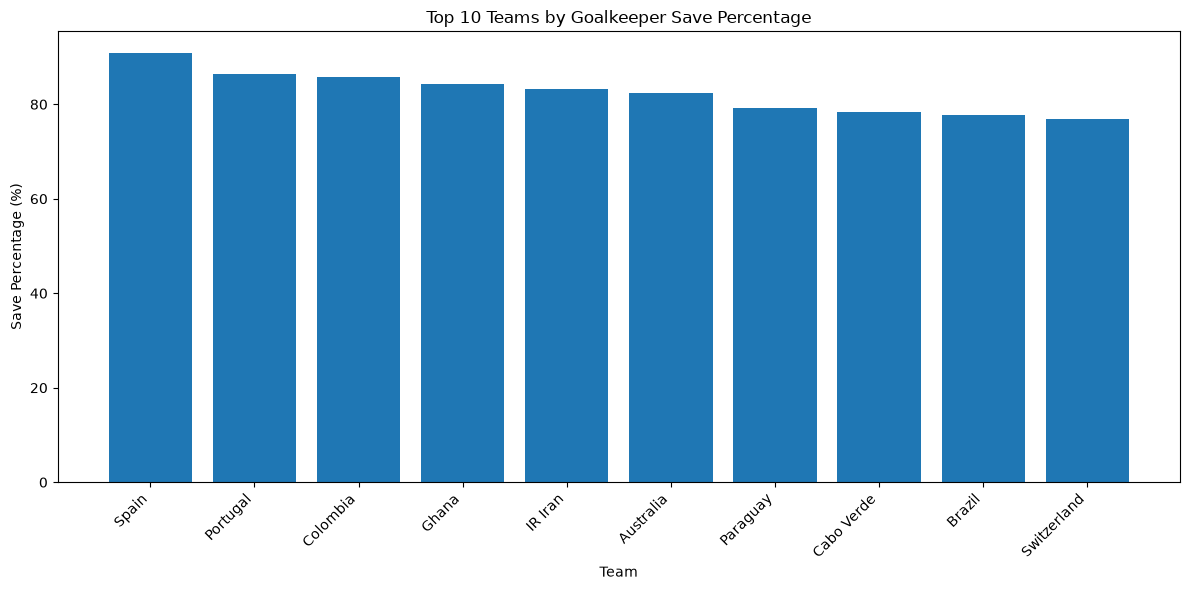

In [35]:
# ==========================================================
# CELL 80 — SAVE PERCENTAGE
# ==========================================================

top_gks = best_goalkeepers.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_gks["team"],
    top_gks["gk_save_pct"]
)

plt.title("Top 10 Teams by Goalkeeper Save Percentage")
plt.xlabel("Team")
plt.ylabel("Save Percentage (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [36]:
# ==========================================================
# CELL 81 — CLEAN SHEETS
# ==========================================================

clean_sheet_ranking = (
    teams[
        [
            "team",
            "gk_games",
            "gk_clean_sheets",
            "gk_clean_sheets_pct"
        ]
    ]
    .dropna(subset=["gk_clean_sheets"])
    .sort_values(
        "gk_clean_sheets",
        ascending=False
    )
    .reset_index(drop=True)
)

display(clean_sheet_ranking.head(10))

,team,gk_games,gk_clean_sheets,gk_clean_sheets_pct
0,Spain,8,7,87.5
1,Colombia,5,4,80.0
2,France,8,4,50.0
3,Mexico,5,4,80.0
4,Canada,5,2,40.0
5,Argentina,8,2,25.0
6,Brazil,5,2,40.0
7,Australia,4,2,50.0
8,England,8,2,25.0
9,Paraguay,5,2,40.0


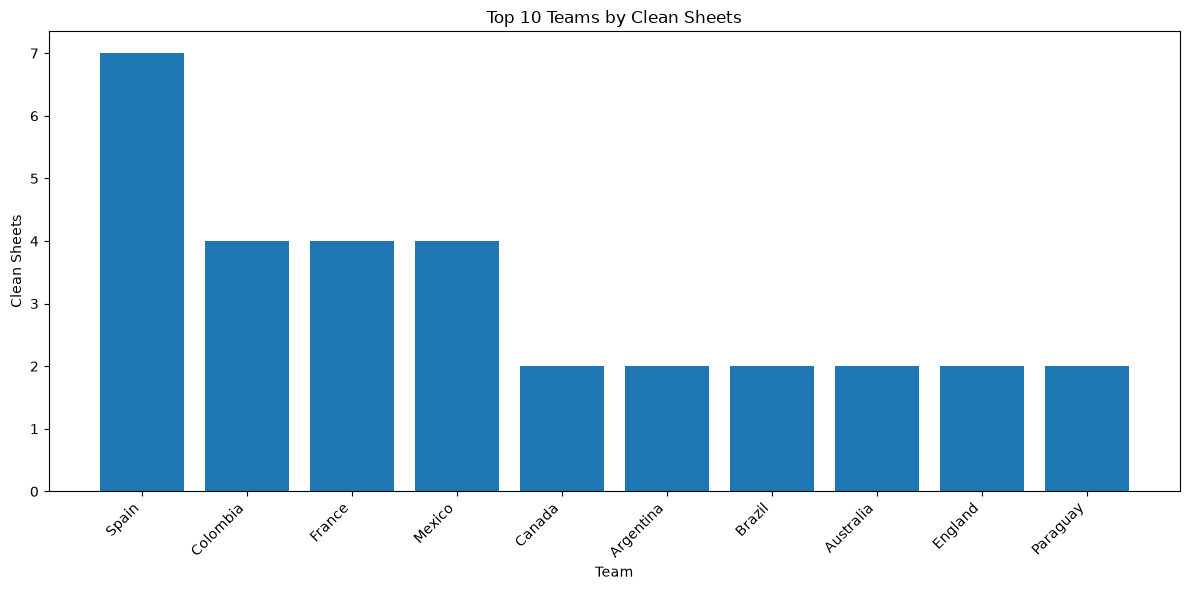

In [37]:
# ==========================================================
# CELL 82 — CLEAN SHEETS VISUALIZATION
# ==========================================================

top_clean_sheets = clean_sheet_ranking.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_clean_sheets["team"],
    top_clean_sheets["gk_clean_sheets"]
)

plt.title("Top 10 Teams by Clean Sheets")
plt.xlabel("Team")
plt.ylabel("Clean Sheets")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [38]:
# ==========================================================
# CELL 83 — GOALKEEPER PERFORMANCE SUMMARY
# ==========================================================

goalkeeper_summary = teams[
    [
        "team",
        "gk_games",
        "gk_minutes",
        "gk_goals_against",
        "gk_saves",
        "gk_save_pct",
        "gk_clean_sheets",
        "gk_clean_sheets_pct"
    ]
].copy()

goalkeeper_summary["goals_conceded_per90"] = (
    goalkeeper_summary["gk_goals_against"] /
    (goalkeeper_summary["gk_minutes"] / 90)
)

goalkeeper_summary = goalkeeper_summary.sort_values(
    "gk_save_pct",
    ascending=False
).reset_index(drop=True)

display(goalkeeper_summary.head(15))

,team,gk_games,gk_minutes,gk_goals_against,gk_saves,gk_save_pct,gk_clean_sheets,gk_clean_sheets_pct,goals_conceded_per90
0,Spain,8,750,1,9,90.9,7,87.5,0.120000
1,Portugal,5,450,3,19,86.4,2,40.0,0.600000
2,Colombia,5,480,1,6,85.7,4,80.0,0.187500
3,Ghana,4,360,3,16,84.2,2,50.0,0.750000
4,IR Iran,3,270,3,15,83.3,1,33.3,1.000000
5,Australia,4,390,3,14,82.4,2,50.0,0.692308
6,Paraguay,5,480,6,23,79.3,2,40.0,1.125000
7,Cabo Verde,4,390,5,18,78.3,2,50.0,1.153846
8,Brazil,5,450,4,14,77.8,2,40.0,0.800000
9,Switzerland,6,600,6,20,76.9,2,33.3,0.900000


In [39]:
# ==========================================================
# CELL 84 — PLAYER PERFORMANCE OVERVIEW
# ==========================================================

player_performance = players[
    [
        "player",
        "team",
        "position",
        "age",
        "games",
        "games_starts",
        "minutes",
        "goals",
        "assists",
        "shots",
        "shots_on_target",
        "cards_yellow",
        "cards_red"
    ]
].copy()

display(player_performance.head(20))

,player,team,position,age,games,games_starts,minutes,goals,assists,shots,shots_on_target,cards_yellow,cards_red
0,Achref Abada,Algeria,DF,26,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Adil Boulbina,Algeria,FW,23,2,0,19.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,FW,26,4,3,251.0,1.0,0.0,3.0,2.0,0.0,0.0
3,Anis Hadj Moussa,Algeria,MF,24,3,1,98.0,0.0,0.0,2.0,0.0,0.0,0.0
4,Aïssa Mandi,Algeria,DF,34,4,4,360.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Fares Chaïbi,Algeria,MF,23,4,4,360.0,0.0,0.0,9.0,3.0,1.0,0.0
6,Farés Ghedjemis,Algeria,"FW,MF",23,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Hicham Boudaoui,Algeria,MF,26,3,2,128.0,0.0,0.0,0.0,0.0,1.0,0.0
8,Houssem Aouar,Algeria,MF,27,3,2,173.0,0.0,2.0,3.0,1.0,0.0,0.0
9,Ibrahim Maza,Algeria,"MF,FW",20,4,4,351.0,0.0,0.0,11.0,3.0,0.0,0.0


In [40]:
# ==========================================================
# CELL 85 — TOP GOAL SCORERS
# ==========================================================

top_scorers = (
    players[
        [
            "player",
            "team",
            "position",
            "games",
            "minutes",
            "goals",
            "goals_per90",
            "shots",
            "shots_on_target"
        ]
    ]
    .dropna(subset=["goals"])
    .sort_values(
        ["goals", "goals_per90"],
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(top_scorers)

,player,team,position,games,minutes,goals,goals_per90,shots,shots_on_target
0,Kylian Mbappé,France,FW,8,695.0,10.0,1.29,41.0,23.0
1,Lionel Messi,Argentina,FW,8,740.0,8.0,0.97,35.0,18.0
2,Erling Haaland,Norway,FW,5,465.0,7.0,1.35,20.0,13.0
3,Jude Bellingham,England,MF,8,614.0,7.0,1.03,19.0,13.0
4,Ousmane Dembélé,France,MF,8,592.0,6.0,0.91,20.0,10.0
5,Harry Kane,England,FW,7,652.0,6.0,0.83,23.0,12.0
6,Mikel Oyarzabal,Spain,FW,8,601.0,5.0,0.75,23.0,12.0
7,Ismaila Sarr,Senegal,"MF,FW",4,364.0,4.0,0.99,17.0,6.0
8,Julián Quiñones,Mexico,"FW,MF",5,410.0,4.0,0.88,14.0,6.0
9,Vinicius Júnior,Brazil,FW,5,440.0,4.0,0.82,17.0,11.0


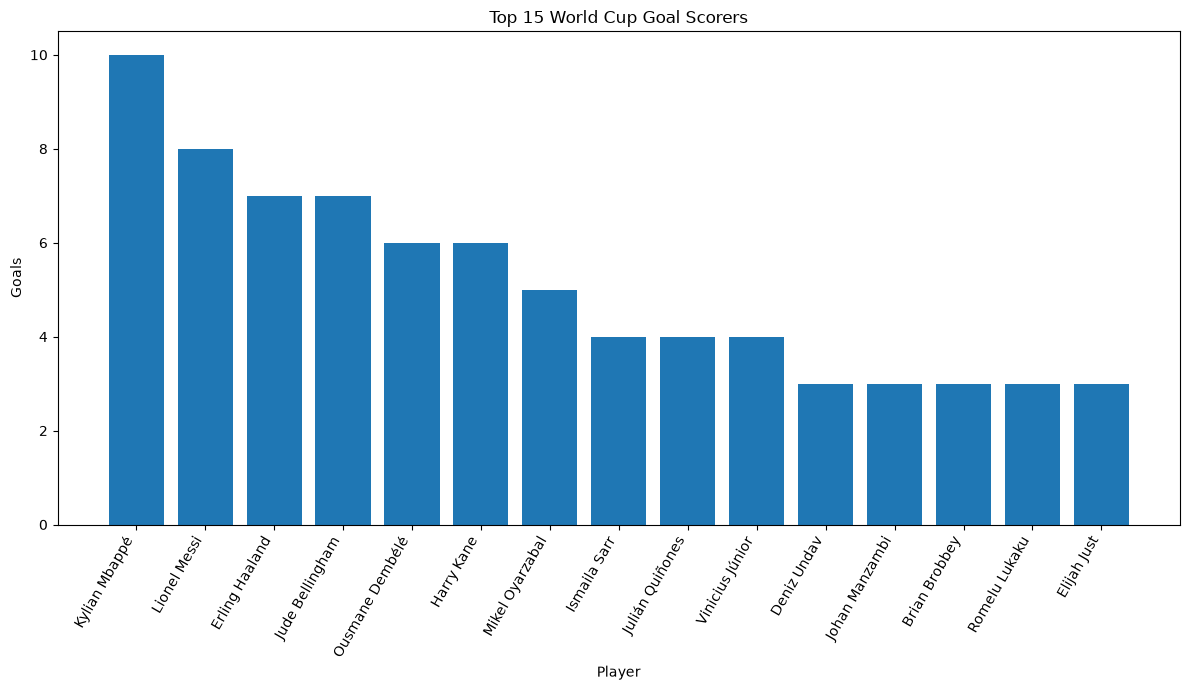

In [41]:
# ==========================================================
# CELL 86 — TOP GOAL SCORERS VISUALIZATION
# ==========================================================

plt.figure(figsize=(12, 7))

plt.bar(
    top_scorers["player"],
    top_scorers["goals"]
)

plt.title("Top 15 World Cup Goal Scorers")
plt.xlabel("Player")
plt.ylabel("Goals")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [43]:
# ==========================================================
# CELL 87 — TOP ASSIST PROVIDERS — SAFE VERSION
# ==========================================================

top_assisters = (
    players[
        [
            "player",
            "team",
            "position",
            "games",
            "minutes",
            "assists",
            "assists_per90"
        ]
    ]
    .dropna(subset=["assists"])
    .sort_values(
        ["assists", "assists_per90"],
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(top_assisters)

,player,team,position,games,minutes,assists,assists_per90
0,Michael Olise,France,MF,8,646.0,7.0,0.98
1,Bruno Guimarães,Brazil,MF,5,416.0,4.0,0.87
2,Brahim Díaz,Morocco,MF,6,457.0,4.0,0.79
3,Martin Ødegaard,Norway,MF,5,470.0,4.0,0.77
4,Kylian Mbappé,France,FW,8,695.0,4.0,0.52
5,Lionel Messi,Argentina,FW,8,740.0,4.0,0.49
6,Andreas Schjelderup,Norway,FW,6,252.0,3.0,1.07
7,Alexander Isak,Sweden,FW,4,357.0,3.0,0.76
8,Bukayo Saka,England,MF,7,358.0,3.0,0.75
9,Florian Wirtz,Germany,MF,4,361.0,3.0,0.75


In [44]:
# ==========================================================
# CELL 88 — SHOOTING PERFORMANCE
# ==========================================================

shooting_players = (
    players[
        [
            "player",
            "team",
            "position",
            "minutes",
            "shots",
            "shots_on_target",
            "shots_on_target_pct",
            "goals",
            "goals_per_shot"
        ]
    ]
    .dropna(subset=["shots"])
    .sort_values(
        "shots",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(shooting_players)

,player,team,position,minutes,shots,shots_on_target,shots_on_target_pct,goals,goals_per_shot
0,Kylian Mbappé,France,FW,695.0,41.0,23.0,56.1,10.0,0.22
1,Lionel Messi,Argentina,FW,740.0,35.0,18.0,51.4,8.0,0.23
2,Lamine Yamal,Spain,"MF,FW",614.0,27.0,12.0,44.4,1.0,0.04
3,Mikel Oyarzabal,Spain,FW,601.0,23.0,12.0,52.2,5.0,0.17
4,Harry Kane,England,FW,652.0,23.0,12.0,52.2,6.0,0.17
5,Kevin De Bruyne,Belgium,MF,382.0,20.0,5.0,25.0,1.0,0.05
6,Ousmane Dembélé,France,MF,592.0,20.0,10.0,50.0,6.0,0.30
7,Michael Olise,France,MF,646.0,20.0,5.0,25.0,0.0,0.00
8,Erling Haaland,Norway,FW,465.0,20.0,13.0,65.0,7.0,0.35
9,Jude Bellingham,England,MF,614.0,19.0,13.0,68.4,7.0,0.37


In [45]:
# ==========================================================
# CELL 89 — PLAYER SHOT EFFICIENCY
# ==========================================================

player_shot_efficiency = players[
    [
        "player",
        "team",
        "position",
        "minutes",
        "shots",
        "goals",
        "goals_per_shot"
    ]
].copy()

player_shot_efficiency = (
    player_shot_efficiency
    .dropna(subset=["goals_per_shot"])
)

# Remove players with extremely small sample sizes
player_shot_efficiency = player_shot_efficiency[
    player_shot_efficiency["shots"] >= 3
]

player_shot_efficiency = (
    player_shot_efficiency
    .sort_values(
        "goals_per_shot",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(player_shot_efficiency)

,player,team,position,minutes,shots,goals,goals_per_shot
0,Brian Brobbey,Netherlands,FW,223.0,4.0,3.0,0.75
1,Anthony Elanga,Sweden,"MF,FW",217.0,3.0,2.0,0.67
2,Daichi Kamada,Japan,MF,329.0,3.0,2.0,0.67
3,Daniel Muñoz,Colombia,DF,394.0,3.0,2.0,0.67
4,Johan Manzambi,Switzerland,"MF,FW",199.0,6.0,3.0,0.50
5,Ramin Rezaeian,IR Iran,"DF,MF",270.0,4.0,2.0,0.50
6,Habib Diarra,Senegal,MF,143.0,4.0,2.0,0.50
7,Ermin Mahmić,Bosnia–Herz,MF,68.0,4.0,2.0,0.50
8,Deniz Undav,Germany,FW,151.0,6.0,3.0,0.50
9,Maxi Araújo,Uruguay,"FW,MF",250.0,4.0,2.0,0.50


In [46]:
# ==========================================================
# CELL 90 — PLAYER GOAL CONTRIBUTION
# ==========================================================

player_contribution = players[
    [
        "player",
        "team",
        "position",
        "minutes",
        "goals",
        "assists",
        "goals_assists",
        "goals_per90",
        "assists_per90",
        "goals_assists_per90"
    ]
].copy()

player_contribution = (
    player_contribution
    .dropna(subset=["minutes", "goals_assists"])
)

# Minimum playing time to avoid tiny-sample rankings
player_contribution = player_contribution[
    player_contribution["minutes"] >= 180
]

player_contribution = (
    player_contribution
    .sort_values(
        "goals_assists_per90",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

display(player_contribution)

,player,team,position,minutes,goals,assists,goals_assists,goals_per90,assists_per90,goals_assists_per90
0,Johan Manzambi,Switzerland,"MF,FW",199.0,3.0,2.0,5.0,1.36,0.90,2.26
1,Kylian Mbappé,France,FW,695.0,10.0,4.0,14.0,1.29,0.52,1.81
2,Romelu Lukaku,Belgium,FW,233.0,3.0,1.0,4.0,1.16,0.39,1.55
3,Bukayo Saka,England,MF,358.0,3.0,3.0,6.0,0.75,0.75,1.51
4,Nathan Saliba,Canada,MF,182.0,1.0,2.0,3.0,0.49,0.99,1.48
5,Lionel Messi,Argentina,FW,740.0,8.0,4.0,12.0,0.97,0.49,1.46
6,Andreas Schjelderup,Norway,FW,252.0,1.0,3.0,4.0,0.36,1.07,1.43
7,Crysencio Summerville,Netherlands,FW,253.0,2.0,2.0,4.0,0.71,0.71,1.42
8,Erling Haaland,Norway,FW,465.0,7.0,0.0,7.0,1.35,0.00,1.35
9,Ismaila Sarr,Senegal,"MF,FW",364.0,4.0,1.0,5.0,0.99,0.25,1.24


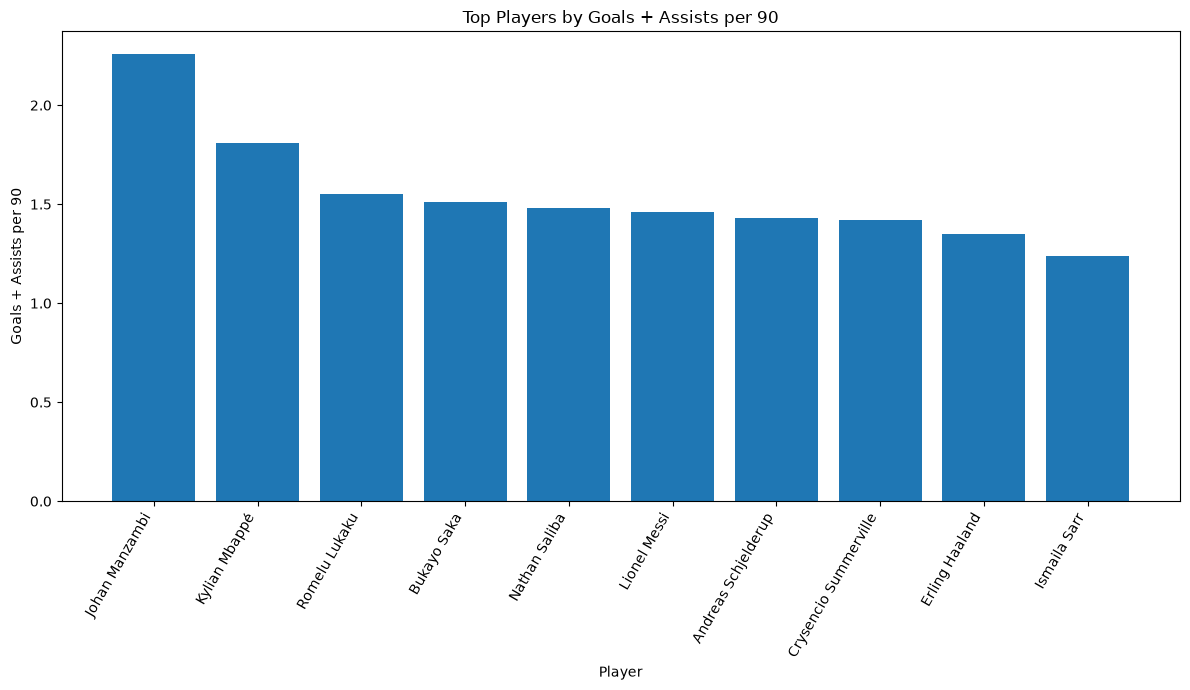

In [47]:
# ==========================================================
# CELL 91 — PLAYER GOAL CONTRIBUTION VISUALIZATION
# ==========================================================

top_contributors = player_contribution.head(10)

plt.figure(figsize=(12, 7))

plt.bar(
    top_contributors["player"],
    top_contributors["goals_assists_per90"]
)

plt.title("Top Players by Goals + Assists per 90")
plt.xlabel("Player")
plt.ylabel("Goals + Assists per 90")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [48]:
# ==========================================================
# CELL 92 — MATCH DATASET OVERVIEW
# ==========================================================

match_overview = matches[
    [
        "round",
        "date",
        "home_team",
        "away_team",
        "score",
        "home_score",
        "away_score",
        "venue",
        "referee"
    ]
].copy()

display(match_overview.head(20))

,round,date,home_team,away_team,score,home_score,away_score,venue,referee
0,Group stage,2026-06-11,Mexico,South Africa,2–0,2.0,0.0,"Estadio Banorte, Coyoacán",Wilton Sampaio
1,Group stage,2026-06-11,Korea Republic,Czechia,2–1,2.0,1.0,"Estadio Akron, Zapopan",Amin Omar
2,Group stage,2026-06-12,Canada,Bosnia–Herz,1–1,1.0,1.0,"BMO Field, Toronto",Facundo Tello
3,Group stage,2026-06-12,United States,Paraguay,4–1,4.0,1.0,"SoFi Stadium, Inglewood",Danny Makkelie
4,Group stage,2026-06-13,Qatar,Switzerland,1–1,1.0,1.0,"Levi's Stadium, Santa Clara",Said Martínez
5,Group stage,2026-06-13,Brazil,Morocco,1–1,1.0,1.0,"MetLife Stadium, East Rutherford",Slavko Vinčič
6,Group stage,2026-06-13,Australia,Türkiye,2–0,2.0,0.0,"BC Place Stadium, Vancouver",Jesús Valenzuela
7,Group stage,2026-06-13,Haiti,Scotland,0–1,0.0,1.0,"Gillette Stadium, Foxborough",Mustapha Ghorbal
8,Group stage,2026-06-14,Germany,Curaçao,7–1,7.0,1.0,"Reliant Stadium, Houston",Jalal Jiyed
9,Group stage,2026-06-14,Netherlands,Japan,2–2,2.0,2.0,"AT&T Stadium, Arlington",Ismail Elfath


In [49]:
# ==========================================================
# CELL 93 — HIGHEST-SCORING MATCHES
# ==========================================================

matches["total_goals"] = (
    matches["home_score"].fillna(0) +
    matches["away_score"].fillna(0)
)

highest_scoring_matches = (
    matches[
        [
            "round",
            "home_team",
            "away_team",
            "home_score",
            "away_score",
            "total_goals"
        ]
    ]
    .sort_values(
        "total_goals",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(highest_scoring_matches)

,round,home_team,away_team,home_score,away_score,total_goals
0,Third-place match,France,England,4.0,6.0,10.0
1,Group stage,Germany,Curaçao,7.0,1.0,8.0
2,Group stage,Sweden,Tunisia,5.0,1.0,6.0
3,Group stage,Canada,Qatar,6.0,0.0,6.0
4,Group stage,Netherlands,Sweden,5.0,1.0,6.0
5,Group stage,New Zealand,Belgium,1.0,5.0,6.0
6,Group stage,Morocco,Haiti,4.0,2.0,6.0
7,Group stage,England,Croatia,4.0,2.0,6.0
8,Group stage,Algeria,Austria,3.0,3.0,6.0
9,Group stage,Portugal,Uzbekistan,5.0,0.0,5.0


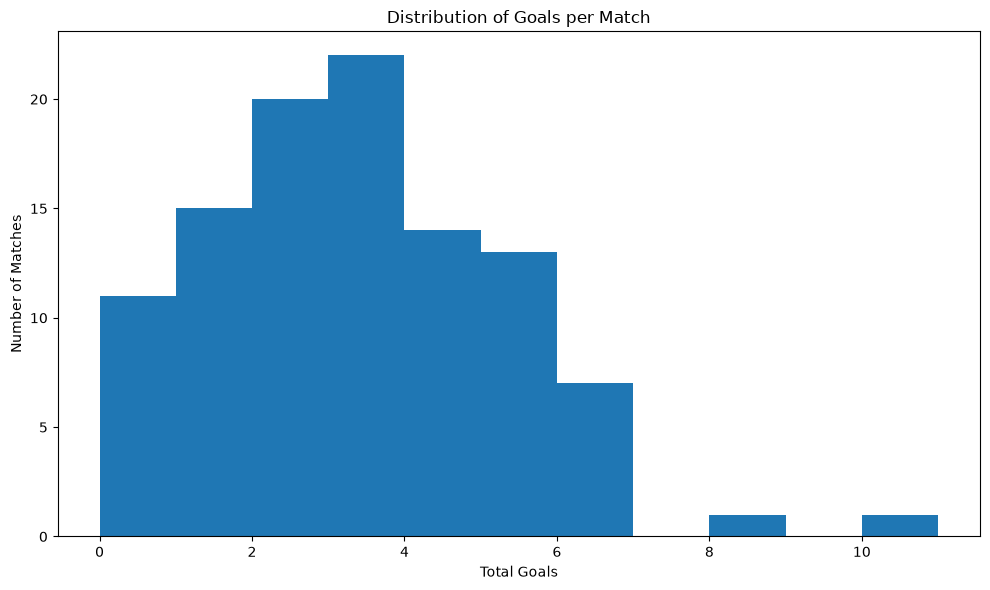

In [50]:
# ==========================================================
# CELL 94 — MATCH GOALS DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10, 6))

plt.hist(
    matches["total_goals"].dropna(),
    bins=range(
        int(matches["total_goals"].max()) + 2
    )
)

plt.title("Distribution of Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

In [51]:
# ==========================================================
# CELL 95 — HOME VS AWAY GOALS
# ==========================================================

home_goals = matches["home_score"].dropna()
away_goals = matches["away_score"].dropna()

home_average_goals = home_goals.mean()
away_average_goals = away_goals.mean()

home_away_summary = pd.DataFrame({
    "Team Type": ["Home", "Away"],
    "Average Goals": [
        home_average_goals,
        away_average_goals
    ],
    "Total Goals": [
        home_goals.sum(),
        away_goals.sum()
    ]
})

display(home_away_summary)

,Team Type,Average Goals,Total Goals
0,Home,1.692308,176.0
1,Away,1.211538,126.0


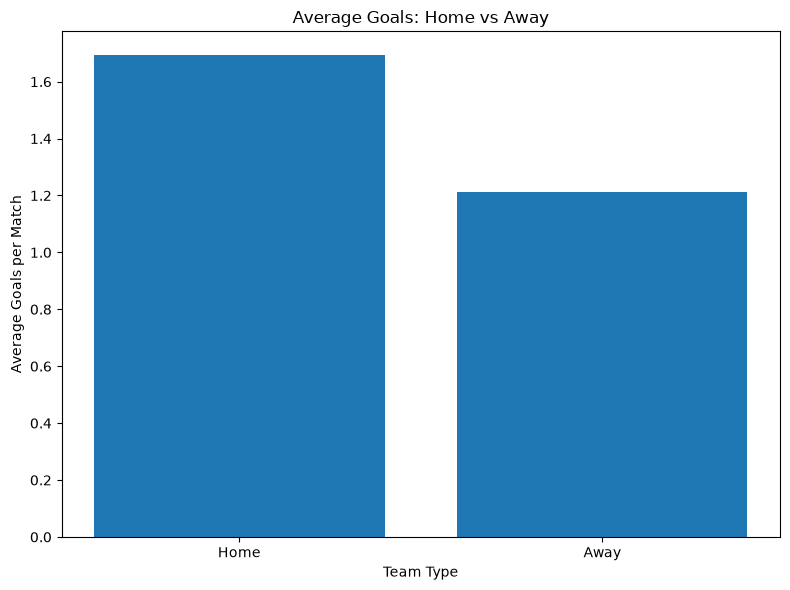

In [52]:
# ==========================================================
# CELL 96 — HOME VS AWAY GOALS VISUALIZATION
# ==========================================================

plt.figure(figsize=(8, 6))

plt.bar(
    home_away_summary["Team Type"],
    home_away_summary["Average Goals"]
)

plt.title("Average Goals: Home vs Away")
plt.xlabel("Team Type")
plt.ylabel("Average Goals per Match")

plt.tight_layout()
plt.show()

In [53]:
# ==========================================================
# CELL 97 — MATCH ATTACKING STATISTICS
# ==========================================================

match_attacking_summary = pd.DataFrame({
    "Metric": [
        "Average Home Possession",
        "Average Away Possession",
        "Average Home Shots",
        "Average Away Shots",
        "Average Home Shots on Target",
        "Average Away Shots on Target"
    ],
    "Value": [
        matches["home_possession"].mean(),
        matches["away_possession"].mean(),
        matches["home_total_shots"].mean(),
        matches["away_total_shots"].mean(),
        matches["home_sot"].mean(),
        matches["away_sot"].mean()
    ]
})

display(match_attacking_summary)

,Metric,Value
0,Average Home Possession,52.423077
1,Average Away Possession,47.701923
2,Average Home Shots,14.019231
3,Average Away Shots,10.769231
4,Average Home Shots on Target,4.846154
5,Average Away Shots on Target,3.673077


In [54]:
# ==========================================================
# CELL 98 — POSSESSION VS MATCH GOALS
# ==========================================================

home_match_analysis = matches[
    [
        "home_team",
        "home_possession",
        "home_total_shots",
        "home_sot",
        "home_score"
    ]
].copy()

home_match_analysis.columns = [
    "team",
    "possession",
    "shots",
    "shots_on_target",
    "goals"
]

away_match_analysis = matches[
    [
        "away_team",
        "away_possession",
        "away_total_shots",
        "away_sot",
        "away_score"
    ]
].copy()

away_match_analysis.columns = [
    "team",
    "possession",
    "shots",
    "shots_on_target",
    "goals"
]

match_team_analysis = pd.concat(
    [
        home_match_analysis,
        away_match_analysis
    ],
    ignore_index=True
)

display(match_team_analysis.head(20))

,team,possession,shots,shots_on_target,goals
0,Mexico,61,16,4,2.0
1,Korea Republic,62,15,6,2.0
2,Canada,61,13,4,1.0
3,United States,65,16,6,4.0
4,Qatar,32,7,4,1.0
5,Brazil,51,12,5,1.0
6,Australia,28,9,4,2.0
7,Haiti,54,15,2,0.0
8,Germany,65,26,12,7.0
9,Netherlands,60,10,6,2.0


In [55]:
# ==========================================================
# CELL 99 — MATCH-LEVEL CORRELATIONS
# ==========================================================

match_correlations = match_team_analysis[
    [
        "possession",
        "shots",
        "shots_on_target",
        "goals"
    ]
].corr()

display(match_correlations)

,possession,shots,shots_on_target,goals
possession,1.000000,0.627552,0.522315,0.326688
shots,0.627552,1.000000,0.778235,0.428634
shots_on_target,0.522315,0.778235,1.000000,0.622299
goals,0.326688,0.428634,0.622299,1.000000


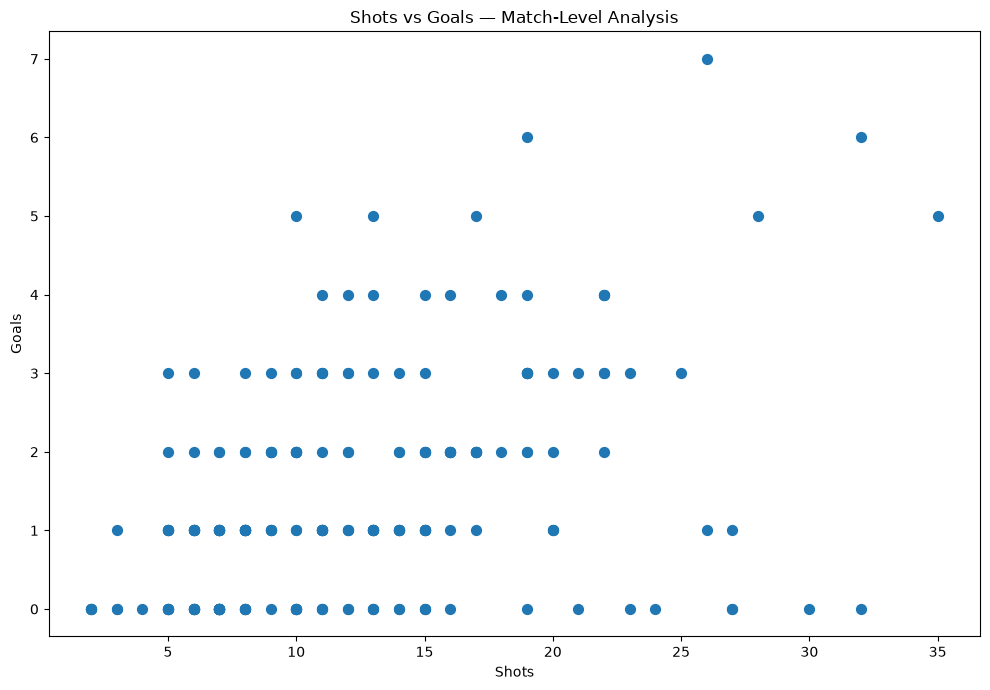

In [56]:
# ==========================================================
# CELL 100 — MATCH SHOTS VS GOALS
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    match_team_analysis["shots"],
    match_team_analysis["goals"],
    s=50
)

plt.xlabel("Shots")
plt.ylabel("Goals")
plt.title("Shots vs Goals — Match-Level Analysis")

plt.tight_layout()
plt.show()

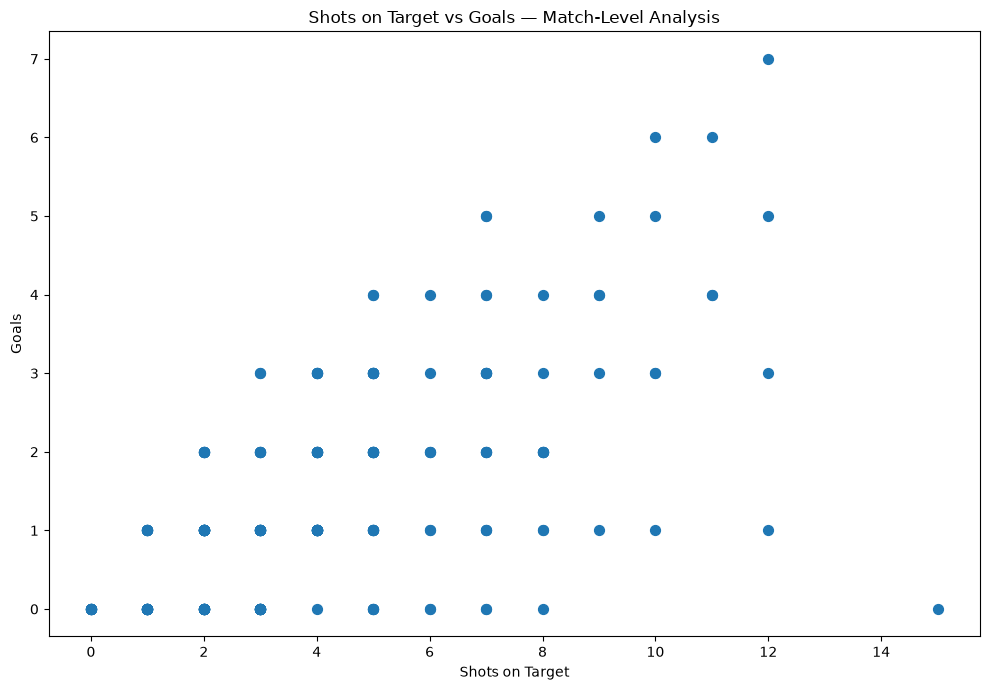

In [57]:
# ==========================================================
# CELL 101 — SHOTS ON TARGET VS GOALS
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    match_team_analysis["shots_on_target"],
    match_team_analysis["goals"],
    s=50
)

plt.xlabel("Shots on Target")
plt.ylabel("Goals")
plt.title("Shots on Target vs Goals — Match-Level Analysis")

plt.tight_layout()
plt.show()

In [58]:
# ==========================================================
# CELL 102 — OVERALL TEAM ANALYTICS TABLE
# ==========================================================

overall_team_analytics = teams[
    [
        "team",
        "team_country",
        "games",
        "goals",
        "goals_against",
        "assists",
        "possession",
        "shots",
        "shots_on_target",
        "interceptions",
        "tackles_won",
        "gk_saves",
        "gk_save_pct",
        "gk_clean_sheets",
        "points_per_game"
    ]
].copy()

# Make sure goal difference exists
if "goal_difference" not in overall_team_analytics.columns:
    overall_team_analytics["goal_difference"] = (
        overall_team_analytics["goals"]
        - overall_team_analytics["goals_against"]
    )

display(overall_team_analytics)

,team,team_country,games,goals,goals_against,assists,possession,shots,shots_on_target,interceptions,tackles_won,gk_saves,gk_save_pct,gk_clean_sheets,points_per_game,goal_difference
0,Algeria,Algeria,4,5,9,3,61.0,44,15,30,44,8,47.1,0,1.00,-4
1,Argentina,Argentina,8,18,8,12,57.6,114,44,82,93,20,71.4,2,2.63,10
2,Australia,Australia,4,2,2,1,41.0,42,12,29,34,14,82.4,2,1.25,0
3,Austria,Austria,4,5,9,4,45.0,32,8,41,29,13,59.1,0,1.00,-4
4,Belgium,Belgium,6,13,7,10,51.2,112,34,50,47,16,69.6,1,1.83,6
5,Bosnia–Herz,Bosnia and Herzegovina,4,4,8,3,46.0,37,14,34,37,6,42.9,0,1.00,-4
6,Brazil,Brazil,5,10,4,8,53.0,74,30,48,46,14,77.8,2,2.00,6
7,Cabo Verde,Cape Verde,4,4,4,2,37.3,49,12,52,45,18,78.3,2,0.75,0
8,Canada,Canada,5,8,6,3,54.4,80,31,36,51,6,50.0,2,1.40,2
9,Colombia,Colombia,5,5,1,5,57.8,94,30,38,33,6,85.7,4,2.20,4


In [59]:
# ==========================================================
# CELL 103 — OVERALL TEAM PERFORMANCE SCORE
# ==========================================================

score_data = teams[
    [
        "team",
        "goals",
        "goals_against",
        "goal_difference",
        "shots_on_target",
        "possession",
        "gk_clean_sheets",
        "points_per_game"
    ]
].copy()

# Helper function for min-max normalization
def min_max(series):
    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(0.5, index=series.index)

    return (
        (series - min_value) /
        (max_value - min_value)
    )

# Positive metrics
score_data["attack_score"] = min_max(
    score_data["goals"]
)

score_data["shot_quality_score"] = min_max(
    score_data["shots_on_target"]
)

score_data["possession_score"] = min_max(
    score_data["possession"]
)

score_data["clean_sheet_score"] = min_max(
    score_data["gk_clean_sheets"]
)

score_data["points_score"] = min_max(
    score_data["points_per_game"]
)

# Defensive metric:
# Fewer goals conceded = better
score_data["defensive_score"] = (
    1 -
    min_max(teams["goals_against"])
)

# Final weighted score
score_data["overall_performance_score"] = (
    score_data["attack_score"] * 0.25 +
    score_data["shot_quality_score"] * 0.15 +
    score_data["possession_score"] * 0.10 +
    score_data["clean_sheet_score"] * 0.15 +
    score_data["points_score"] * 0.20 +
    score_data["defensive_score"] * 0.15
)

overall_ranking = (
    score_data
    .sort_values(
        "overall_performance_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    overall_ranking[
        [
            "team",
            "goals",
            "goals_against",
            "goal_difference",
            "points_per_game",
            "overall_performance_score"
        ]
    ]
)

,team,goals,goals_against,goal_difference,points_per_game,overall_performance_score
0,Spain,13,1,12,2.75,0.893281
1,France,20,10,10,2.25,0.747973
2,Argentina,18,8,10,2.63,0.700235
3,England,20,12,8,2.38,0.666550
4,Mexico,10,3,7,2.40,0.619144
5,Colombia,5,1,4,2.20,0.608483
6,Brazil,10,4,6,2.00,0.559448
7,Morocco,10,5,5,1.83,0.539450
8,Belgium,13,7,6,1.83,0.527814
9,Germany,11,5,6,1.75,0.525067


In [60]:
# ==========================================================
# CELL 104 — TOP 10 OVERALL TEAM PERFORMANCE
# ==========================================================

top_10_overall = overall_ranking.head(10)

display(
    top_10_overall[
        [
            "team",
            "goals",
            "goals_against",
            "goal_difference",
            "points_per_game",
            "overall_performance_score"
        ]
    ]
)

,team,goals,goals_against,goal_difference,points_per_game,overall_performance_score
0,Spain,13,1,12,2.75,0.893281
1,France,20,10,10,2.25,0.747973
2,Argentina,18,8,10,2.63,0.700235
3,England,20,12,8,2.38,0.666550
4,Mexico,10,3,7,2.40,0.619144
5,Colombia,5,1,4,2.20,0.608483
6,Brazil,10,4,6,2.00,0.559448
7,Morocco,10,5,5,1.83,0.539450
8,Belgium,13,7,6,1.83,0.527814
9,Germany,11,5,6,1.75,0.525067


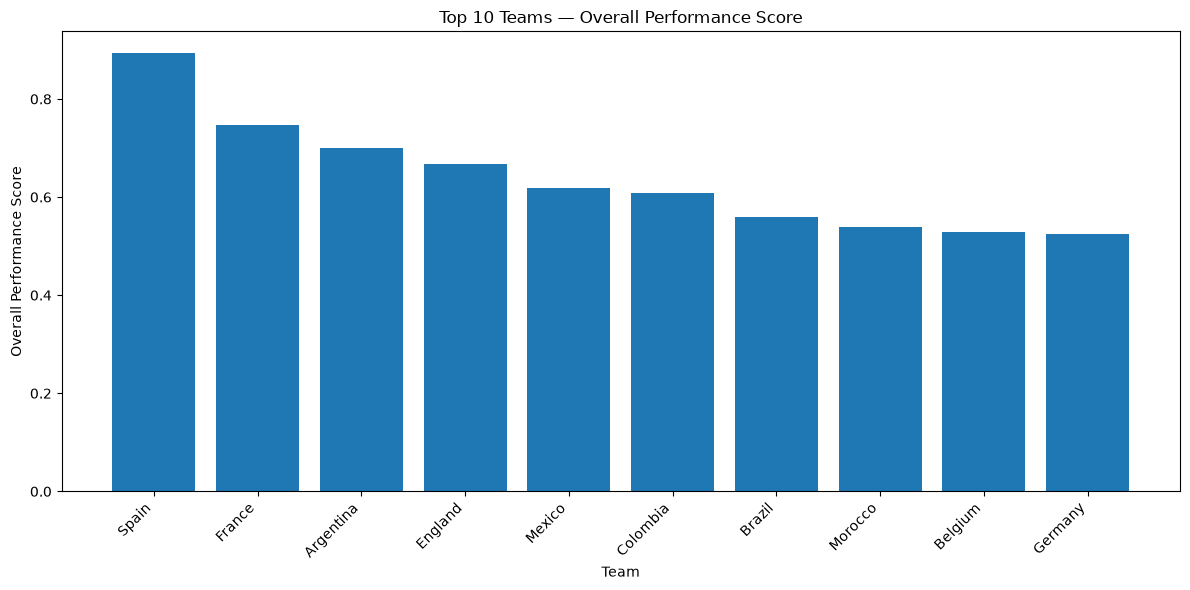

In [61]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_overall["team"],
    top_10_overall["overall_performance_score"]
)

plt.title("Top 10 Teams — Overall Performance Score")
plt.xlabel("Team")
plt.ylabel("Overall Performance Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [62]:
# ==========================================================
# CELL 105 — SAVE PART 3 ANALYSIS
# ==========================================================

import os

analysis_folder = "../data/processed/analysis"

os.makedirs(
    analysis_folder,
    exist_ok=True
)

# Team analysis
team_summary.to_csv(
    f"{analysis_folder}/team_summary.csv",
    index=False
)

top_goal_teams.to_csv(
    f"{analysis_folder}/top_goal_teams.csv",
    index=False
)

best_defenses.to_csv(
    f"{analysis_folder}/best_defensive_teams.csv",
    index=False
)

team_efficiency.to_csv(
    f"{analysis_folder}/team_efficiency.csv",
    index=False
)

defensive_stats.to_csv(
    f"{analysis_folder}/defensive_stats.csv",
    index=False
)

goalkeeper_summary.to_csv(
    f"{analysis_folder}/goalkeeper_summary.csv",
    index=False
)

# Player analysis
top_scorers.to_csv(
    f"{analysis_folder}/top_scorers.csv",
    index=False
)

top_assisters.to_csv(
    f"{analysis_folder}/top_assisters.csv",
    index=False
)

player_shot_efficiency.to_csv(
    f"{analysis_folder}/player_shot_efficiency.csv",
    index=False
)

player_contribution.to_csv(
    f"{analysis_folder}/player_contribution.csv",
    index=False
)

# Match analysis
highest_scoring_matches.to_csv(
    f"{analysis_folder}/highest_scoring_matches.csv",
    index=False
)

match_team_analysis.to_csv(
    f"{analysis_folder}/match_team_analysis.csv",
    index=False
)

match_correlations.to_csv(
    f"{analysis_folder}/match_correlations.csv"
)

# Overall ranking
overall_ranking.to_csv(
    f"{analysis_folder}/overall_team_ranking.csv",
    index=False
)

print("=" * 60)
print("PART 3 COMPLETED")
print("=" * 60)
print(f"Analysis files saved to: {analysis_folder}")
print()
print("Files created:")
print("1. team_summary.csv")
print("2. top_goal_teams.csv")
print("3. best_defensive_teams.csv")
print("4. team_efficiency.csv")
print("5. defensive_stats.csv")
print("6. goalkeeper_summary.csv")
print("7. top_scorers.csv")
print("8. top_assisters.csv")
print("9. player_shot_efficiency.csv")
print("10. player_contribution.csv")
print("11. highest_scoring_matches.csv")
print("12. match_team_analysis.csv")
print("13. match_correlations.csv")
print("14. overall_team_ranking.csv")

PART 3 COMPLETED
Analysis files saved to: ../data/processed/analysis

Files created:
1. team_summary.csv
2. top_goal_teams.csv
3. best_defensive_teams.csv
4. team_efficiency.csv
5. defensive_stats.csv
6. goalkeeper_summary.csv
7. top_scorers.csv
8. top_assisters.csv
9. player_shot_efficiency.csv
10. player_contribution.csv
11. highest_scoring_matches.csv
12. match_team_analysis.csv
13. match_correlations.csv
14. overall_team_ranking.csv


In [63]:
# ==========================================================
# PART 4 — ADVANCED FOOTBALL ANALYTICS
# CELL 106 — INITIALIZE PLAYER ANALYTICS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Players:", players.shape)
print("Teams:", teams.shape)
print("Matches:", matches.shape)

print("\nPlayer columns:")
print(players.columns.tolist())

Players: (1248, 70)
Teams: (48, 133)
Matches: (104, 43)

Player columns:
['player', 'team', 'team_country', 'position', 'age', 'birth_year', 'club', 'games', 'games_starts', 'minutes', 'minutes_90s', 'goals', 'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att', 'cards_yellow', 'cards_red', 'goals_per90', 'assists_per90', 'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90', 'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target', 'minutes_per_game', 'minutes_pct', 'minutes_per_start', 'games_complete', 'games_subs', 'minutes_per_sub', 'unused_subs', 'points_per_game', 'on_goals_for', 'on_goals_against', 'plus_minus', 'plus_minus_per90', 'plus_minus_wowy', 'cards_yellow_red', 'fouls', 'fouled', 'offsides', 'crosses', 'interceptions', 'tackles_won', 'own_goals', 'gk_games', 'gk_games_starts', 'gk_minutes', 'gk_goals_against', 'gk_goals_against_per90', 'gk_shots_on_target_against

In [64]:
# ==========================================================
# CELL 107 — PLAYER ANALYTICS DATASET
# ==========================================================

player_analytics = players.copy()

# Ensure numeric columns are numeric
numeric_columns = [
    "age",
    "games",
    "games_starts",
    "minutes",
    "minutes_90s",
    "goals",
    "assists",
    "goals_assists",
    "shots",
    "shots_on_target",
    "shots_on_target_pct",
    "interceptions",
    "tackles_won",
    "fouls",
    "fouled",
    "offsides",
    "crosses",
    "cards_yellow",
    "cards_red"
]

for col in numeric_columns:
    if col in player_analytics.columns:
        player_analytics[col] = pd.to_numeric(
            player_analytics[col],
            errors="coerce"
        )

print("Player analytics dataset created:")
print(player_analytics.shape)

display(player_analytics.head())

Player analytics dataset created:
(1248, 70)


,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,own_goals,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,Unknown Club,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0,0,0.0,4,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,Unknown Club,2,0,19.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,10.0,5.3,0.0,0,2,10.0,2,0.0,0.0,0.0,0.0,0.00,1.06,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.0,2.8,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.36,0.0,0.36,0.36,0.36,3.0,2.0,66.7,1.08,0.72,0.33,0.5,63.0,69.7,73.0,0,1,33.0,0,1.0,4.0,5.0,-1.0,-0.36,2.12,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,2.0,0.0,0.0,1.84,0.00,0.00,0.0,33.0,27.2,63.0,0,2,18.0,1,1.0,1.0,2.0,-1.0,-0.92,0.11,0.0,0.0,2.0,0.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,0.00,0.00,0.0,90.0,100.0,90.0,4,0,0.0,0,1.0,5.0,9.0,-4.0,-1.00,0.00,0.0,0.0,5.0,0.0,0.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# ==========================================================
# CELL 108 — MINIMUM PLAYING TIME FILTER
# ==========================================================

player_analytics["minutes"] = player_analytics["minutes"].fillna(0)

# Players with at least 180 minutes
players_180 = player_analytics[
    player_analytics["minutes"] >= 180
].copy()

# Players with at least 360 minutes
players_360 = player_analytics[
    player_analytics["minutes"] >= 360
].copy()

print("Total players:", len(player_analytics))
print("Players with 180+ minutes:", len(players_180))
print("Players with 360+ minutes:", len(players_360))

Total players: 1248
Players with 180+ minutes: 532
Players with 360+ minutes: 186


In [66]:
# ==========================================================
# CELL 109 — PER 90 METRICS
# ==========================================================

def per90(stat, minutes):
    return np.where(
        minutes > 0,
        stat / minutes * 90,
        0
    )

player_analytics["goals_per90_calc"] = per90(
    player_analytics["goals"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["assists_per90_calc"] = per90(
    player_analytics["assists"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["shots_per90_calc"] = per90(
    player_analytics["shots"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["shots_on_target_per90_calc"] = per90(
    player_analytics["shots_on_target"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["interceptions_per90_calc"] = per90(
    player_analytics["interceptions"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["tackles_won_per90_calc"] = per90(
    player_analytics["tackles_won"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["fouls_per90_calc"] = per90(
    player_analytics["fouls"].fillna(0),
    player_analytics["minutes"]
)

player_analytics["crosses_per90_calc"] = per90(
    player_analytics["crosses"].fillna(0),
    player_analytics["minutes"]
)

display(
    player_analytics[
        [
            "player",
            "team",
            "position",
            "minutes",
            "goals_per90_calc",
            "assists_per90_calc",
            "shots_per90_calc",
            "interceptions_per90_calc",
            "tackles_won_per90_calc"
        ]
    ].head(15)
)

,player,team,position,minutes,goals_per90_calc,assists_per90_calc,shots_per90_calc,interceptions_per90_calc,tackles_won_per90_calc
0,Achref Abada,Algeria,DF,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,Adil Boulbina,Algeria,FW,19.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,Amine Gouiri,Algeria,FW,251.0,0.358566,0.000000,1.075697,0.000000,0.358566
3,Anis Hadj Moussa,Algeria,MF,98.0,0.000000,0.000000,1.836735,0.918367,0.000000
4,Aïssa Mandi,Algeria,DF,360.0,0.000000,0.000000,0.000000,1.000000,0.750000
5,Fares Chaïbi,Algeria,MF,360.0,0.000000,0.000000,2.250000,0.750000,1.250000
6,Farés Ghedjemis,Algeria,"FW,MF",1.0,0.000000,0.000000,0.000000,0.000000,0.000000
7,Hicham Boudaoui,Algeria,MF,128.0,0.000000,0.000000,0.000000,1.406250,0.703125
8,Houssem Aouar,Algeria,MF,173.0,0.000000,1.040462,1.560694,0.000000,0.520231
9,Ibrahim Maza,Algeria,"MF,FW",351.0,0.000000,0.000000,2.820513,0.000000,0.512821


In [67]:
# ==========================================================
# CELL 110 — GOAL CONTRIBUTION PER 90
# ==========================================================

player_analytics["goal_contribution_per90"] = (
    player_analytics["goals_per90_calc"] +
    player_analytics["assists_per90_calc"]
)

goal_contribution = (
    player_analytics[
        player_analytics["minutes"] >= 180
    ][
        [
            "player",
            "team",
            "position",
            "minutes",
            "goals",
            "assists",
            "goal_contribution_per90"
        ]
    ]
    .sort_values(
        "goal_contribution_per90",
        ascending=False
    )
    .reset_index(drop=True)
)

display(goal_contribution.head(20))

,player,team,position,minutes,goals,assists,goal_contribution_per90
0,Johan Manzambi,Switzerland,"MF,FW",199.0,3.0,2.0,2.261307
1,Kylian Mbappé,France,FW,695.0,10.0,4.0,1.812950
2,Romelu Lukaku,Belgium,FW,233.0,3.0,1.0,1.545064
3,Bukayo Saka,England,MF,358.0,3.0,3.0,1.508380
4,Nathan Saliba,Canada,MF,182.0,1.0,2.0,1.483516
5,Lionel Messi,Argentina,FW,740.0,8.0,4.0,1.459459
6,Andreas Schjelderup,Norway,FW,252.0,1.0,3.0,1.428571
7,Crysencio Summerville,Netherlands,FW,253.0,2.0,2.0,1.422925
8,Erling Haaland,Norway,FW,465.0,7.0,0.0,1.354839
9,Ismaila Sarr,Senegal,"MF,FW",364.0,4.0,1.0,1.236264


In [68]:
# ==========================================================
# CELL 111 — POSITION DISTRIBUTION
# ==========================================================

position_counts = (
    player_analytics["position"]
    .value_counts()
    .reset_index()
)

position_counts.columns = [
    "position",
    "player_count"
]

display(position_counts)

,position,player_count
0,MF,378
1,DF,364
2,FW,169
3,GK,145
4,"FW,MF",90
5,"DF,MF",49
6,"MF,FW",36
7,"MF,DF",12
8,"DF,FW",5


In [69]:
# ==========================================================
# CELL 112 — PRIMARY POSITION GROUP
# ==========================================================

def get_primary_position(position):
    
    if pd.isna(position):
        return "Unknown"
    
    position = str(position)
    
    if "GK" in position:
        return "GK"
    
    if "DF" in position:
        return "DF"
    
    if "MF" in position:
        return "MF"
    
    if "FW" in position:
        return "FW"
    
    return "Other"


player_analytics["primary_position"] = (
    player_analytics["position"]
    .apply(get_primary_position)
)

print(
    player_analytics["primary_position"]
    .value_counts()
)

display(
    player_analytics[
        [
            "player",
            "position",
            "primary_position"
        ]
    ].head(20)
)

primary_position
MF    504
DF    430
FW    169
GK    145
Name: count, dtype: int64


,player,position,primary_position
0,Achref Abada,DF,DF
1,Adil Boulbina,FW,FW
2,Amine Gouiri,FW,FW
3,Anis Hadj Moussa,MF,MF
4,Aïssa Mandi,DF,DF
5,Fares Chaïbi,MF,MF
6,Farés Ghedjemis,"FW,MF",MF
7,Hicham Boudaoui,MF,MF
8,Houssem Aouar,MF,MF
9,Ibrahim Maza,"MF,FW",MF


In [70]:
# ==========================================================
# CELL 113 — POSITION PERFORMANCE SUMMARY
# ==========================================================

position_summary = (
    player_analytics[
        player_analytics["minutes"] >= 180
    ]
    .groupby("primary_position")
    .agg(
        players=("player", "count"),
        avg_age=("age", "mean"),
        avg_minutes=("minutes", "mean"),
        avg_goals=("goals", "mean"),
        avg_assists=("assists", "mean"),
        avg_shots=("shots", "mean"),
        avg_interceptions=("interceptions", "mean"),
        avg_tackles_won=("tackles_won", "mean")
    )
    .reset_index()
)

display(position_summary)

,primary_position,players,avg_age,avg_minutes,avg_goals,avg_assists,avg_shots,avg_interceptions,avg_tackles_won
0,DF,207,28.188406,331.280193,0.130435,0.183575,1.811594,3.652174,3.676329
1,FW,60,27.816667,315.250000,1.650000,0.633333,8.800000,0.933333,1.700000
2,GK,48,31.062500,376.729167,0.000000,0.000000,0.000000,0.041667,0.041667
3,MF,217,26.571429,316.414747,0.562212,0.511521,5.211982,2.806452,3.576037


In [71]:
# ==========================================================
# CELL 114 — POSITION GOAL CONTRIBUTION
# ==========================================================

position_goal_contribution = (
    player_analytics[
        player_analytics["minutes"] >= 180
    ]
    .groupby("primary_position")
    .agg(
        players=("player", "count"),
        total_goals=("goals", "sum"),
        total_assists=("assists", "sum"),
        avg_goals_per90=("goals_per90_calc", "mean"),
        avg_assists_per90=("assists_per90_calc", "mean"),
        avg_goal_contribution_per90=(
            "goal_contribution_per90",
            "mean"
        )
    )
    .reset_index()
)

display(position_goal_contribution)

,primary_position,players,total_goals,total_assists,avg_goals_per90,avg_assists_per90,avg_goal_contribution_per90
0,DF,207,27.0,38.0,0.035068,0.047026,0.082094
1,FW,60,99.0,38.0,0.392554,0.163568,0.556122
2,GK,48,0.0,0.0,0.000000,0.000000,0.000000
3,MF,217,122.0,111.0,0.158177,0.135356,0.293533


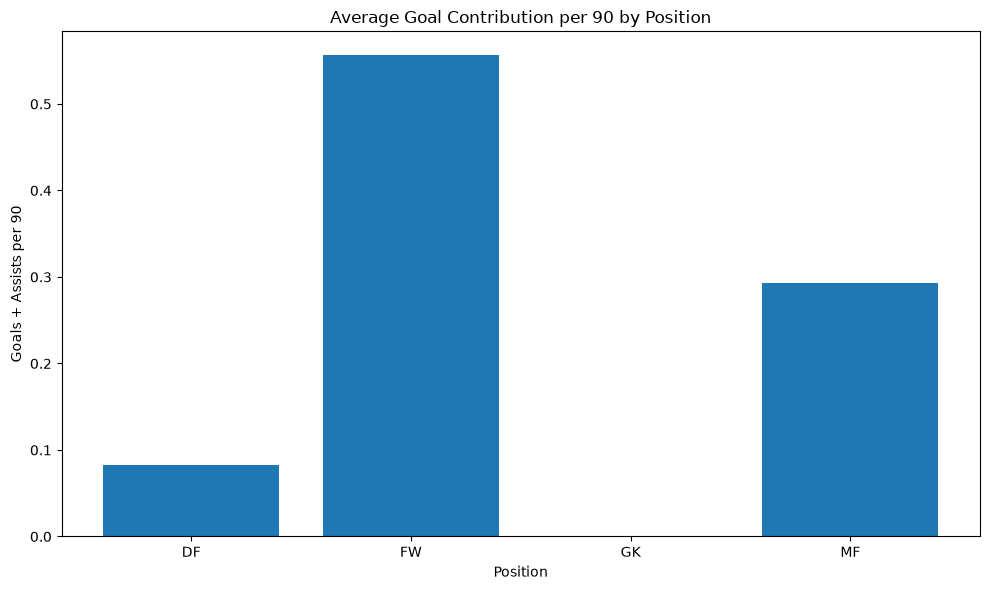

In [72]:
# ==========================================================
# CELL 115 — POSITION PERFORMANCE VISUALIZATION
# ==========================================================

plot_data = position_goal_contribution[
    position_goal_contribution["primary_position"].isin(
        ["GK", "DF", "MF", "FW"]
    )
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["primary_position"],
    plot_data["avg_goal_contribution_per90"]
)

plt.title(
    "Average Goal Contribution per 90 by Position"
)

plt.xlabel("Position")
plt.ylabel("Goals + Assists per 90")

plt.tight_layout()
plt.show()

In [73]:
# ==========================================================
# CELL 116 — POSITION-SPECIFIC PLAYER DATA
# ==========================================================

position_players = player_analytics[
    player_analytics["minutes"] >= 180
].copy()

print("Players included:", len(position_players))

display(
    position_players[
        [
            "player",
            "team",
            "position",
            "primary_position",
            "minutes",
            "goals",
            "assists",
            "shots",
            "interceptions",
            "tackles_won"
        ]
    ].head(20)
)

Players included: 532


,player,team,position,primary_position,minutes,goals,assists,shots,interceptions,tackles_won
2,Amine Gouiri,Algeria,FW,FW,251.0,1.0,0.0,3.0,0.0,1.0
4,Aïssa Mandi,Algeria,DF,DF,360.0,0.0,0.0,0.0,4.0,3.0
5,Fares Chaïbi,Algeria,MF,MF,360.0,0.0,0.0,9.0,3.0,5.0
9,Ibrahim Maza,Algeria,"MF,FW",MF,351.0,0.0,0.0,11.0,0.0,2.0
11,Luca Zidane,Algeria,GK,GK,270.0,0.0,0.0,0.0,0.0,0.0
15,Nabil Bentaleb,Algeria,MF,MF,285.0,0.0,0.0,1.0,3.0,4.0
18,Rafik Belghali,Algeria,DF,DF,331.0,1.0,0.0,3.0,1.0,3.0
20,Ramy Bensebaini,Algeria,DF,DF,360.0,0.0,0.0,2.0,7.0,6.0
21,Rayan Aït-Nouri,Algeria,DF,DF,284.0,0.0,0.0,1.0,5.0,13.0
22,Riyad Mahrez,Algeria,MF,MF,262.0,2.0,1.0,6.0,1.0,2.0


In [74]:
# ==========================================================
# CELL 117 — FORWARD PERFORMANCE
# ==========================================================

forwards = position_players[
    position_players["primary_position"] == "FW"
].copy()

forwards["attacking_output"] = (
    forwards["goals_per90_calc"] * 0.50 +
    forwards["assists_per90_calc"] * 0.25 +
    forwards["shots_on_target_per90_calc"] * 0.25
)

forward_ranking = forwards[
    [
        "player",
        "team",
        "minutes",
        "goals",
        "assists",
        "shots",
        "goals_per90_calc",
        "assists_per90_calc",
        "attacking_output"
    ]
].sort_values(
    "attacking_output",
    ascending=False
).reset_index(drop=True)

display(forward_ranking.head(15))

,player,team,minutes,goals,assists,shots,goals_per90_calc,assists_per90_calc,attacking_output
0,Kylian Mbappé,France,695.0,10.0,4.0,41.0,1.294964,0.517986,1.521583
1,Erling Haaland,Norway,465.0,7.0,0.0,20.0,1.354839,0.000000,1.306452
2,Lionel Messi,Argentina,740.0,8.0,4.0,35.0,0.972973,0.486486,1.155405
3,Vinicius Júnior,Brazil,440.0,4.0,1.0,17.0,0.818182,0.204545,1.022727
4,Romelu Lukaku,Belgium,233.0,3.0,1.0,6.0,1.158798,0.386266,0.965665
5,Cyle Larin,Canada,190.0,2.0,0.0,9.0,0.947368,0.000000,0.947368
6,Raúl Jiménez,Mexico,317.0,3.0,0.0,18.0,0.851735,0.000000,0.922713
7,Brian Brobbey,Netherlands,223.0,3.0,0.0,4.0,1.210762,0.000000,0.908072
8,Harry Kane,England,652.0,6.0,1.0,23.0,0.828221,0.138037,0.862730
9,Mikel Oyarzabal,Spain,601.0,5.0,1.0,23.0,0.748752,0.149750,0.861065


In [75]:
# ==========================================================
# CELL 118 — MIDFIELDER PERFORMANCE
# ==========================================================

midfielders = position_players[
    position_players["primary_position"] == "MF"
].copy()

midfielders["midfield_output"] = (
    midfielders["goals_per90_calc"] * 0.20 +
    midfielders["assists_per90_calc"] * 0.20 +
    midfielders["shots_per90_calc"] * 0.10 +
    midfielders["interceptions_per90_calc"] * 0.25 +
    midfielders["tackles_won_per90_calc"] * 0.25
)

midfielder_ranking = midfielders[
    [
        "player",
        "team",
        "minutes",
        "goals",
        "assists",
        "interceptions",
        "tackles_won",
        "midfield_output"
    ]
].sort_values(
    "midfield_output",
    ascending=False
).reset_index(drop=True)

display(midfielder_ranking.head(15))

,player,team,minutes,goals,assists,interceptions,tackles_won,midfield_output
0,Nathan Saliba,Canada,182.0,1.0,2.0,4.0,4.0,1.434066
1,Livano Comenencia,Curaçao,233.0,1.0,0.0,11.0,1.0,1.429185
2,Aurélien Tchouaméni,France,360.0,0.0,1.0,6.0,14.0,1.375000
3,Felix Nmecha,Germany,270.0,1.0,1.0,2.0,9.0,1.316667
4,Amad Diallo,Côte d'Ivoire,185.0,2.0,0.0,2.0,4.0,1.313514
5,Diego Gómez,Paraguay,304.0,0.0,0.0,9.0,6.0,1.287829
6,Mohanad Lasheen,Egypt,359.0,0.0,0.0,8.0,11.0,1.240947
7,Saeid Ezatolahi,IR Iran,264.0,0.0,0.0,7.0,5.0,1.227273
8,Matías Galarza,Paraguay,388.0,1.0,1.0,7.0,11.0,1.182990
9,Christ Inao Oulaï,Côte d'Ivoire,208.0,0.0,0.0,6.0,4.0,1.168269


In [76]:
# ==========================================================
# CELL 119 — DEFENDER PERFORMANCE
# ==========================================================

defenders = position_players[
    position_players["primary_position"] == "DF"
].copy()

defenders["defensive_output"] = (
    defenders["interceptions_per90_calc"] * 0.35 +
    defenders["tackles_won_per90_calc"] * 0.35 +
    defenders["goals_per90_calc"] * 0.10 +
    defenders["assists_per90_calc"] * 0.10 +
    defenders["shots_on_target_per90_calc"] * 0.10
)

defender_ranking = defenders[
    [
        "player",
        "team",
        "minutes",
        "interceptions",
        "tackles_won",
        "goals",
        "assists",
        "defensive_output"
    ]
].sort_values(
    "defensive_output",
    ascending=False
).reset_index(drop=True)

display(defender_ranking.head(15))

,player,team,minutes,interceptions,tackles_won,goals,assists,defensive_output
0,Marvin Senaya,Ghana,278.0,6.0,12.0,0.0,0.0,2.039568
1,Rayan Aït-Nouri,Algeria,284.0,5.0,13.0,0.0,0.0,1.996479
2,Merchas Doski,Iraq,270.0,6.0,9.0,0.0,0.0,1.750000
3,Khuliso Mudau,South Africa,360.0,11.0,8.0,0.0,0.0,1.662500
4,Mohamed Amine Ben Hamida,Tunisia,202.0,1.0,9.0,0.0,0.0,1.559406
5,Ali Abdi,Tunisia,269.0,4.0,8.0,0.0,0.0,1.405204
6,Yazan Al-Arab,Jordan,270.0,11.0,1.0,0.0,0.0,1.400000
7,Stefan Posch,Austria,331.0,10.0,4.0,0.0,0.0,1.332326
8,Dayot Upamecano,France,660.0,15.0,12.0,0.0,1.0,1.329545
9,Saud Abdulhamid,Saudi Arabia,269.0,2.0,9.0,0.0,0.0,1.288104


In [77]:
# ==========================================================
# CELL 120 — GOALKEEPER PERFORMANCE
# ==========================================================

goalkeepers = position_players[
    position_players["primary_position"] == "GK"
].copy()

goalkeepers["gk_save_pct_clean"] = (
    goalkeepers["gk_save_pct"].fillna(0)
)

goalkeepers["gk_clean_sheet_pct_clean"] = (
    goalkeepers["gk_clean_sheets_pct"].fillna(0)
)

goalkeepers["goalkeeper_output"] = (
    goalkeepers["gk_save_pct_clean"] * 0.60 +
    goalkeepers["gk_clean_sheet_pct_clean"] * 0.40
)

goalkeeper_ranking = goalkeepers[
    [
        "player",
        "team",
        "minutes",
        "gk_saves",
        "gk_save_pct",
        "gk_clean_sheets",
        "gk_clean_sheets_pct",
        "goalkeeper_output"
    ]
].sort_values(
    "goalkeeper_output",
    ascending=False
).reset_index(drop=True)

display(goalkeeper_ranking.head(15))

,player,team,minutes,gk_saves,gk_save_pct,gk_clean_sheets,gk_clean_sheets_pct,goalkeeper_output
0,Unai Simón,Spain,750.0,9.0,90.9,7.0,87.5,89.54
1,Benjamin Asare,Ghana,225.0,8.0,80.0,2.0,100.0,88.00
2,Camilo Vargas,Colombia,480.0,6.0,85.7,4.0,80.0,83.42
3,Raúl Rangel,Mexico,437.0,8.0,72.7,4.0,80.0,75.62
4,Patrick Beach,Australia,388.0,14.0,82.4,2.0,50.0,69.44
5,Diogo Costa,Portugal,450.0,19.0,86.4,2.0,40.0,67.84
6,Vozinha,Cabo Verde,390.0,18.0,78.3,2.0,50.0,66.98
7,Orlando Gill,Paraguay,480.0,23.0,79.3,2.0,40.0,63.58
8,Alireza Beiranvand,IR Iran,270.0,15.0,83.3,1.0,33.3,63.30
9,Alisson,Brazil,450.0,14.0,77.8,2.0,40.0,62.68


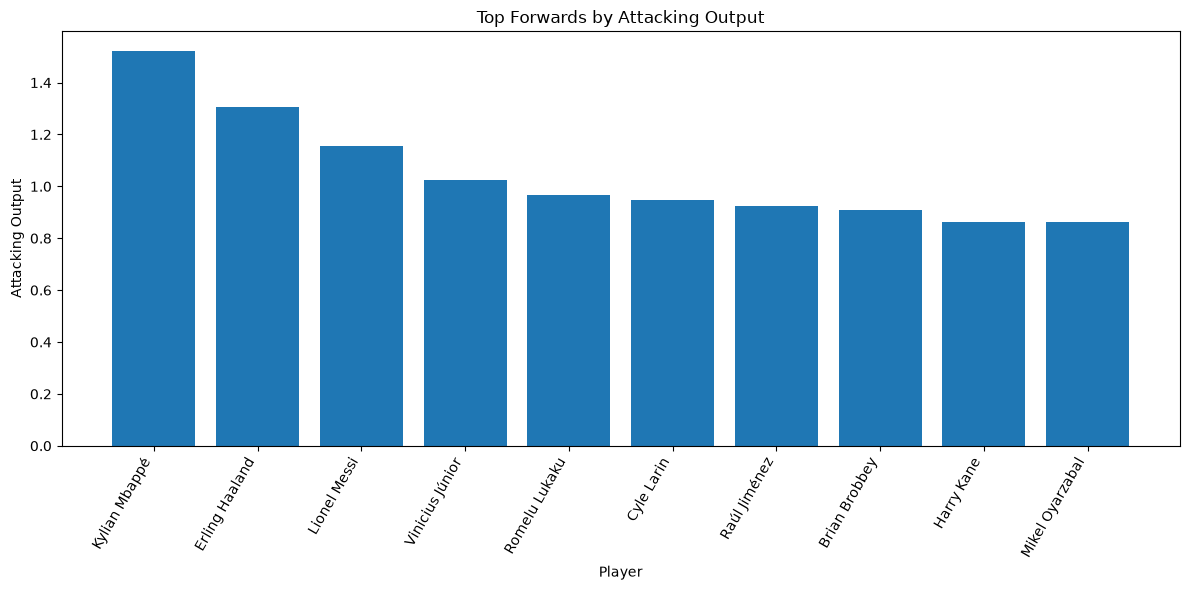

In [78]:
# ==========================================================
# CELL 121 — FORWARD VISUALIZATION
# ==========================================================

top_forwards = forward_ranking.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_forwards["player"],
    top_forwards["attacking_output"]
)

plt.title("Top Forwards by Attacking Output")
plt.xlabel("Player")
plt.ylabel("Attacking Output")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

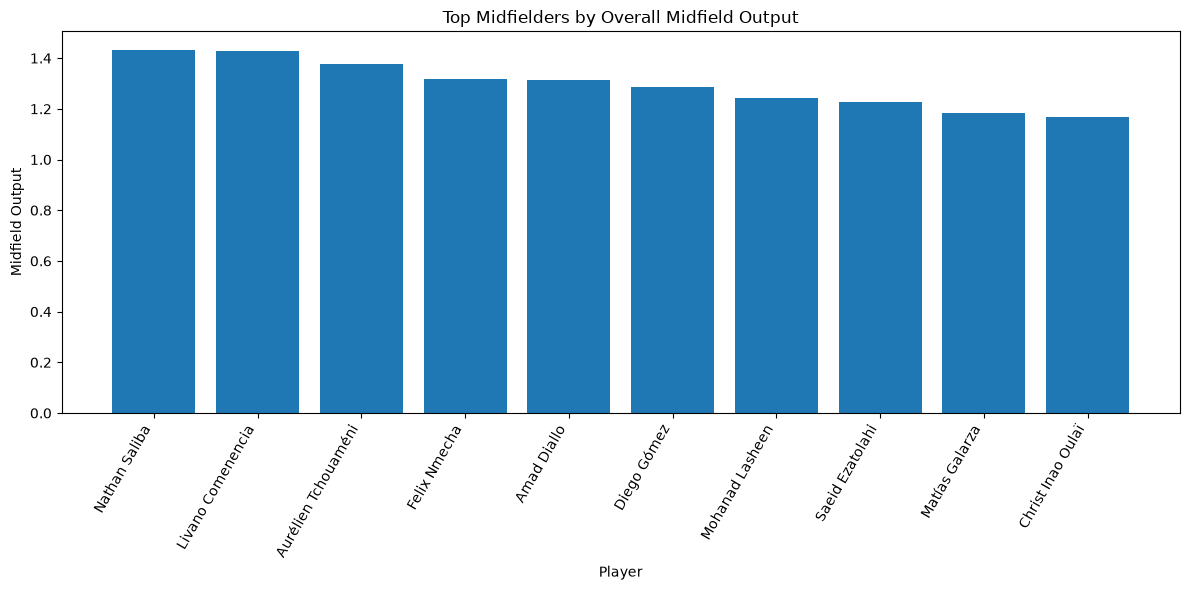

In [79]:
# ==========================================================
# CELL 122 — MIDFIELDER VISUALIZATION
# ==========================================================

top_midfielders = midfielder_ranking.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_midfielders["player"],
    top_midfielders["midfield_output"]
)

plt.title("Top Midfielders by Overall Midfield Output")
plt.xlabel("Player")
plt.ylabel("Midfield Output")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

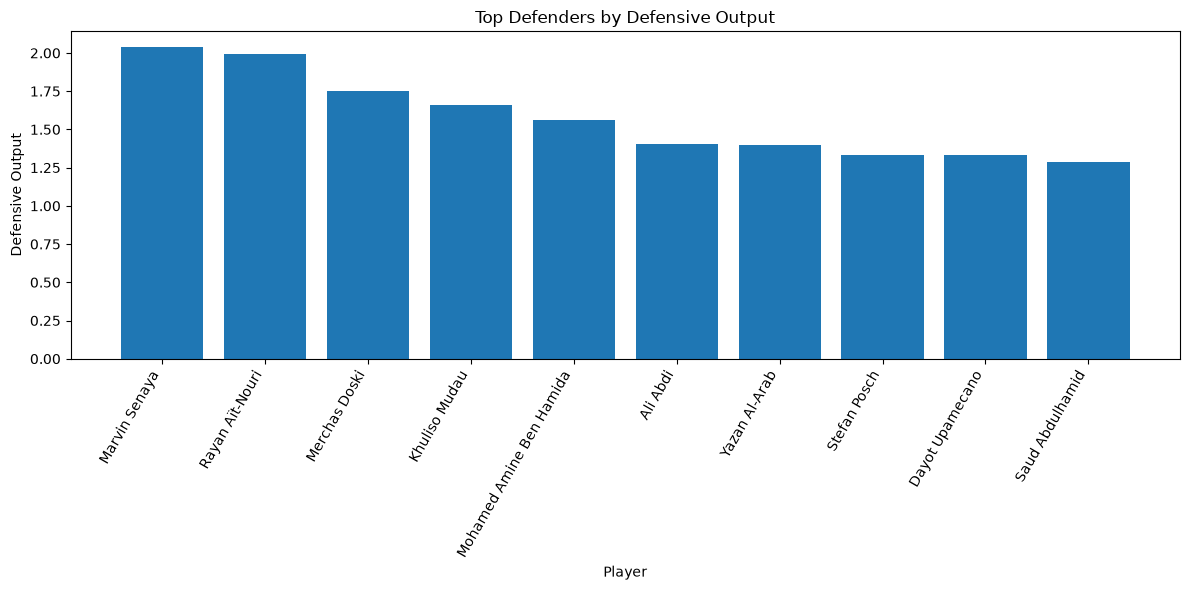

In [80]:
# ==========================================================
# CELL 123 — DEFENDER VISUALIZATION
# ==========================================================

top_defenders = defender_ranking.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_defenders["player"],
    top_defenders["defensive_output"]
)

plt.title("Top Defenders by Defensive Output")
plt.xlabel("Player")
plt.ylabel("Defensive Output")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

In [81]:
# ==========================================================
# CELL 124 — POSITION LEADERBOARD
# ==========================================================

forward_leaders = forward_ranking.head(5)[
    ["player", "team"]
].copy()

forward_leaders["position"] = "FW"
forward_leaders["metric"] = forward_ranking.head(5)[
    "attacking_output"
].values

midfielder_leaders = midfielder_ranking.head(5)[
    ["player", "team"]
].copy()

midfielder_leaders["position"] = "MF"
midfielder_leaders["metric"] = midfielder_ranking.head(5)[
    "midfield_output"
].values

defender_leaders = defender_ranking.head(5)[
    ["player", "team"]
].copy()

defender_leaders["position"] = "DF"
defender_leaders["metric"] = defender_ranking.head(5)[
    "defensive_output"
].values

goalkeeper_leaders = goalkeeper_ranking.head(5)[
    ["player", "team"]
].copy()

goalkeeper_leaders["position"] = "GK"
goalkeeper_leaders["metric"] = goalkeeper_ranking.head(5)[
    "goalkeeper_output"
].values

position_leaderboard = pd.concat(
    [
        forward_leaders,
        midfielder_leaders,
        defender_leaders,
        goalkeeper_leaders
    ],
    ignore_index=True
)

display(position_leaderboard)

,player,team,position,metric
0,Kylian Mbappé,France,FW,1.521583
1,Erling Haaland,Norway,FW,1.306452
2,Lionel Messi,Argentina,FW,1.155405
3,Vinicius Júnior,Brazil,FW,1.022727
4,Romelu Lukaku,Belgium,FW,0.965665
5,Nathan Saliba,Canada,MF,1.434066
6,Livano Comenencia,Curaçao,MF,1.429185
7,Aurélien Tchouaméni,France,MF,1.375000
8,Felix Nmecha,Germany,MF,1.316667
9,Amad Diallo,Côte d'Ivoire,MF,1.313514


In [82]:
# ==========================================================
# CELL 125 — SAVE POSITION ANALYSIS
# ==========================================================

import os

advanced_folder = "../data/processed/advanced_analytics"

os.makedirs(
    advanced_folder,
    exist_ok=True
)

forward_ranking.to_csv(
    f"{advanced_folder}/forward_ranking.csv",
    index=False
)

midfielder_ranking.to_csv(
    f"{advanced_folder}/midfielder_ranking.csv",
    index=False
)

defender_ranking.to_csv(
    f"{advanced_folder}/defender_ranking.csv",
    index=False
)

goalkeeper_ranking.to_csv(
    f"{advanced_folder}/goalkeeper_ranking.csv",
    index=False
)

position_leaderboard.to_csv(
    f"{advanced_folder}/position_leaderboard.csv",
    index=False
)

player_analytics.to_csv(
    f"{advanced_folder}/player_analytics.csv",
    index=False
)

print("=" * 60)
print("PART 4B COMPLETED")
print("=" * 60)

print(f"\nSaved to: {advanced_folder}")

print("\nFiles created:")
print("1. forward_ranking.csv")
print("2. midfielder_ranking.csv")
print("3. defender_ranking.csv")
print("4. goalkeeper_ranking.csv")
print("5. position_leaderboard.csv")
print("6. player_analytics.csv")

PART 4B COMPLETED

Saved to: ../data/processed/advanced_analytics

Files created:
1. forward_ranking.csv
2. midfielder_ranking.csv
3. defender_ranking.csv
4. goalkeeper_ranking.csv
5. position_leaderboard.csv
6. player_analytics.csv


In [83]:
# ==========================================================
# CELL 126 — PLAYER METRIC NORMALIZATION
# ==========================================================

rating_players = player_analytics[
    player_analytics["minutes"] >= 180
].copy()


def normalize_series(series):
    """
    Min-max normalization.
    Output range: 0 to 1.
    """
    
    series = pd.to_numeric(
        series,
        errors="coerce"
    ).fillna(0)

    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (
        (series - min_value) /
        (max_value - min_value)
    )


# Attacking metrics
rating_players["goal_score"] = normalize_series(
    rating_players["goals_per90_calc"]
)

rating_players["assist_score"] = normalize_series(
    rating_players["assists_per90_calc"]
)

rating_players["shot_score"] = normalize_series(
    rating_players["shots_on_target_per90_calc"]
)

# Defensive metrics
rating_players["interception_score"] = normalize_series(
    rating_players["interceptions_per90_calc"]
)

rating_players["tackle_score"] = normalize_series(
    rating_players["tackles_won_per90_calc"]
)

print("Normalized player metrics created.")

display(
    rating_players[
        [
            "player",
            "team",
            "primary_position",
            "goal_score",
            "assist_score",
            "shot_score",
            "interception_score",
            "tackle_score"
        ]
    ].head(15)
)

Normalized player metrics created.


,player,team,primary_position,goal_score,assist_score,shot_score,interception_score,tackle_score
2,Amine Gouiri,Algeria,FW,0.264276,0.000000,0.240776,0.000000,0.087036
4,Aïssa Mandi,Algeria,DF,0.000000,0.000000,0.000000,0.235354,0.182051
5,Fares Chaïbi,Algeria,MF,0.000000,0.000000,0.251812,0.176515,0.303419
9,Ibrahim Maza,Algeria,MF,0.000000,0.000000,0.258268,0.000000,0.124480
11,Luca Zidane,Algeria,GK,0.000000,0.000000,0.000000,0.000000,0.000000
15,Nabil Bentaleb,Algeria,MF,0.000000,0.000000,0.000000,0.222967,0.306613
18,Rafik Belghali,Algeria,DF,0.200403,0.000000,0.091291,0.063993,0.198001
20,Ramy Bensebaini,Algeria,DF,0.000000,0.000000,0.000000,0.411869,0.364103
21,Rayan Aït-Nouri,Algeria,DF,0.000000,0.000000,0.000000,0.372919,1.000000
22,Riyad Mahrez,Algeria,MF,0.506361,0.320611,0.346001,0.080847,0.166765


In [84]:
# ==========================================================
# CELL 127 — POSITION-SPECIFIC PLAYER RATING
# ==========================================================

rating_players["player_rating"] = np.nan


# ----------------------------------------------------------
# FORWARDS
# ----------------------------------------------------------

fw_mask = (
    rating_players["primary_position"] == "FW"
)

rating_players.loc[fw_mask, "player_rating"] = (
    rating_players.loc[fw_mask, "goal_score"] * 0.40 +
    rating_players.loc[fw_mask, "assist_score"] * 0.25 +
    rating_players.loc[fw_mask, "shot_score"] * 0.35
)


# ----------------------------------------------------------
# MIDFIELDERS
# ----------------------------------------------------------

mf_mask = (
    rating_players["primary_position"] == "MF"
)

rating_players.loc[mf_mask, "player_rating"] = (
    rating_players.loc[mf_mask, "goal_score"] * 0.20 +
    rating_players.loc[mf_mask, "assist_score"] * 0.20 +
    rating_players.loc[mf_mask, "shot_score"] * 0.10 +
    rating_players.loc[mf_mask, "interception_score"] * 0.25 +
    rating_players.loc[mf_mask, "tackle_score"] * 0.25
)


# ----------------------------------------------------------
# DEFENDERS
# ----------------------------------------------------------

df_mask = (
    rating_players["primary_position"] == "DF"
)

rating_players.loc[df_mask, "player_rating"] = (
    rating_players.loc[df_mask, "interception_score"] * 0.35 +
    rating_players.loc[df_mask, "tackle_score"] * 0.35 +
    rating_players.loc[df_mask, "goal_score"] * 0.10 +
    rating_players.loc[df_mask, "assist_score"] * 0.10 +
    rating_players.loc[df_mask, "shot_score"] * 0.10
)


# ----------------------------------------------------------
# GOALKEEPERS
# ----------------------------------------------------------

gk_mask = (
    rating_players["primary_position"] == "GK"
)

gk_save = normalize_series(
    rating_players["gk_save_pct"]
)

gk_clean_sheet = normalize_series(
    rating_players["gk_clean_sheets_pct"]
)

rating_players.loc[gk_mask, "player_rating"] = (
    gk_save.loc[gk_mask] * 0.60 +
    gk_clean_sheet.loc[gk_mask] * 0.40
)


display(
    rating_players[
        [
            "player",
            "team",
            "primary_position",
            "player_rating"
        ]
    ]
    .sort_values(
        "player_rating",
        ascending=False
    )
    .head(20)
)

,player,team,primary_position,player_rating
1061,Unai Simón,Spain,GK,0.950000
526,Benjamin Asare,Ghana,GK,0.928053
235,Camilo Vargas,Colombia,GK,0.885677
477,Kylian Mbappé,France,FW,0.852638
724,Raúl Rangel,Mexico,GK,0.799868
74,Patrick Beach,Australia,GK,0.743894
887,Diogo Costa,Portugal,GK,0.730297
204,Vozinha,Cabo Verde,GK,0.716832
811,Erling Haaland,Norway,FW,0.695102
881,Orlando Gill,Paraguay,GK,0.683432


In [87]:
# ==========================================================
# CELL 128 — PLAYER RATING 0–100
# ==========================================================

rating_players["player_rating_100"] = (
    rating_players["player_rating"] * 100
)

player_rating_table = (
    rating_players[
        [
            "player",
            "team",
            "primary_position",
            "minutes",
            "goals",
            "assists",
            "player_rating_100"
        ]
    ]
    .sort_values(
        "player_rating_100",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    player_rating_table.head(25)
)

,player,team,primary_position,minutes,goals,assists,player_rating_100
0,Unai Simón,Spain,GK,750.0,0.0,0.0,95.000000
1,Benjamin Asare,Ghana,GK,225.0,0.0,0.0,92.805281
2,Camilo Vargas,Colombia,GK,480.0,0.0,0.0,88.567657
3,Kylian Mbappé,France,FW,695.0,10.0,4.0,85.263789
4,Raúl Rangel,Mexico,GK,437.0,0.0,0.0,79.986799
5,Patrick Beach,Australia,GK,388.0,0.0,0.0,74.389439
6,Diogo Costa,Portugal,GK,450.0,0.0,0.0,73.029703
7,Vozinha,Cabo Verde,GK,390.0,0.0,0.0,71.683168
8,Erling Haaland,Norway,FW,465.0,7.0,0.0,69.510207
9,Orlando Gill,Paraguay,GK,480.0,0.0,0.0,68.343234


In [88]:
# ==========================================================
# CELL 129 — TOP PLAYERS BY POSITION
# ==========================================================

top_players_by_position = (
    rating_players
    .sort_values(
        "player_rating_100",
        ascending=False
    )
    .groupby("primary_position")
    .head(5)
    .reset_index(drop=True)
)

display(
    top_players_by_position[
        [
            "player",
            "team",
            "primary_position",
            "minutes",
            "player_rating_100"
        ]
    ]
)

,player,team,primary_position,minutes,player_rating_100
0,Unai Simón,Spain,GK,750.0,95.000000
1,Benjamin Asare,Ghana,GK,225.0,92.805281
2,Camilo Vargas,Colombia,GK,480.0,88.567657
3,Kylian Mbappé,France,FW,695.0,85.263789
4,Raúl Rangel,Mexico,GK,437.0,79.986799
5,Patrick Beach,Australia,GK,388.0,74.389439
6,Erling Haaland,Norway,FW,465.0,69.510207
7,Lionel Messi,Argentina,FW,740.0,65.761653
8,Romelu Lukaku,Belgium,FW,233.0,56.793245
9,Vinicius Júnior,Brazil,FW,440.0,55.334157


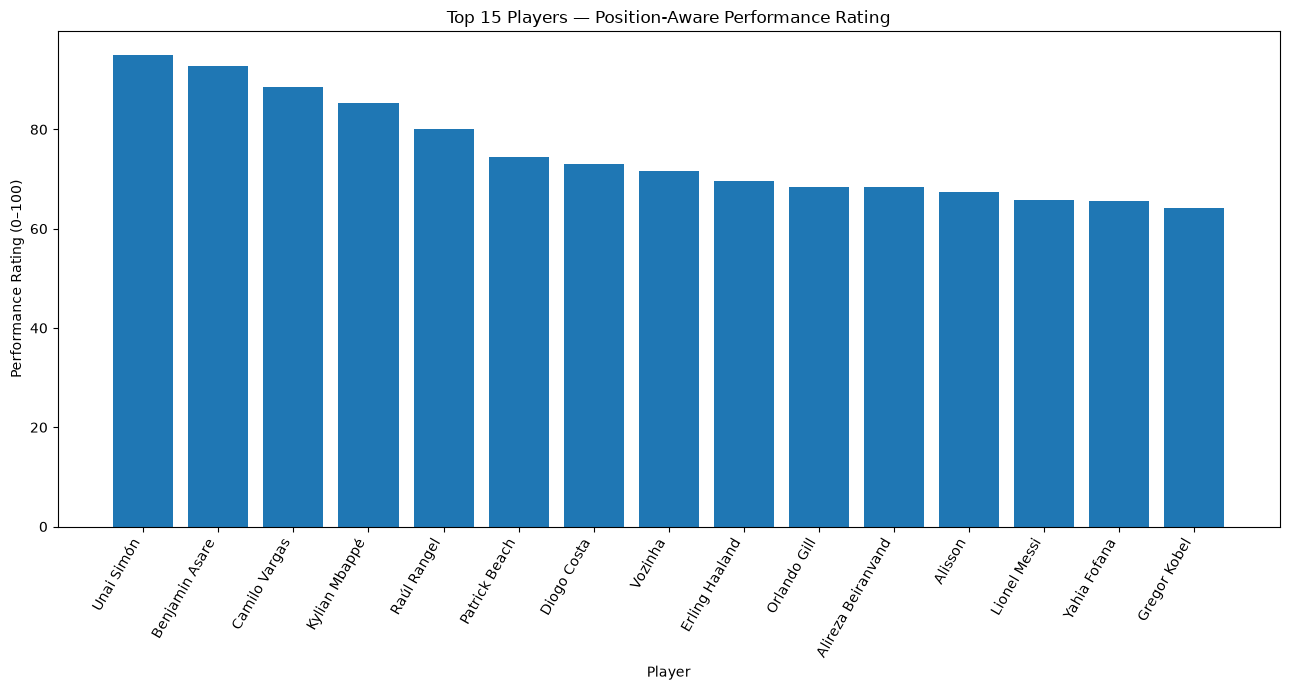

In [89]:
# ==========================================================
# CELL 130 — PLAYER RATING VISUALIZATION
# ==========================================================

top_15_players = player_rating_table.head(15)

plt.figure(figsize=(13, 7))

plt.bar(
    top_15_players["player"],
    top_15_players["player_rating_100"]
)

plt.title(
    "Top 15 Players — Position-Aware Performance Rating"
)

plt.xlabel("Player")
plt.ylabel("Performance Rating (0–100)")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

In [90]:
# ==========================================================
# CELL 131 — TEAM METRIC NORMALIZATION
# ==========================================================

team_strength = teams.copy()


# Attack
team_strength["attack_score"] = normalize_series(
    team_strength["goals"]
)

team_strength["shot_creation_score"] = normalize_series(
    team_strength["shots_on_target"]
)

team_strength["assist_score"] = normalize_series(
    team_strength["assists"]
)


# Defense
team_strength["defense_score"] = (
    1 -
    normalize_series(
        team_strength["goals_against"]
    )
)

team_strength["interception_score"] = normalize_series(
    team_strength["interceptions"]
)

team_strength["tackle_score"] = normalize_series(
    team_strength["tackles_won"]
)


# Goalkeeping
team_strength["save_score"] = normalize_series(
    team_strength["gk_save_pct"]
)

team_strength["clean_sheet_score"] = normalize_series(
    team_strength["gk_clean_sheets"]
)


# Possession
team_strength["possession_score"] = normalize_series(
    team_strength["possession"]
)


display(
    team_strength[
        [
            "team",
            "attack_score",
            "defense_score",
            "possession_score",
            "save_score",
            "clean_sheet_score"
        ]
    ].head(15)
)

,team,attack_score,defense_score,possession_score,save_score,clean_sheet_score
0,Algeria,0.25,0.272727,0.853994,0.239583,0.000000
1,Argentina,0.90,0.363636,0.760331,0.661458,0.285714
2,Australia,0.10,0.909091,0.303030,0.852431,0.285714
3,Austria,0.25,0.272727,0.413223,0.447917,0.000000
4,Belgium,0.65,0.454545,0.584022,0.630208,0.142857
5,Bosnia–Herz,0.20,0.363636,0.440771,0.166667,0.000000
6,Brazil,0.50,0.727273,0.633609,0.772569,0.285714
7,Cabo Verde,0.20,0.727273,0.201102,0.781250,0.285714
8,Canada,0.40,0.545455,0.672176,0.289931,0.285714
9,Colombia,0.25,1.000000,0.765840,0.909722,0.571429


In [91]:
# ==========================================================
# CELL 132 — TEAM ATTACK RATING
# ==========================================================

team_strength["attack_rating"] = (
    team_strength["attack_score"] * 0.50 +
    team_strength["shot_creation_score"] * 0.30 +
    team_strength["assist_score"] * 0.20
)

team_attack_ranking = (
    team_strength[
        [
            "team",
            "goals",
            "assists",
            "shots_on_target",
            "attack_rating"
        ]
    ]
    .sort_values(
        "attack_rating",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    team_attack_ranking.head(15)
)

,team,goals,assists,shots_on_target,attack_rating
0,France,20,18,59,1.000000
1,England,20,14,53,0.923977
2,Argentina,18,12,44,0.804386
3,Spain,13,10,54,0.709795
4,Belgium,13,10,34,0.604532
5,Norway,12,10,29,0.553216
6,Germany,11,10,28,0.522953
7,Brazil,10,8,30,0.486257
8,Morocco,10,9,26,0.476316
9,Netherlands,10,10,22,0.466374


In [92]:
# ==========================================================
# CELL 133 — TEAM DEFENSIVE RATING
# ==========================================================

team_strength["defensive_rating"] = (
    team_strength["defense_score"] * 0.45 +
    team_strength["interception_score"] * 0.20 +
    team_strength["tackle_score"] * 0.20 +
    team_strength["clean_sheet_score"] * 0.15
)

team_defense_ranking = (
    team_strength[
        [
            "team",
            "goals_against",
            "interceptions",
            "tackles_won",
            "gk_clean_sheets",
            "defensive_rating"
        ]
    ]
    .sort_values(
        "defensive_rating",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    team_defense_ranking.head(15)
)

,team,goals_against,interceptions,tackles_won,gk_clean_sheets,defensive_rating
0,Spain,1,64,88,7,0.932755
1,Colombia,1,38,33,4,0.642209
2,Paraguay,5,53,88,2,0.629140
3,Argentina,8,82,93,2,0.606494
4,Mexico,3,36,32,4,0.551718
5,Cabo Verde,4,52,45,2,0.550848
6,Brazil,4,48,46,2,0.541610
7,Australia,2,29,34,2,0.534280
8,Côte d'Ivoire,4,40,48,2,0.523135
9,Morocco,5,40,61,2,0.517361


In [93]:
# ==========================================================
# CELL 134 — OVERALL TEAM STRENGTH
# ==========================================================

team_strength["overall_team_strength"] = (
    team_strength["attack_rating"] * 0.35 +
    team_strength["defensive_rating"] * 0.35 +
    team_strength["possession_score"] * 0.15 +
    team_strength["save_score"] * 0.15
)

team_strength_ranking = (
    team_strength[
        [
            "team",
            "goals",
            "goals_against",
            "possession",
            "attack_rating",
            "defensive_rating",
            "overall_team_strength"
        ]
    ]
    .sort_values(
        "overall_team_strength",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    team_strength_ranking.head(20)
)

,team,goals,goals_against,possession,attack_rating,defensive_rating,overall_team_strength
0,Spain,13,1,64.1,0.709795,0.932755,0.865802
1,Argentina,18,8,57.6,0.804386,0.606494,0.707076
2,France,20,10,55.9,1.000000,0.473543,0.677973
3,England,20,12,54.1,0.923977,0.307077,0.606497
4,Colombia,5,1,57.8,0.327924,0.642209,0.590881
5,Brazil,10,4,53.0,0.486257,0.541610,0.570680
6,Morocco,10,5,59.0,0.476316,0.517361,0.563195
7,Switzerland,10,6,54.0,0.464035,0.487949,0.545910
8,Portugal,7,3,58.4,0.298392,0.509869,0.538528
9,Mexico,10,3,52.2,0.427778,0.551718,0.537163


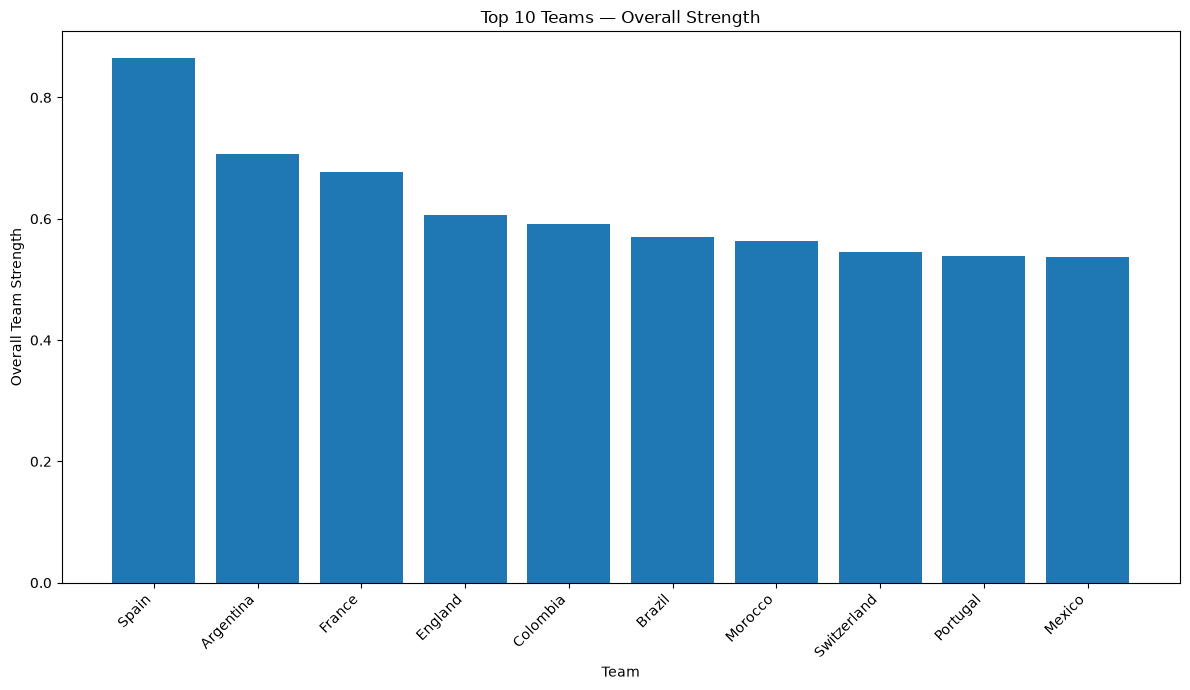

PART 4C COMPLETED

Files saved:
1. player_rating_table.csv
2. top_players_by_position.csv
3. team_attack_ranking.csv
4. team_defense_ranking.csv
5. team_strength_ranking.csv
6. team_strength_full.csv


In [94]:
# ==========================================================
# CELL 135 — TEAM STRENGTH VISUALIZATION & SAVE
# ==========================================================

top_teams = team_strength_ranking.head(10)

plt.figure(figsize=(12, 7))

plt.bar(
    top_teams["team"],
    top_teams["overall_team_strength"]
)

plt.title(
    "Top 10 Teams — Overall Strength"
)

plt.xlabel("Team")
plt.ylabel("Overall Team Strength")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------

advanced_folder = "../data/processed/advanced_analytics"

os.makedirs(
    advanced_folder,
    exist_ok=True
)

player_rating_table.to_csv(
    f"{advanced_folder}/player_rating_table.csv",
    index=False
)

top_players_by_position.to_csv(
    f"{advanced_folder}/top_players_by_position.csv",
    index=False
)

team_attack_ranking.to_csv(
    f"{advanced_folder}/team_attack_ranking.csv",
    index=False
)

team_defense_ranking.to_csv(
    f"{advanced_folder}/team_defense_ranking.csv",
    index=False
)

team_strength_ranking.to_csv(
    f"{advanced_folder}/team_strength_ranking.csv",
    index=False
)

team_strength.to_csv(
    f"{advanced_folder}/team_strength_full.csv",
    index=False
)

print("=" * 60)
print("PART 4C COMPLETED")
print("=" * 60)

print("\nFiles saved:")
print("1. player_rating_table.csv")
print("2. top_players_by_position.csv")
print("3. team_attack_ranking.csv")
print("4. team_defense_ranking.csv")
print("5. team_strength_ranking.csv")
print("6. team_strength_full.csv")

In [95]:
# ==========================================================
# CELL 136 — TEAM PLAYING STYLE DATASET
# ==========================================================

team_style = teams.copy()

print("Team style dataset:", team_style.shape)

display(
    team_style[
        [
            "team",
            "possession",
            "goals",
            "assists",
            "shots",
            "shots_on_target",
            "crosses",
            "interceptions",
            "tackles_won",
            "fouls",
            "offsides"
        ]
    ].head(15)
)

Team style dataset: (48, 133)


,team,possession,goals,assists,shots,shots_on_target,crosses,interceptions,tackles_won,fouls,offsides
0,Algeria,61.0,5,3,44,15,40,30,44,29,4
1,Argentina,57.6,18,12,114,44,104,82,93,113,22
2,Australia,41.0,2,1,42,12,70,29,34,46,1
3,Austria,45.0,5,4,32,8,59,41,29,47,11
4,Belgium,51.2,13,10,112,34,114,50,47,78,8
5,Bosnia–Herz,46.0,4,3,37,14,57,34,37,60,2
6,Brazil,53.0,10,8,74,30,93,48,46,51,11
7,Cabo Verde,37.3,4,2,49,12,50,52,45,27,7
8,Canada,54.4,8,3,80,31,146,36,51,72,7
9,Colombia,57.8,5,5,94,30,70,38,33,70,19


In [96]:
# ==========================================================
# CELL 137 — TEAM STYLE METRICS
# ==========================================================

team_style["shots_per_game"] = (
    team_style["shots"] /
    team_style["games"].replace(0, np.nan)
)

team_style["shots_on_target_per_game"] = (
    team_style["shots_on_target"] /
    team_style["games"].replace(0, np.nan)
)

team_style["goals_per_game"] = (
    team_style["goals"] /
    team_style["games"].replace(0, np.nan)
)

team_style["interceptions_per_game"] = (
    team_style["interceptions"] /
    team_style["games"].replace(0, np.nan)
)

team_style["tackles_per_game"] = (
    team_style["tackles_won"] /
    team_style["games"].replace(0, np.nan)
)

team_style["crosses_per_game"] = (
    team_style["crosses"] /
    team_style["games"].replace(0, np.nan)
)

team_style["fouls_per_game"] = (
    team_style["fouls"] /
    team_style["games"].replace(0, np.nan)
)

team_style["offsides_per_game"] = (
    team_style["offsides"] /
    team_style["games"].replace(0, np.nan)
)

display(
    team_style[
        [
            "team",
            "possession",
            "goals_per_game",
            "shots_per_game",
            "shots_on_target_per_game",
            "interceptions_per_game",
            "tackles_per_game",
            "crosses_per_game"
        ]
    ].head(15)
)

,team,possession,goals_per_game,shots_per_game,shots_on_target_per_game,interceptions_per_game,tackles_per_game,crosses_per_game
0,Algeria,61.0,1.250000,11.000000,3.750000,7.500000,11.000000,10.000000
1,Argentina,57.6,2.250000,14.250000,5.500000,10.250000,11.625000,13.000000
2,Australia,41.0,0.500000,10.500000,3.000000,7.250000,8.500000,17.500000
3,Austria,45.0,1.250000,8.000000,2.000000,10.250000,7.250000,14.750000
4,Belgium,51.2,2.166667,18.666667,5.666667,8.333333,7.833333,19.000000
5,Bosnia–Herz,46.0,1.000000,9.250000,3.500000,8.500000,9.250000,14.250000
6,Brazil,53.0,2.000000,14.800000,6.000000,9.600000,9.200000,18.600000
7,Cabo Verde,37.3,1.000000,12.250000,3.000000,13.000000,11.250000,12.500000
8,Canada,54.4,1.600000,16.000000,6.200000,7.200000,10.200000,29.200000
9,Colombia,57.8,1.000000,18.800000,6.000000,7.600000,6.600000,14.000000


In [97]:
# ==========================================================
# CELL 138 — TEAM PLAYING STYLE CLASSIFICATION
# ==========================================================

def classify_team_style(row):

    possession = row["possession"]
    shots = row["shots_per_game"]
    interceptions = row["interceptions_per_game"]

    if (
        possession >= 55 and
        shots >= team_style["shots_per_game"].median()
    ):
        return "Possession Attacking"

    elif (
        possession < 45 and
        interceptions >= team_style["interceptions_per_game"].median()
    ):
        return "Defensive / Counter"

    elif (
        shots >= team_style["shots_per_game"].median()
        and possession < 50
    ):
        return "Direct Attacking"

    elif (
        possession >= 50
        and interceptions >= team_style["interceptions_per_game"].median()
    ):
        return "Balanced"

    else:
        return "Balanced / Low Intensity"


team_style["playing_style"] = (
    team_style.apply(
        classify_team_style,
        axis=1
    )
)

display(
    team_style[
        [
            "team",
            "possession",
            "shots_per_game",
            "interceptions_per_game",
            "playing_style"
        ]
    ].sort_values(
        "possession",
        ascending=False
    )
)

,team,possession,shots_per_game,interceptions_per_game,playing_style
44,Türkiye,66.3,23.666667,6.000000,Possession Attacking
19,Germany,65.0,18.500000,6.250000,Possession Attacking
40,Spain,64.1,17.500000,8.000000,Possession Attacking
26,Korea Republic,63.0,10.666667,6.666667,Balanced / Low Intensity
0,Algeria,61.0,11.000000,7.500000,Balanced / Low Intensity
28,Morocco,59.0,11.500000,6.666667,Possession Attacking
34,Portugal,58.4,12.400000,6.000000,Possession Attacking
9,Colombia,57.8,18.800000,7.600000,Possession Attacking
1,Argentina,57.6,14.250000,10.250000,Possession Attacking
45,United States,56.8,11.800000,12.000000,Possession Attacking


,playing_style,team_count
0,Balanced / Low Intensity,19
1,Possession Attacking,12
2,Defensive / Counter,10
3,Balanced,5
4,Direct Attacking,2


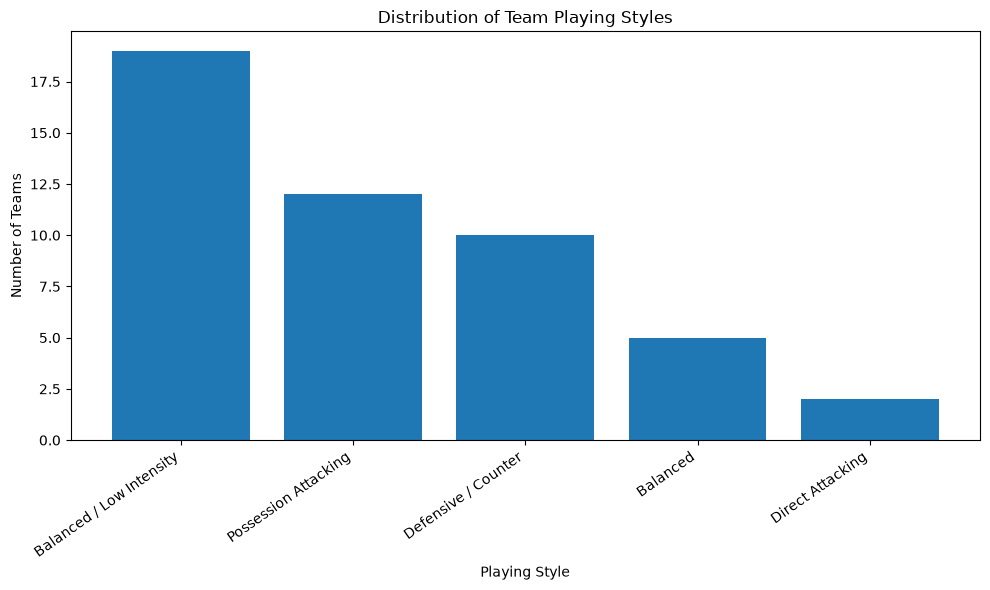

In [98]:
# ==========================================================
# CELL 139 — PLAYING STYLE DISTRIBUTION
# ==========================================================

style_distribution = (
    team_style["playing_style"]
    .value_counts()
    .reset_index()
)

style_distribution.columns = [
    "playing_style",
    "team_count"
]

display(style_distribution)

plt.figure(figsize=(10, 6))

plt.bar(
    style_distribution["playing_style"],
    style_distribution["team_count"]
)

plt.title("Distribution of Team Playing Styles")

plt.xlabel("Playing Style")
plt.ylabel("Number of Teams")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

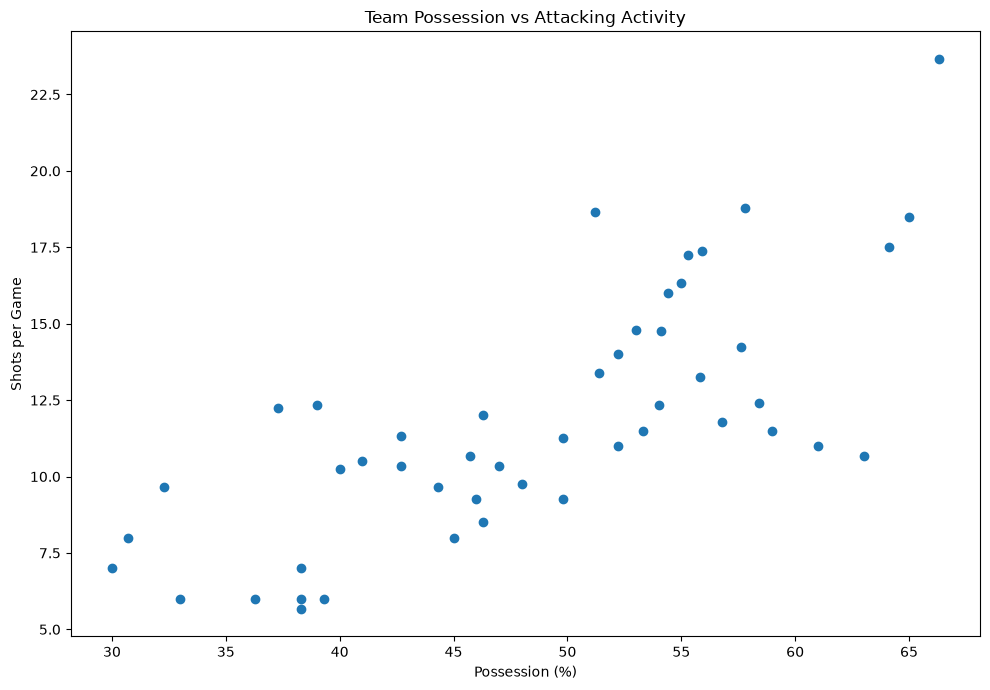

In [99]:
# ==========================================================
# CELL 140 — POSSESSION VS ATTACKING ACTIVITY
# ==========================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    team_style["possession"],
    team_style["shots_per_game"]
)

plt.xlabel("Possession (%)")
plt.ylabel("Shots per Game")

plt.title(
    "Team Possession vs Attacking Activity"
)

plt.tight_layout()
plt.show()

In [100]:
# ==========================================================
# CELL 141 — PLAYER CLUSTERING DATA
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_players = player_analytics[
    (player_analytics["minutes"] >= 180) &
    (player_analytics["primary_position"] != "GK")
].copy()

cluster_features = [
    "goals_per90_calc",
    "assists_per90_calc",
    "shots_per90_calc",
    "shots_on_target_per90_calc",
    "interceptions_per90_calc",
    "tackles_won_per90_calc",
    "crosses_per90_calc"
]

cluster_data = cluster_players[
    cluster_features
].copy()

cluster_data = cluster_data.replace(
    [np.inf, -np.inf],
    np.nan
)

cluster_data = cluster_data.fillna(0)

print("Players for clustering:", len(cluster_players))
print("Features:", cluster_features)

display(cluster_data.head())

Players for clustering: 484
Features: ['goals_per90_calc', 'assists_per90_calc', 'shots_per90_calc', 'shots_on_target_per90_calc', 'interceptions_per90_calc', 'tackles_won_per90_calc', 'crosses_per90_calc']


,goals_per90_calc,assists_per90_calc,shots_per90_calc,shots_on_target_per90_calc,interceptions_per90_calc,tackles_won_per90_calc,crosses_per90_calc
2,0.358566,0.0,1.075697,0.717131,0.000000,0.358566,0.358566
4,0.000000,0.0,0.000000,0.000000,1.000000,0.750000,0.000000
5,0.000000,0.0,2.250000,0.750000,0.750000,1.250000,1.500000
9,0.000000,0.0,2.820513,0.769231,0.000000,0.512821,0.256410
15,0.000000,0.0,0.315789,0.000000,0.947368,1.263158,0.947368


In [101]:
# ==========================================================
# CELL 142 — STANDARDIZE CLUSTERING FEATURES
# ==========================================================

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(
    cluster_data
)

print(
    "Scaled data shape:",
    cluster_scaled.shape
)

Scaled data shape: (484, 7)


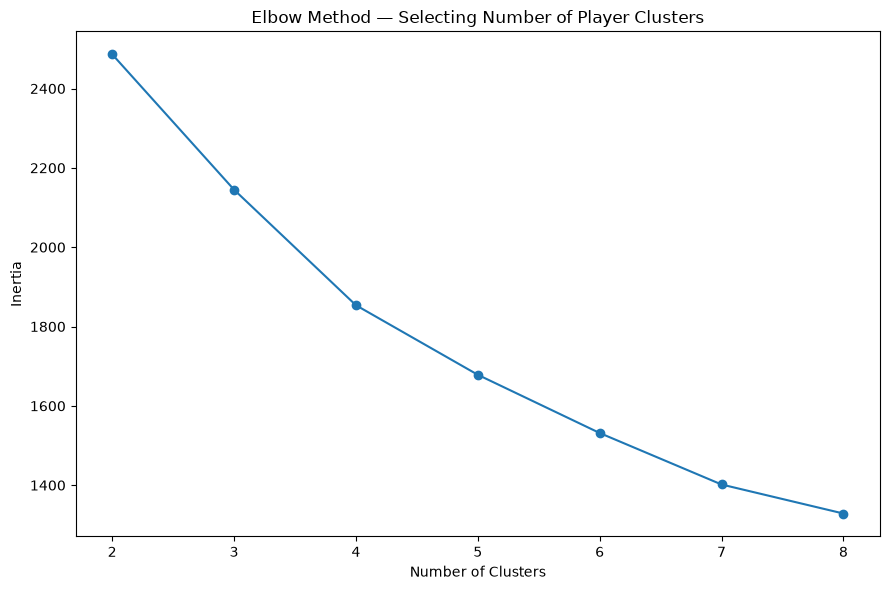

In [102]:
# ==========================================================
# CELL 143 — ELBOW METHOD
# ==========================================================

inertias = []

cluster_range = range(2, 9)

for k in cluster_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    inertias.append(
        kmeans.inertia_
    )


plt.figure(figsize=(9, 6))

plt.plot(
    list(cluster_range),
    inertias,
    marker="o"
)

plt.title(
    "Elbow Method — Selecting Number of Player Clusters"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.xticks(
    list(cluster_range)
)

plt.tight_layout()
plt.show()

In [103]:
# ==========================================================
# CELL 144 — K-MEANS PLAYER CLUSTERING
# ==========================================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(
    cluster_scaled
)

cluster_players["player_cluster"] = (
    cluster_labels
)

print(
    "Clusters created:"
)

print(
    cluster_players[
        "player_cluster"
    ].value_counts()
    .sort_index()
)

display(
    cluster_players[
        [
            "player",
            "team",
            "primary_position",
            "minutes",
            "goals_per90_calc",
            "assists_per90_calc",
            "interceptions_per90_calc",
            "tackles_won_per90_calc",
            "player_cluster"
        ]
    ].head(25)
)

Clusters created:
player_cluster
0    128
1     60
2    214
3     82
Name: count, dtype: int64


,player,team,primary_position,minutes,goals_per90_calc,assists_per90_calc,interceptions_per90_calc,tackles_won_per90_calc,player_cluster
2,Amine Gouiri,Algeria,FW,251.0,0.358566,0.000000,0.000000,0.358566,2
4,Aïssa Mandi,Algeria,DF,360.0,0.000000,0.000000,1.000000,0.750000,2
5,Fares Chaïbi,Algeria,MF,360.0,0.000000,0.000000,0.750000,1.250000,2
9,Ibrahim Maza,Algeria,MF,351.0,0.000000,0.000000,0.000000,0.512821,2
15,Nabil Bentaleb,Algeria,MF,285.0,0.000000,0.000000,0.947368,1.263158,0
18,Rafik Belghali,Algeria,DF,331.0,0.271903,0.000000,0.271903,0.815710,2
20,Ramy Bensebaini,Algeria,DF,360.0,0.000000,0.000000,1.750000,1.500000,0
21,Rayan Aït-Nouri,Algeria,DF,284.0,0.000000,0.000000,1.584507,4.119718,0
22,Riyad Mahrez,Algeria,MF,262.0,0.687023,0.343511,0.343511,0.687023,1
26,Alexis Mac Allister,Argentina,MF,750.0,0.120000,0.120000,1.080000,1.440000,0


In [104]:
# ==========================================================
# CELL 145 — CLUSTER ANALYSIS & SAVE
# ==========================================================

cluster_summary = (
    cluster_players
    .groupby("player_cluster")
    .agg(
        players=("player", "count"),
        avg_minutes=("minutes", "mean"),
        avg_goals_per90=("goals_per90_calc", "mean"),
        avg_assists_per90=("assists_per90_calc", "mean"),
        avg_shots_per90=("shots_per90_calc", "mean"),
        avg_interceptions_per90=(
            "interceptions_per90_calc",
            "mean"
        ),
        avg_tackles_per90=(
            "tackles_won_per90_calc",
            "mean"
        ),
        avg_crosses_per90=(
            "crosses_per90_calc",
            "mean"
        )
    )
    .reset_index()
)

display(cluster_summary)


# ----------------------------------------------------------
# SAVE RESULTS
# ----------------------------------------------------------

advanced_folder = "../data/processed/advanced_analytics"

os.makedirs(
    advanced_folder,
    exist_ok=True
)

team_style.to_csv(
    f"{advanced_folder}/team_playing_styles.csv",
    index=False
)

style_distribution.to_csv(
    f"{advanced_folder}/playing_style_distribution.csv",
    index=False
)

cluster_players.to_csv(
    f"{advanced_folder}/player_clusters.csv",
    index=False
)

cluster_summary.to_csv(
    f"{advanced_folder}/player_cluster_summary.csv",
    index=False
)

print("=" * 60)
print("PART 4D COMPLETED")
print("=" * 60)

print("\nFiles saved:")
print("1. team_playing_styles.csv")
print("2. playing_style_distribution.csv")
print("3. player_clusters.csv")
print("4. player_cluster_summary.csv")

,player_cluster,players,avg_minutes,avg_goals_per90,avg_assists_per90,avg_shots_per90,avg_interceptions_per90,avg_tackles_per90,avg_crosses_per90
0,0,128,327.632812,0.037003,0.037554,0.645480,1.522694,1.587386,0.908272
1,1,60,351.266667,0.624061,0.183764,3.170103,0.374597,0.567502,1.638430
2,2,214,314.532710,0.054157,0.030809,0.818641,0.596517,0.625625,0.912284
3,3,82,314.987805,0.138623,0.323107,1.267009,0.635974,1.013669,3.904679


PART 4D COMPLETED

Files saved:
1. team_playing_styles.csv
2. playing_style_distribution.csv
3. player_clusters.csv
4. player_cluster_summary.csv


In [106]:
# ==========================================================
# CELL 146 — ADVANCED PLAYER INSIGHTS
# ==========================================================

print("=" * 70)
print("ADVANCED PLAYER INSIGHTS")
print("=" * 70)


# ==========================================================
# 1. TOP ATTACKING PLAYERS
# ==========================================================

top_attackers = (
    rating_players[
        rating_players["primary_position"].isin(["FW", "MF"])
    ]
    .sort_values(
        "goal_contribution_per90",
        ascending=False
    )
    [
        [
            "player",
            "team",
            "primary_position",
            "minutes",
            "goals",
            "assists",
            "goal_contribution_per90"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

print("\nTOP ATTACKING PLAYERS")

display(top_attackers)


# ==========================================================
# 2. CREATE DEFENSIVE OUTPUT
# ==========================================================

rating_players["defensive_output"] = (
    rating_players["interception_score"] * 0.35 +
    rating_players["tackle_score"] * 0.35 +
    rating_players["goal_score"] * 0.10 +
    rating_players["assist_score"] * 0.10 +
    rating_players["shot_score"] * 0.10
)


# ==========================================================
# 3. TOP DEFENSIVE PLAYERS
# ==========================================================

top_defenders = (
    rating_players[
        rating_players["primary_position"] == "DF"
    ]
    .sort_values(
        "defensive_output",
        ascending=False
    )
    [
        [
            "player",
            "team",
            "primary_position",
            "minutes",
            "interceptions",
            "tackles_won",
            "defensive_output"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

print("\nTOP DEFENSIVE PLAYERS")

display(top_defenders)


# ==========================================================
# 4. TOP GOALKEEPERS
# ==========================================================

top_goalkeepers = (
    rating_players[
        rating_players["primary_position"] == "GK"
    ]
    .sort_values(
        "player_rating_100",
        ascending=False
    )
    [
        [
            "player",
            "team",
            "minutes",
            "gk_save_pct",
            "gk_clean_sheets",
            "player_rating_100"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)

print("\nTOP GOALKEEPERS")

display(top_goalkeepers)

ADVANCED PLAYER INSIGHTS

TOP ATTACKING PLAYERS


,player,team,primary_position,minutes,goals,assists,goal_contribution_per90
0,Johan Manzambi,Switzerland,MF,199.0,3.0,2.0,2.261307
1,Kylian Mbappé,France,FW,695.0,10.0,4.0,1.812950
2,Romelu Lukaku,Belgium,FW,233.0,3.0,1.0,1.545064
3,Bukayo Saka,England,MF,358.0,3.0,3.0,1.508380
4,Nathan Saliba,Canada,MF,182.0,1.0,2.0,1.483516
5,Lionel Messi,Argentina,FW,740.0,8.0,4.0,1.459459
6,Andreas Schjelderup,Norway,FW,252.0,1.0,3.0,1.428571
7,Crysencio Summerville,Netherlands,FW,253.0,2.0,2.0,1.422925
8,Erling Haaland,Norway,FW,465.0,7.0,0.0,1.354839
9,Ismaila Sarr,Senegal,MF,364.0,4.0,1.0,1.236264



TOP DEFENSIVE PLAYERS


,player,team,primary_position,minutes,interceptions,tackles_won,defensive_output
0,Marvin Senaya,Ghana,DF,278.0,6.0,12.0,0.490056
1,Rayan Aït-Nouri,Algeria,DF,284.0,5.0,13.0,0.480522
2,Merchas Doski,Iraq,DF,270.0,6.0,9.0,0.419619
3,Khuliso Mudau,South Africa,DF,360.0,11.0,8.0,0.396442
4,Mohamed Amine Ben Hamida,Tunisia,DF,202.0,1.0,9.0,0.377371
5,Ali Abdi,Tunisia,DF,269.0,4.0,8.0,0.337635
6,Yazan Al-Arab,Jordan,DF,270.0,11.0,1.0,0.330356
7,Marcos Llorente,Spain,DF,187.0,1.0,6.0,0.329896
8,Dayot Upamecano,France,DF,660.0,15.0,12.0,0.329397
9,Stefan Posch,Austria,DF,331.0,10.0,4.0,0.316378



TOP GOALKEEPERS


,player,team,minutes,gk_save_pct,gk_clean_sheets,player_rating_100
0,Unai Simón,Spain,750.0,90.9,7.0,95.000000
1,Benjamin Asare,Ghana,225.0,80.0,2.0,92.805281
2,Camilo Vargas,Colombia,480.0,85.7,4.0,88.567657
3,Raúl Rangel,Mexico,437.0,72.7,4.0,79.986799
4,Patrick Beach,Australia,388.0,82.4,2.0,74.389439
5,Diogo Costa,Portugal,450.0,86.4,2.0,73.029703
6,Vozinha,Cabo Verde,390.0,78.3,2.0,71.683168
7,Orlando Gill,Paraguay,480.0,79.3,2.0,68.343234
8,Alireza Beiranvand,IR Iran,270.0,83.3,1.0,68.303498
9,Alisson,Brazil,450.0,77.8,2.0,67.353135


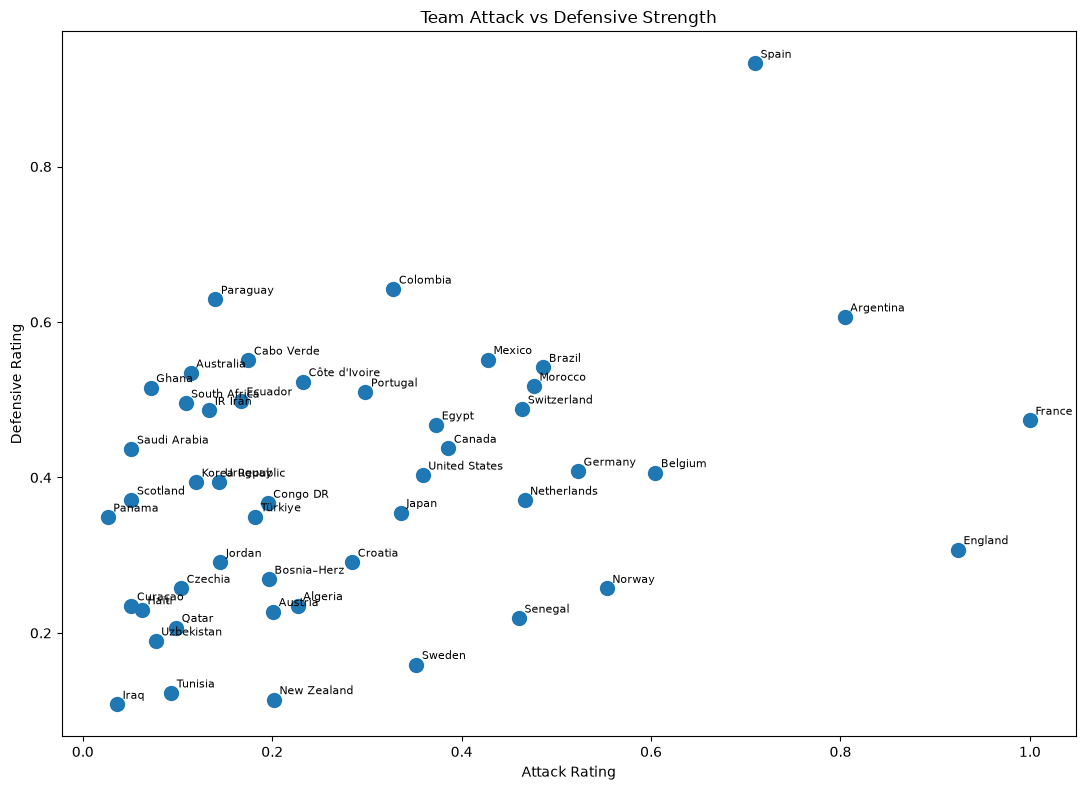

In [107]:
# ==========================================================
# CELL 147 — TEAM ATTACK VS DEFENSE
# ==========================================================

team_comparison = team_strength_ranking.copy()

plt.figure(figsize=(11, 8))

plt.scatter(
    team_comparison["attack_rating"],
    team_comparison["defensive_rating"],
    s=100
)

for _, row in team_comparison.iterrows():

    plt.annotate(
        row["team"],
        (
            row["attack_rating"],
            row["defensive_rating"]
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.xlabel("Attack Rating")
plt.ylabel("Defensive Rating")

plt.title(
    "Team Attack vs Defensive Strength"
)

plt.tight_layout()
plt.show()

In [108]:
# ==========================================================
# CELL 148 — FINAL PLAYER ANALYTICS DATASET
# ==========================================================

final_player_analytics = rating_players[
    [
        "player",
        "team",
        "team_country",
        "position",
        "primary_position",
        "age",
        "club",
        "games",
        "games_starts",
        "minutes",
        "goals",
        "assists",
        "shots",
        "shots_on_target",
        "interceptions",
        "tackles_won",
        "goals_per90_calc",
        "assists_per90_calc",
        "shots_per90_calc",
        "shots_on_target_per90_calc",
        "interceptions_per90_calc",
        "tackles_won_per90_calc",
        "goal_contribution_per90",
        "player_rating_100"
    ]
].copy()

# Add cluster information where available
cluster_information = cluster_players[
    [
        "player",
        "player_cluster"
    ]
].drop_duplicates(
    subset=["player"]
)

final_player_analytics = final_player_analytics.merge(
    cluster_information,
    on="player",
    how="left"
)

final_player_analytics = (
    final_player_analytics
    .sort_values(
        "player_rating_100",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Final player analytics shape:",
    final_player_analytics.shape
)

display(
    final_player_analytics.head(20)
)

Final player analytics shape: (532, 25)


,player,team,team_country,position,primary_position,age,club,games,games_starts,minutes,goals,assists,shots,shots_on_target,interceptions,tackles_won,goals_per90_calc,assists_per90_calc,shots_per90_calc,shots_on_target_per90_calc,interceptions_per90_calc,tackles_won_per90_calc,goal_contribution_per90,player_rating_100,player_cluster
0,Unai Simón,Spain,Spain,GK,GK,29,Athletic Club,8,8,750.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,NaN
1,Benjamin Asare,Ghana,Ghana,GK,GK,33,Unknown Club,3,2,225.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,92.805281,NaN
2,Camilo Vargas,Colombia,Colombia,GK,GK,37,Atlas,5,5,480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,88.567657,NaN
3,Kylian Mbappé,France,France,FW,FW,27,Real Madrid,8,8,695.0,10.0,4.0,41.0,23.0,0.0,1.0,1.294964,0.517986,5.309353,2.978417,0.000000,0.129496,1.812950,85.263789,1.0
4,Raúl Rangel,Mexico,Mexico,GK,GK,26,Guadalajara,5,5,437.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,79.986799,NaN
5,Patrick Beach,Australia,Australia,GK,GK,22,Melb City,4,4,388.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,74.389439,NaN
6,Diogo Costa,Portugal,Portugal,GK,GK,26,Porto,5,5,450.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,73.029703,NaN
7,Vozinha,Cabo Verde,Cape Verde,GK,GK,40,Unknown Club,4,4,390.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,71.683168,NaN
8,Erling Haaland,Norway,Norway,FW,FW,25,Manchester City,5,5,465.0,7.0,0.0,20.0,13.0,1.0,0.0,1.354839,0.000000,3.870968,2.516129,0.193548,0.000000,1.354839,69.510207,1.0
9,Orlando Gill,Paraguay,Paraguay,GK,GK,26,San Lorenzo,5,5,480.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.343234,NaN


In [109]:
# ==========================================================
# CELL 149 — FINAL TEAM ANALYTICS DATASET
# ==========================================================

final_team_analytics = team_strength.merge(
    team_style[
        [
            "team",
            "playing_style",
            "shots_per_game",
            "shots_on_target_per_game",
            "goals_per_game",
            "interceptions_per_game",
            "tackles_per_game",
            "crosses_per_game",
            "fouls_per_game",
            "offsides_per_game"
        ]
    ],
    on="team",
    how="left",
    suffixes=("", "_style")
)

final_team_analytics = final_team_analytics[
    [
        "team",
        "team_country",
        "games",
        "goals",
        "assists",
        "goals_against",
        "possession",
        "shots",
        "shots_on_target",
        "interceptions",
        "tackles_won",
        "gk_saves",
        "gk_save_pct",
        "gk_clean_sheets",
        "attack_rating",
        "defensive_rating",
        "overall_team_strength",
        "playing_style",
        "shots_per_game",
        "shots_on_target_per_game",
        "goals_per_game",
        "interceptions_per_game",
        "tackles_per_game",
        "crosses_per_game",
        "fouls_per_game",
        "offsides_per_game"
    ]
].sort_values(
    "overall_team_strength",
    ascending=False
).reset_index(drop=True)

print(
    "Final team analytics shape:",
    final_team_analytics.shape
)

display(
    final_team_analytics.head(20)
)

Final team analytics shape: (48, 26)


,team,team_country,games,goals,assists,goals_against,possession,shots,shots_on_target,interceptions,tackles_won,gk_saves,gk_save_pct,gk_clean_sheets,attack_rating,defensive_rating,overall_team_strength,playing_style,shots_per_game,shots_on_target_per_game,goals_per_game,interceptions_per_game,tackles_per_game,crosses_per_game,fouls_per_game,offsides_per_game
0,Spain,Spain,8,13,10,1,64.1,140,54,64,88,9,90.9,7,0.709795,0.932755,0.865802,Possession Attacking,17.500000,6.750000,1.625000,8.000000,11.000000,20.625000,12.625000,2.625000
1,Argentina,Argentina,8,18,12,8,57.6,114,44,82,93,20,71.4,2,0.804386,0.606494,0.707076,Possession Attacking,14.250000,5.500000,2.250000,10.250000,11.625000,13.000000,14.125000,2.750000
2,France,France,8,20,18,10,55.9,139,59,65,77,12,54.5,4,1.000000,0.473543,0.677973,Possession Attacking,17.375000,7.375000,2.500000,8.125000,9.625000,13.625000,10.500000,1.750000
3,England,England,8,20,14,12,54.1,118,53,51,77,20,62.5,2,0.923977,0.307077,0.606497,Balanced / Low Intensity,14.750000,6.625000,2.500000,6.375000,9.625000,20.375000,10.125000,1.875000
4,Colombia,Colombia,5,5,5,1,57.8,94,30,38,33,6,85.7,4,0.327924,0.642209,0.590881,Possession Attacking,18.800000,6.000000,1.000000,7.600000,6.600000,14.000000,14.000000,3.800000
5,Brazil,Brazil,5,10,8,4,53.0,74,30,48,46,14,77.8,2,0.486257,0.541610,0.570680,Balanced,14.800000,6.000000,2.000000,9.600000,9.200000,18.600000,10.200000,2.200000
6,Morocco,Morocco,6,10,9,5,59.0,69,26,40,61,14,70.0,2,0.476316,0.517361,0.563195,Possession Attacking,11.500000,4.333333,1.666667,6.666667,10.166667,13.833333,12.333333,1.500000
7,Switzerland,Switzerland,6,10,6,6,54.0,74,30,52,52,20,76.9,2,0.464035,0.487949,0.545910,Balanced,12.333333,5.000000,1.666667,8.666667,8.666667,18.500000,14.500000,2.166667
8,Portugal,Portugal,5,7,4,3,58.4,62,17,30,39,19,86.4,2,0.298392,0.509869,0.538528,Possession Attacking,12.400000,3.400000,1.400000,6.000000,7.800000,18.400000,8.800000,2.000000
9,Mexico,Mexico,5,10,7,3,52.2,70,21,36,32,8,72.7,4,0.427778,0.551718,0.537163,Balanced / Low Intensity,14.000000,4.200000,2.000000,7.200000,6.400000,17.200000,11.600000,1.000000


In [110]:
# ==========================================================
# CELL 150 — FINAL PART 4 EXPORT
# ==========================================================

advanced_folder = "../data/processed/advanced_analytics"

os.makedirs(
    advanced_folder,
    exist_ok=True
)

# ----------------------------------------------------------
# PLAYER OUTPUTS
# ----------------------------------------------------------

final_player_analytics.to_csv(
    f"{advanced_folder}/final_player_analytics.csv",
    index=False
)

top_attackers.to_csv(
    f"{advanced_folder}/top_attackers.csv",
    index=False
)

top_defenders.to_csv(
    f"{advanced_folder}/top_defenders.csv",
    index=False
)

top_goalkeepers.to_csv(
    f"{advanced_folder}/top_goalkeepers.csv",
    index=False
)


# ----------------------------------------------------------
# TEAM OUTPUTS
# ----------------------------------------------------------

final_team_analytics.to_csv(
    f"{advanced_folder}/final_team_analytics.csv",
    index=False
)

team_comparison.to_csv(
    f"{advanced_folder}/team_attack_defense_comparison.csv",
    index=False
)


# ----------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------

print("=" * 70)
print("PART 4 — ADVANCED FOOTBALL ANALYTICS COMPLETED")
print("=" * 70)

print("\nFinal datasets created:")

print("\nPLAYER DATA")
print("✓ final_player_analytics.csv")
print("✓ top_attackers.csv")
print("✓ top_defenders.csv")
print("✓ top_goalkeepers.csv")

print("\nTEAM DATA")
print("✓ final_team_analytics.csv")
print("✓ team_attack_defense_comparison.csv")

print("\nOutput folder:")
print(advanced_folder)

print("\nPlayer dataset shape:")
print(final_player_analytics.shape)

print("\nTeam dataset shape:")
print(final_team_analytics.shape)

print("\nPART 4 COMPLETE ✅")

PART 4 — ADVANCED FOOTBALL ANALYTICS COMPLETED

Final datasets created:

PLAYER DATA
✓ final_player_analytics.csv
✓ top_attackers.csv
✓ top_defenders.csv
✓ top_goalkeepers.csv

TEAM DATA
✓ final_team_analytics.csv
✓ team_attack_defense_comparison.csv

Output folder:
../data/processed/advanced_analytics

Player dataset shape:
(532, 25)

Team dataset shape:
(48, 26)

PART 4 COMPLETE ✅
